# DDN Test-Phase Evaluation Workflow

This notebook benchmarks neural models against semi-analytic COS outputs and runs diagnostics. This one evaluates MLP Greeks too!

## Phases (run top-to-bottom)
1. Environment, data, and neural inference (build model output DataFrames).
2. Semi-analytic COS evaluation (optional, builds df_COS).
3. Runtime benchmark across batch sizes (optional COS rows).
4. Accuracy metrics + master tables (fair vs max-coverage).
5. Residual diagnostics + surface visualizations.
6. Greek evaluation suite (directional accuracy, higher-order autograd checks, visual validation vs COS/COS-IV, and empirical Lipschitz diagnostics).
7. Arbitrage diagnostics (dataset checks + dense-grid robustness).
8. Metrics diagnostics tables (MAPE/MSE/MAE with optional heatmaps).

Most toggles are in the first line of each phase. If COS or LetsBeRational is missing, those sections degrade gracefully.

## 1) Environment, Data, and Neural Model Inference
Set up paths, load pretrained models, and prepare normalized inputs for inference.
This phase produces the core model output DataFrames used in later metrics and diagnostics.

In [2]:
# ==============================
# 1) Environment setup + imports
# ==============================

import sys
import os
from pathlib import Path
# Project root (relative to current working directory)
project_root = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
# This root anchors all relative data/model paths in the notebook.
print(f"Project root: {project_root}")

# Add project root to sys.path so local package imports work
if project_root not in sys.path:
    sys.path.append(project_root)
    print(f"Added '{project_root}' to sys.path")

from typing import Tuple
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
import time
import random
import importlib
import matplotlib.pyplot as plt
import warnings
from tqdm import tqdm
from sklearn.metrics import mean_squared_error, mean_absolute_error
import scipy.stats as stats
from scipy.stats import norm
import seaborn as sns
from matplotlib.colors import LogNorm
# Model import path (relative package path)
from src.heston_project.models.DDN import DDN
from src.heston_project.models.MLP import Heston_MLP

# Global reproducibility controls used across notebook sampling/evaluation.
GLOBAL_SEED = 42
random.seed(GLOBAL_SEED)
np.random.seed(GLOBAL_SEED)
torch.manual_seed(GLOBAL_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(GLOBAL_SEED)
    torch.cuda.manual_seed_all(GLOBAL_SEED)

# Prefer deterministic kernels when available (can be slower).
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
try:
    torch.use_deterministic_algorithms(True, warn_only=True)
except TypeError:
    try:
        torch.use_deterministic_algorithms(True)
    except Exception:
        pass
except Exception:
    pass

print(f"Global reproducibility seed set: {GLOBAL_SEED}")

# Device selection for PyTorch
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# ==============================
# 2) Load models and set to eval mode
# ==============================

# Pretrained weight files (frozen for evaluation).
saved_model_path_IV = os.path.join(project_root, "src", "heston_project", "models", "saved", "DDN_IV_removed_10p.pth")
saved_model_path_P = os.path.join(project_root, "src", "heston_project", "models", "saved", "DDN_P_new_weight_p1.pth")
saved_model_path_PdivK = os.path.join(project_root, "src", "heston_project", "models", "saved", "DDN_PdivK_final.pth")
saved_model_path_MLP = os.path.join(project_root, "src", "heston_project", "models", "saved", "MLP_P_final.pth")

model_IV = DDN(input_dim=8, hidden_layers=7, neurons=250).to(device)
model_IV.load_state_dict(torch.load(saved_model_path_IV, map_location='cpu'))
model_IV.eval()

model_P = DDN(input_dim=8, hidden_layers=7, neurons=250).to(device)
model_P.load_state_dict(torch.load(saved_model_path_P, map_location='cpu'))
model_P.eval()

model_PdivK = DDN(input_dim=8, hidden_layers=7, neurons=250).to(device)
model_PdivK.load_state_dict(torch.load(saved_model_path_PdivK, map_location='cpu'))
model_PdivK.eval()

model_MLP = Heston_MLP(input_dim=8, hidden_layers=7, neurons=250).to(device)
model_MLP.load_state_dict(torch.load(saved_model_path_MLP, map_location='cpu'))
model_MLP.eval()

print("Models loaded successfully!")

# ==============================
# 3) Number formatting (consistent with training/eval reporting)
# ==============================

# Display helpers used in printed tables throughout the notebook.
def fmt_sig4(x):
    """4 significant digits with scientific notation for very small values."""
    if x is None:
        return "NaN"

    try:
        x = float(x)
    except (TypeError, ValueError):
        return str(x)

    if not np.isfinite(x):
        return str(x)

    ax = abs(x)
    if ax == 0.0:
        return "0"

    # Small decimals like 0.01242115 -> 1.242e-02
    if ax < 1e-1:
        return f"{x:.3e}"

    # Large values use scientific notation to avoid overflow in internal rounding.
    if ax >= 1e4:
        return f"{x:.3e}"

    # Mid-range values in compact 4-significant format
    return f"{x:.4g}"


def fmt_pct4(x):
    """Percentage formatting with 4 significant digits (e.g., for error rates)"""
    return f"{fmt_sig4(x)}%"


# Apply globally so DataFrame displays follow the same format.
pd.options.display.float_format = fmt_sig4
np.set_printoptions(formatter={"float_kind": lambda v: fmt_sig4(float(v))})

print("Numeric display format set: 4 significant digits.")

Project root: /Users/manswestman/Kandidatarbete
Added '/Users/manswestman/Kandidatarbete' to sys.path
Global reproducibility seed set: 42
Using device: cpu
Models loaded successfully!
Numeric display format set: 4 significant digits.


In [3]:
# ==============================
# 1b) Dependency version guard (requirements.txt sync)
# ==============================

from importlib.metadata import PackageNotFoundError, version
import subprocess
try:
    from packaging.requirements import Requirement
    from packaging.version import Version, InvalidVersion
except Exception:
    Requirement = None
    Version = None
    InvalidVersion = Exception

# Set True only when you explicitly want to install/update from requirements.txt.
AUTO_SYNC_REQUIREMENTS = False

req_path = Path(project_root) / "requirements.txt"
if not req_path.exists():
    print(f"requirements.txt not found at: {req_path}")
else:
    if Requirement is None:
        print("Missing 'packaging' module. Install it with: pip install packaging")
    else:
        raw_lines = req_path.read_text(encoding="utf-8").splitlines()
        requirement_lines = []
        for line in raw_lines:
            stripped = line.strip()
            if not stripped or stripped.startswith("#"):
                continue
            requirement_lines.append(stripped)

        parsed_requirements = []
        parse_errors = []
        for line in requirement_lines:
            try:
                parsed_requirements.append(Requirement(line))
            except Exception as e:
                parse_errors.append((line, str(e)))

        if parse_errors:
            print("Could not parse some requirement lines:")
            for bad_line, err in parse_errors:
                print(f"  - {bad_line} ({err})")

        results = []
        mismatches = []
        missing = []

        for req in parsed_requirements:
            pkg = req.name
            spec = str(req.specifier) if str(req.specifier) else "(any)"

            try:
                installed = version(pkg)
            except PackageNotFoundError:
                status = "missing"
                installed = None
                missing.append(pkg)
            except Exception as e:
                status = f"error: {e}"
                installed = None
            else:
                if not req.specifier:
                    status = "ok"
                else:
                    try:
                        status = "ok" if req.specifier.contains(Version(installed), prereleases=True) else "mismatch"
                    except InvalidVersion:
                        status = "mismatch"

                if status == "mismatch":
                    mismatches.append((pkg, installed, spec))

            results.append(
                {
                    "package": pkg,
                    "required": spec,
                    "installed": installed if installed is not None else "-",
                    "status": status,
                }
            )

        dep_check_df = pd.DataFrame(results).sort_values(["status", "package"]).reset_index(drop=True)
        display(dep_check_df)

        n_ok = int((dep_check_df["status"] == "ok").sum()) if not dep_check_df.empty else 0
        n_mismatch = int((dep_check_df["status"] == "mismatch").sum()) if not dep_check_df.empty else 0
        n_missing = int((dep_check_df["status"] == "missing").sum()) if not dep_check_df.empty else 0

        print()
        print(f"Dependency check summary -> ok: {n_ok}, mismatch: {n_mismatch}, missing: {n_missing}")

        if n_mismatch > 0 or n_missing > 0:
            print("To sync this kernel environment with requirements.txt, run:")
            print(f"  {sys.executable} -m pip install -r {req_path}")

            if AUTO_SYNC_REQUIREMENTS:
                print("AUTO_SYNC_REQUIREMENTS=True -> installing now...")
                subprocess.check_call([sys.executable, "-m", "pip", "install", "-r", str(req_path)])
                print("Install finished. Restart the notebook kernel before rerunning evaluation cells.")
        else:
            print("All relevant requirements are already satisfied in the active kernel environment.")

,package,required,installed,status
0,ipykernel,(any),7.2.0,ok
1,jupyterlab,(any),4.5.4,ok
2,matplotlib,>=3.10.8,3.10.8,ok
3,numpy,>=2.4.2,2.4.2,ok
4,pandas,>=3.0.0,3.0.1,ok
5,scikit-learn,>=1.8.0,1.8.0,ok
6,scipy,>=1.17.0,1.17.1,ok
7,torch,>=2.10.0,2.10.0,ok



Dependency check summary -> ok: 8, mismatch: 0, missing: 0
All relevant requirements are already satisfied in the active kernel environment.


In [4]:
# ==============================
# 4) Data loading and preprocessing
# ==============================

# Construct the absolute path to the CSV file 
csv_path = Path(project_root) / "data" / "bilokon" / "full_bilokon_dataset_5K_nofeller.csv"

# Load the CSV file
df = pd.read_csv(csv_path)

# Shuffle with a fixed random state for reproducibility
df = df.sample(frac=1, random_state=int(GLOBAL_SEED)).reset_index(drop=True)

# Copy for scaling
df_scaler = df.copy()

# Match training preprocessing: sqrt on theta/v0.
df_scaler[['theta', 'v0']] = np.sqrt(df_scaler[['theta', 'v0']])
sqrt_copy = df_scaler[['theta', 'v0']].copy()

# Create input DataFrames for each model (same features, different order for MLP)
input_raw_DDN_P = df_scaler[['kappa', 'theta', 'v0', 'rho', 'sigma', 'r', 'lm', 'T']]
input_raw_MLP_P = df_scaler[['kappa', 'v0', 'theta', 'rho', 'sigma', 'r', 'lm', 'T']] 
input_raw_DDN_PdivK = df_scaler[['kappa', 'theta', 'v0', 'rho', 'sigma', 'r', 'lm', 'T']]
input_raw_DDN_IV = df_scaler[['kappa', 'theta', 'v0', 'rho', 'sigma', 'r', 'lm', 'T']]

# Parameter bounds used for min-max scaling (mirrors training).
param_bounds = {
    "kappa": [0.05, 5.0],
    "theta": [0.0, 1.0],
    "sigma": [0.1, 1.5],
    "rho":   [-0.95, 0.0],
    "v0":    [0.0, 1.0],
    "T":     [1/52, 3.0],
     "r":     [-0.01, 0.10],
    "lm":    [-1.5, 1.5],
   }


# Min-max scaling formula
def min_max_scale(x, xmin, xmax, zero_centered):
    # Scales to [-1,1]
    if zero_centered:
        return 2 * (x - xmin) / (xmax - xmin) - 1
    # Scales to [0,1]
    else: 
        return (x - xmin) / (xmax - xmin)
    
# Min-max scaling for inputs 
def scale_inputs(data, zero_centered):

    data_c = data.copy()

    for k, (kmin, kmax) in param_bounds.items():
        
        data_c[k] = min_max_scale(data_c[k], kmin, kmax, zero_centered)
    
    return data_c

# Transform input data using the same scaling as during training (min-max scaling based on parameter bounds)
input_df_DDN_P = scale_inputs(input_raw_DDN_P, zero_centered=True)
input_df_MLP_P = scale_inputs(input_raw_MLP_P, zero_centered=True)
input_df_DDN_PdivK = scale_inputs(input_raw_DDN_PdivK, zero_centered=True)
input_df_DDN_IV = scale_inputs(input_raw_DDN_IV, zero_centered=True)

# Convert to PyTorch tensors; requires_grad=True enables autograd Greeks.
input_DDN_P = torch.tensor(input_df_DDN_P.values, dtype=torch.float32, requires_grad=True)
input_MLP_P = torch.tensor(input_df_MLP_P.values, dtype=torch.float32, requires_grad=True)
input_DDN_PdivK = torch.tensor(input_df_DDN_PdivK.values, dtype=torch.float32, requires_grad=True)
input_DDN_IV = torch.tensor(input_df_DDN_IV.values, dtype=torch.float32, requires_grad=True)

In [5]:
#===============================
# 5) Load training dataset for min-max of price
#===============================

csv_price = Path(project_root) / "data" / "full_dataset_training_200000(2).csv"

# Load the CSV file
df_minmax = pd.read_csv(csv_price)

# Identify pmin and pmax from the training dataset (used for unscale)
pmin = df_minmax['price'].min()
pmax = df_minmax['price'].max()

# MLP_P training constants (ymin, ymax from its specific train split)


df_mlp = df_minmax.sample(frac=1, random_state=42).reset_index(drop=True)     
_, _, y_train_mlp, _ = train_test_split(df_mlp['price'], df_mlp['price'],     
                                          test_size=0.1, random_state=42)       
ymin_MLP = y_train_mlp.min()                                                  
ymax_MLP = y_train_mlp.max()  

# df_mlp = df_minmax.copy()
# _, _, y_train_mlp, _ = train_test_split(df_mlp['price'], df_mlp['price'], test_size=0.1, random_state=int(GLOBAL_SEED))
# ymin_MLP = y_train_mlp.min()
# ymax_MLP = y_train_mlp.max()

#===============================
# 6) Define relevant greeks and function to do forward pass + get gradients
#===============================

relevant_greeks_DDN_P = ['theta', 'sigma', 'rho', 'kappa', 'v0']
relevant_greeks_DDN_PdivK = ['theta', 'sigma', 'rho', 'kappa', 'v0']
relevant_greeks_DDN_IV = ['kappa', 'theta', 'sigma', 'rho', 'v0']
relevant_greeks_COS = ['theta', 'v0', 'sigma', 'rho', 'kappa']
relevant_greeks_MLP_P = ['theta', 'sigma', 'rho', 'kappa', 'v0']

def get_grads(model, x):
    """Forward pass + autograd greeks."""
    pred = model(x)
    grads = torch.autograd.grad(pred, x, torch.ones_like(pred), create_graph=False, retain_graph=False)[0]
    return pred.detach().cpu().numpy().flatten(), grads.detach().cpu().numpy()

In [6]:
#===============================
# 7) Define unscale functions
#===============================

def unscale_DDN_P(pred, grads=None, sqrt_vals=None, pmin=None, pmax=None):
    """Unscale DDN_P output according to pmin/pmax from training dataset & chain-rule for greeks."""
    price = pred * (pmax - pmin) + pmin
    if grads is None or sqrt_vals is None:
        return price, None

    greeks = {}
    for g in relevant_greeks_DDN_P:
        idx = input_df_DDN_P.columns.get_loc(g)
        lo, hi = param_bounds[g]
        raw = grads[:, idx] * 2 * (pmax - pmin) / (hi - lo)
        if g in ['theta', 'v0']:
            raw /= (2 * sqrt_vals[:, ['theta','v0'].index(g)])
        greeks[g] = raw
    return price, greeks

def unscale_DDN_PdivK(pred, grads=None, sqrt_vals=None, lm_vals=None, pmin=None, pmax=None):
    """Unscale DDN_PdivK output via P/K -> P transformation and chain-rule for greeks."""
    # Support benchmarking path where gradients are not computed.
    if isinstance(pred, np.ndarray) and pred.ndim > 1:
        pred = pred.flatten()

    K = np.exp(-lm_vals)
    price = pred * K  # P = (P/K) * K

    if grads is None or sqrt_vals is None or lm_vals is None:
        return price, None

    greeks = {}
    for g in relevant_greeks_DDN_PdivK:
        idx = input_df_DDN_PdivK.columns.get_loc(g)
        lo, hi = param_bounds[g]
        raw = grads[:, idx] * 2 / (hi - lo) * K

        if g in ['theta', 'v0']:
            raw /= (2 * sqrt_vals[:, ['theta', 'v0'].index(g)])

        greeks[g] = raw

    return price, greeks

def unscale_DDN_IV(pred_iv, grads=None, sqrt_vals=None):
    """Unscale DDN_IV output (IV already in scale) and chain-rule for greeks."""
    # pred_iv is already in IV scale from this model path.
    if isinstance(pred_iv, np.ndarray) and pred_iv.ndim > 1:
        pred_iv = pred_iv.flatten()

    iv = pred_iv
    if grads is None or sqrt_vals is None:
        return iv, None

    iv_greeks = {}
    for g in relevant_greeks_DDN_IV:
        idx = input_df_DDN_IV.columns.get_loc(g)
        lo, hi = param_bounds[g]
        raw = grads[:, idx] * 2.0 / (hi - lo)
        if g in ['theta', 'v0']:
            raw /= (2.0 * sqrt_vals[:, ['theta', 'v0'].index(g)])
        iv_greeks[g] = raw
    return iv, iv_greeks

def unscale_MLP_P(pred, grads=None, sqrt_vals=None, ymin=None, ymax=None):
    """Unscale MLP_P output and chain-rule for greeks."""
    price = pred * (ymax - ymin) + ymin
    if grads is None or sqrt_vals is None:
        return price, None

    greeks = {}
    for g in relevant_greeks_MLP_P:
        idx = input_df_MLP_P.columns.get_loc(g)  # uses MLP input order
        lo, hi = param_bounds[g]
        raw = grads[:, idx] * 2.0 * (ymax - ymin) / (hi - lo)
        if g in ["theta", "v0"]:
            raw /= (2.0 * sqrt_vals[:, ["theta", "v0"].index(g)])
        greeks[g] = raw
    return price, greeks

In [7]:
#=============================
# 8) Run forward passes, get predictions + greeks, and time each model
#=============================

# Create copies of input datafames for inference
df_test_DDN_P = input_df_DDN_P.copy()
df_test_DDN_PdivK = input_df_DDN_PdivK.copy()
df_test_DDN_IV = input_df_DDN_IV.copy()
df_test_MLP_P = input_df_MLP_P.copy()
n_samples = len(df_test_DDN_P)
# Track full-batch runtime per model for later master tables.
timings = {}

# DDN_P: Price + Greeks
t0 = time.perf_counter()
sqrt_vals = sqrt_copy.values
pred_P, grads_P = get_grads(model_P, input_DDN_P)
price_P, greeks_P = unscale_DDN_P(pred_P, grads_P, sqrt_vals, pmin, pmax)
timings['DDN_P'] = time.perf_counter() - t0

df_DDN_P = pd.DataFrame({'Predicted Price': price_P})
for g in relevant_greeks_DDN_P:
    df_DDN_P[f'd{g}'] = greeks_P[g]

# DDN_PdivK: Price + Greeks
t0 = time.perf_counter()
sqrt_vals = sqrt_copy.values
pred_PK, grads_PK = get_grads(model_PdivK, input_DDN_PdivK)
price_PK, greeks_PK = unscale_DDN_PdivK(pred_PK, grads_PK, sqrt_vals, df['lm'].values, pmin, pmax)
timings['DDN_PdivK'] = time.perf_counter() - t0

df_DDN_PdivK = pd.DataFrame({'Predicted Price': price_PK})
for g in relevant_greeks_DDN_PdivK:
    df_DDN_PdivK[f'd{g}'] = greeks_PK[g]

# DDN_IV: IV + IV-Greeks (no vega conversion needed)
t0 = time.perf_counter()
sqrt_vals = sqrt_copy.values
pred_IV, grads_IV = get_grads(model_IV, input_DDN_IV)
iv_vals, iv_greeks = unscale_DDN_IV(pred_IV, grads_IV, sqrt_vals)
timings['DDN_IV'] = time.perf_counter() - t0

df_DDN_IV = pd.DataFrame({'Predicted IV': iv_vals})
for g in relevant_greeks_DDN_IV:
    df_DDN_IV[f'IVd{g}'] = iv_greeks[g]

# MLP_P: Price + Greeks (via autograd)
t0 = time.perf_counter()
sqrt_vals = sqrt_copy.values
pred_MLP, grads_MLP = get_grads(model_MLP, input_MLP_P)
price_MLP, greeks_MLP = unscale_MLP_P(pred_MLP, grads_MLP, sqrt_vals, ymin_MLP, ymax_MLP)
timings["MLP_P"] = time.perf_counter() - t0

df_MLP_P = pd.DataFrame({"Predicted Price": price_MLP})
for g in relevant_greeks_MLP_P:
    df_MLP_P[f"d{g}"] = greeks_MLP[g]

# Print timing + DataFrames
print("=" * 70)
print(f"NETWORK TIMING ({n_samples} samples)")
print("=" * 70)
for name, t in timings.items():
    print(f"  {name:15s}: {fmt_sig4(t)} s  ({fmt_sig4(t/n_samples*1e6)} us/sample)")

print("\n--- DDN_P ---")
display(df_DDN_P.head())
print("\n--- DDN_PdivK ---")
display(df_DDN_PdivK.head())
print("\n--- DDN_IV ---")
display(df_DDN_IV.head())
print("\n--- MLP_P (price only) ---")
display(df_MLP_P.head())

NETWORK TIMING (4989 samples)
  DDN_P          : 0.2233 s  (44.76 us/sample)
  DDN_PdivK      : 4.004e-02 s  (8.026 us/sample)
  DDN_IV         : 3.387e-02 s  (6.789 us/sample)
  MLP_P          : 5.021e-02 s  (10.07 us/sample)

--- DDN_P ---


,Predicted Price,dtheta,dsigma,drho,dkappa,dv0
0,0.8481,0.3136,-1.428e-02,4.823e-02,-1.614e-02,9.989e-02
1,1.521,0.3185,-2.873e-02,0.135,2.630e-02,8.823e-02
2,0.1565,0.1518,-3.619e-03,1.321e-03,5.986e-03,4.178e-02
3,7.090e-02,0.1123,-2.084e-05,-9.875e-04,1.256e-03,1.345e-02
4,2.187,4.128e-02,-1.174e-02,8.477e-02,3.902e-02,4.998e-02



--- DDN_PdivK ---


,Predicted Price,dtheta,dsigma,drho,dkappa,dv0
0,0.8477,0.3135,-1.417e-02,4.838e-02,-1.626e-02,9.955e-02
1,1.521,0.3179,-2.843e-02,0.1354,2.632e-02,8.797e-02
2,0.1565,0.1521,-3.700e-03,1.148e-03,5.847e-03,4.189e-02
3,7.099e-02,0.1127,-7.840e-05,-1.031e-03,1.404e-03,1.303e-02
4,2.187,4.082e-02,-1.153e-02,8.412e-02,3.820e-02,4.906e-02



--- DDN_IV ---


,Predicted IV,IVdkappa,IVdtheta,IVdsigma,IVdrho,IVdv0
0,0.2979,-5.279e-02,1.022,-4.593e-02,0.1563,0.3243
1,0.4687,4.976e-02,0.5989,-5.374e-02,0.2539,0.167
2,0.7999,1.886e-02,0.4854,-1.202e-02,3.303e-03,0.1341
3,0.8145,6.762e-03,0.5486,-2.094e-04,-5.127e-03,6.327e-02
4,0.4184,0.206,0.2221,-6.356e-02,0.4496,0.2598



--- MLP_P (price only) ---


,Predicted Price,dtheta,dsigma,drho,dkappa,dv0
0,0.8482,0.3071,-1.523e-02,4.836e-02,-1.615e-02,0.1
1,1.52,0.3205,-3.212e-02,0.1357,2.720e-02,8.982e-02
2,0.1565,0.1523,-3.751e-03,1.084e-03,6.002e-03,4.235e-02
3,7.085e-02,0.1133,1.693e-04,4.538e-05,1.060e-03,1.397e-02
4,2.188,4.152e-02,-1.072e-02,8.225e-02,3.703e-02,4.552e-02


## 2) Semi-Analytic COS Pipeline
Run COS in three comparable modes:
1. Price only
2. Price + Greeks
3. Price + Greeks + IV + IV-Greeks

This section is designed for fair model-vs-COS comparisons and keeps raw outputs for later arbitrage diagnostics.
If it runs successfully it creates `df_COS`, which is consumed by later metrics and diagnostics.

In [8]:
# =====================================================================
# COS SEMI-ANALYTIC EVALUATION (price, greeks, IV, IV-greeks)
# Mirrors training-data generation logic using COS + LetsBeRational.
# No arbitrage filtering is applied here: we want raw model behavior for diagnostics.
# =====================================================================

# --- user-facing config -------------------------------------------------
run_cos_eval = True
N_COS = 512
L_COS = 12
q_cos = 0.0

# Use a subset for fast turnaround; set to None for all rows.
cos_eval_max_rows = None


# def _load_lbr_module():
#     """Load LetsBeRational with a cross-platform import path."""
#     candidates = [
#         "lets_be_rational.LetsBeRational",
#         "lets_be_rational",
#     ]
#     for name in candidates:
#         try:
#             mod = importlib.import_module(name)
#             if hasattr(mod, "implied_volatility_from_a_transformed_rational_guess"):
#                 return mod, name
#         except Exception:
#             pass
#     return None, None

try:
    import lets_be_rational.LetsBeRational as lbr
    print("Loaded via package import")

except ModuleNotFoundError:
    print("Package import failed. Loading .so manually...")

    import importlib.util
    
    so_path = Path("../../venv/lib/python3.13/site-packages/lets_be_rational/_LetsBeRational.cpython-313-darwin.so")

    if not so_path.exists():
        raise FileNotFoundError(f"Could not find shared library at {so_path}")

    spec = importlib.util.spec_from_file_location("_LetsBeRational", so_path)
    lbr = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(lbr)

    print("Loaded via direct .so import")

print("Final module:", lbr)


def _cos_param_vector(row):
    """Create parameter vector for COS from a DataFrame row, 
    in the order expected by the COS functions."""
    return jnp.array(
        [
            float(row["theta"]),
            float(row["v0"]),
            float(row["sigma"]),
            float(row["rho"]),
            float(row["kappa"]),
        ],
        dtype=jnp.float64,
    )


def _pricehat_to_iv_and_ivgreeks(price_hat, price_greeks_raw, lm_i, T_i, r_i, q=0.0):
    """
    Convert discounted absolute put price from COS to IV and IV-greeks.
    No arbitrage constraints/clipping are applied before IV inversion.
    """
    if not np.isfinite(price_hat):
        return np.nan, np.full(5, np.nan, dtype=float), "non_finite_price"

    K_i = np.exp(-lm_i)
    F_over_K_i = np.exp(lm_i + (r_i - q) * T_i)
    F_i = F_over_K_i * K_i
    p_undisc = price_hat * np.exp(r_i * T_i)

    try:
        iv_i = lbr.implied_volatility_from_a_transformed_rational_guess(
            float(p_undisc), float(F_i), float(K_i), float(T_i), -1
        )
    except Exception:
        return np.nan, np.full(5, np.nan, dtype=float), "lbr_exception"

    if not np.isfinite(iv_i):
        return np.nan, np.full(5, np.nan, dtype=float), "invalid_iv"

    T_safe = max(float(T_i), 1e-12)
    sqrt_T = np.sqrt(T_safe)

    if iv_i == 0.0:
        return float(iv_i), np.full(5, np.nan, dtype=float), "iv_zero"

    with np.errstate(over="ignore", under="ignore", divide="ignore", invalid="ignore"):
        d1 = (np.log(np.clip(F_i / max(K_i, 1e-12), 1e-12, None)) + 0.5 * iv_i * iv_i * T_safe) / (iv_i * sqrt_T)
        phi_d1 = np.exp(-0.5 * d1 * d1) / np.sqrt(2.0 * np.pi)
        vega_i = np.exp(-r_i * T_safe) * F_i * phi_d1 * sqrt_T

    if not np.isfinite(vega_i) or vega_i <= 1e-12:
        return float(iv_i), np.full(5, np.nan, dtype=float), "small_vega"

    with np.errstate(over="ignore", under="ignore", divide="ignore", invalid="ignore"):
        iv_greeks = np.asarray(price_greeks_raw, dtype=float) / vega_i
    iv_greeks = np.where(np.isfinite(iv_greeks), iv_greeks, np.nan)
    return float(iv_i), iv_greeks, "ok"

# Check COS runtime and dependencies before running the evaluation loop.
if not run_cos_eval:
    print("COS evaluation is disabled (`run_cos_eval=False`).")
else:
    try:
        from heston_project.pricing.COS_with_jax_gradients import price_jit, grad_price
        import jax.numpy as jnp
    except Exception as e:
        print(f"COS runtime unavailable: {e}")
        if "df_COS" in globals():
            del df_COS
        print("Skipped COS evaluation. Enable COS runtime/dependencies to benchmark later.")
    else:
        # lbr, lbr_src = _load_lbr_module()
        #if lbr is None:
        #    print("LetsBeRational not available. Skipping COS IV/IV-greek stage.")

        if cos_eval_max_rows is None:
            df_cos = df.copy().reset_index(drop=True)
        else:
            df_cos = df.iloc[: int(cos_eval_max_rows)].copy().reset_index(drop=True)

        n_cos = len(df_cos)
        n_total = len(df)

        if n_cos == 0:
            print("No rows available for COS evaluation.")
        else:
            # Warmup to exclude JIT compilation from timing.
            row0 = df_cos.iloc[0]
            p0 = _cos_param_vector(row0)
            p0_hat = float(price_jit(p0, float(row0["lm"]), float(row0["T"]), float(row0["r"]), q_cos, int(N_COS), int(L_COS)))
            g0 = np.asarray(grad_price(p0, float(row0["lm"]), float(row0["T"]), float(row0["r"]), q_cos, int(N_COS), int(L_COS)), dtype=float)
            if lbr is not None:
                _ = _pricehat_to_iv_and_ivgreeks(p0_hat, g0, float(row0["lm"]), float(row0["T"]), float(row0["r"]), q=q_cos)

            # ---- Stage 1: Price only ----
            prices_cos_stage1 = np.full(n_cos, np.nan, dtype=float)
            t0 = time.perf_counter()
            for i, row in df_cos.iterrows():
                params = _cos_param_vector(row)
                prices_cos_stage1[i] = float(
                    price_jit(params, float(row["lm"]), float(row["T"]), float(row["r"]), q_cos, int(N_COS), int(L_COS))
                )
            t_price_only = time.perf_counter() - t0

            # ---- Stage 2: Price + Greeks ----
            prices_cos_stage2 = np.full(n_cos, np.nan, dtype=float)
            greeks_cos_stage2 = np.full((n_cos, 5), np.nan, dtype=float)  # raw order: theta,v0,sigma,rho,kappa
            t0 = time.perf_counter()
            for i, row in df_cos.iterrows():
                params = _cos_param_vector(row)
                lm_i = float(row["lm"])
                T_i = float(row["T"])
                r_i = float(row["r"])

                prices_cos_stage2[i] = float(price_jit(params, lm_i, T_i, r_i, q_cos, int(N_COS), int(L_COS)))
                g = grad_price(params, lm_i, T_i, r_i, q_cos, int(N_COS), int(L_COS))
                greeks_cos_stage2[i] = np.asarray(g, dtype=float)
            t_price_greeks = time.perf_counter() - t0

            # ---- Stage 3: Price + Greeks + IV + IV-greeks ----
            prices_cos_stage3 = np.full(n_cos, np.nan, dtype=float)
            greeks_cos_stage3 = np.full((n_cos, 5), np.nan, dtype=float)
            iv_cos_stage3 = np.full(n_cos, np.nan, dtype=float)
            iv_greeks_cos_stage3 = np.full((n_cos, 5), np.nan, dtype=float)
            iv_status = []

            t0 = time.perf_counter()
            for i, row in df_cos.iterrows():
                params = _cos_param_vector(row)
                lm_i = float(row["lm"])
                T_i = float(row["T"])
                r_i = float(row["r"])

                price = float(price_jit(params, lm_i, T_i, r_i, q_cos, int(N_COS), int(L_COS)))
                g_raw = np.asarray(grad_price(params, lm_i, T_i, r_i, q_cos, int(N_COS), int(L_COS)), dtype=float)

                prices_cos_stage3[i] = price
                greeks_cos_stage3[i] = g_raw

                if lbr is None:
                    iv_status.append("no_lbr")
                    continue

                iv_i, iv_g_i, status = _pricehat_to_iv_and_ivgreeks(
                    price, g_raw, lm_i, T_i, r_i, q=q_cos
                )
                iv_cos_stage3[i] = iv_i
                iv_greeks_cos_stage3[i] = iv_g_i
                iv_status.append(status)

            t_full = time.perf_counter() - t0

            # Build final COS output in the same column schema used by diagnostics cells.
            # COS raw greek order from grad_price: theta, v0, sigma, rho, kappa
            raw_greek_order = ["theta", "v0", "sigma", "rho", "kappa"]
            raw_idx = {g: j for j, g in enumerate(raw_greek_order)}

            df_COS = pd.DataFrame({"Predicted Price": prices_cos_stage3})
            for g in relevant_greeks_COS:
                if g in raw_idx:
                    df_COS[f"d{g}"] = greeks_cos_stage3[:, raw_idx[g]]

            df_COS["Predicted IV"] = iv_cos_stage3
            for g in relevant_greeks_COS:
                if g in raw_idx:
                    df_COS[f"IVd{g}"] = iv_greeks_cos_stage3[:, raw_idx[g]]

            # Keep only evaluated rows to avoid fake extrapolated predictions in diagnostics.
            df_COS = df_COS.iloc[:n_cos].copy()

            # Print timing + data coverage summary.
            print("=" * 90)
            print(f"COS SEMI-ANALYTIC TIMING (N={N_COS}, L={L_COS}, {n_cos} eval rows, total dataset={n_total})")
            print("=" * 90)
            print(
                f"  {'Price only':35s}: {fmt_sig4(t_price_only)} s "
                f"({fmt_sig4(t_price_only / n_cos * 1e3)} ms/sample) | extrap full: {fmt_sig4(t_price_only / n_cos * n_total)} s"
            )
            print(
                f"  {'Price + Greeks':35s}: {fmt_sig4(t_price_greeks)} s "
                f"({fmt_sig4(t_price_greeks / n_cos * 1e3)} ms/sample) | extrap full: {fmt_sig4(t_price_greeks / n_cos * n_total)} s"
            )
            print(
                f"  {'Price + Greeks + IV + IV-greeks':35s}: {fmt_sig4(t_full)} s "
                f"({fmt_sig4(t_full / n_cos * 1e3)} ms/sample) | extrap full: {fmt_sig4(t_full / n_cos * n_total)} s"
            )

            if lbr is None:
                print("\nIV/IV-greeks were skipped because LetsBeRational is unavailable in this environment.")
            else:
                status_counts = pd.Series(iv_status).value_counts()
                print("\nCOS IV conversion status counts:")
                print(status_counts.to_string())

            print("\n--- COS output preview (stage 3 schema) ---")
            display(df_COS.head())

Package import failed. Loading .so manually...
Loaded via direct .so import
Final module: <module '_LetsBeRational' from '/Users/manswestman/Kandidatarbete/notebooks/3_evals/../../venv/lib/python3.13/site-packages/lets_be_rational/_LetsBeRational.cpython-313-darwin.so'>
COS SEMI-ANALYTIC TIMING (N=512, L=12, 4989 eval rows, total dataset=4989)
  Price only                         : 0.8965 s (0.1797 ms/sample) | extrap full: 0.8965 s
  Price + Greeks                     : 3.188 s (0.6389 ms/sample) | extrap full: 3.188 s
  Price + Greeks + IV + IV-greeks    : 3.447 s (0.6909 ms/sample) | extrap full: 3.447 s

COS IV conversion status counts:
ok            4924
small_vega      65

--- COS output preview (stage 3 schema) ---


,Predicted Price,dtheta,dv0,dsigma,drho,dkappa,Predicted IV,IVdtheta,IVdv0,IVdsigma,IVdrho,IVdkappa
0,0.8479,0.3148,9.960e-02,-1.404e-02,4.791e-02,-1.619e-02,0.2978,1.025,0.3243,-4.572e-02,0.156,-5.273e-02
1,1.521,0.3185,8.856e-02,-2.854e-02,0.1351,2.652e-02,0.4687,0.599,0.1666,-5.368e-02,0.2541,4.989e-02
2,0.1565,0.1518,4.189e-02,-3.747e-03,1.064e-03,5.868e-03,0.7999,0.4856,0.134,-1.198e-02,3.404e-03,1.877e-02
3,7.097e-02,0.1126,1.307e-02,-7.527e-06,-1.052e-03,1.400e-03,0.8145,0.5488,6.370e-02,-3.668e-05,-5.125e-03,6.824e-03
4,2.187,4.185e-02,4.902e-02,-1.207e-02,8.476e-02,3.902e-02,0.4182,0.2223,0.2604,-6.415e-02,0.4503,0.2073


## 3) Batch-Size Runtime Benchmark
Compare runtime scaling across neural models and optional COS modes using the same dataset input path.

### Included timing dimensions
1. Total runtime per full pass
2. Time per sample
3. Throughput (samples/s)

### COS benchmark modes (when enabled)
1. COS_price
2. COS_price+greeks
3. COS_price+greeks+iv

Warmup is applied before timing to reduce one-time compilation overhead effects.
If COS is unavailable, only the neural model rows are reported.

DDN_P batch sizes:   0%|          | 0/9 [00:00<?, ?it/s]

MLP_P batch sizes: 100%|██████████| 9/9 [00:00<00:00, 12.28it/s]


COS full benchmark mode: evaluating all 4989 rows (no extrapolation; proportional batch mapping is identity).


COS batch sizes: 100%|██████████| 9/9 [01:14<00:00,  8.30s/it]


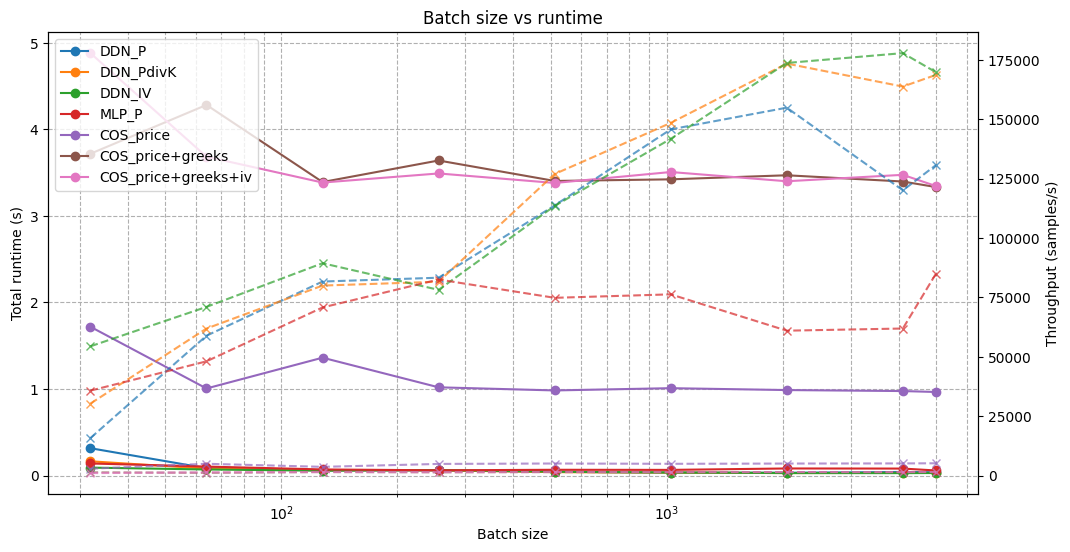


Best/Worst batch per model (runtime + throughput)


,model,best_batch,best_time_s,best_throughput,worst_batch,worst_time_s,worst_throughput
0,COS_price,4989,0.9656,5167,32,1.719,2902
1,COS_price+greeks,4989,3.333,1497,64,4.282,1165
2,COS_price+greeks+iv,4989,3.345,1491,32,4.881,1022
3,DDN_IV,4096,2.805e-02,1.779e+05,32,9.168e-02,5.442e+04
4,DDN_P,2048,3.221e-02,1.549e+05,32,0.3159,1.579e+04
5,DDN_PdivK,2048,2.876e-02,1.735e+05,32,0.1646,3.031e+04
6,MLP_P,4989,5.873e-02,8.495e+04,32,0.1395,3.576e+04


In [9]:
# Toggle this when COS runtime is available and you want COS benchmark rows too.
include_cos = True

# Temporary dry-run setting: benchmark COS on a subset, then extrapolate to full dataset.
# Set to None for full COS benchmarking.
cos_bench_max_rows = None

# --- helpers --------------------------------------------------------------
def has_cos_core_runtime():
    """Check if the core COS pricing and gradient functions are available in the environment."""
    return all(name in globals() for name in ["jnp", "price_jit", "grad_price", "N_COS", "L_COS"])


def has_cos_iv_runtime():
    """Check if IV conversion runtime is available (LBR + shared converter from Cell 10)."""
    return (
        "lbr" in globals()
        and hasattr(lbr, "implied_volatility_from_a_transformed_rational_guess")
        and "_pricehat_to_iv_and_ivgreeks" in globals()
    )


def get_model_device(model):
    """Get the device of the model's parameters (assumes all parameters are on the same device)."""
    return next(model.parameters()).device


def compute_batch_sizes(n_rows):
    """Compute a list of batch sizes to benchmark, based on powers of 2 and the total number of rows."""
    if int(n_rows) <= 0:
        return []
    return sorted(set([2**k for k in range(5, 18) if 2**k <= int(n_rows)] + [int(n_rows)]))


def time_model_per_batch(model, tensor_in, df_in, batch_size, unscale_fn, need_grads=False):
    """Time the model's forward pass, unscale, and output packaging in batches."""
    n_local = min(int(tensor_in.shape[0]), int(len(df_in)))
    if n_local == 0:
        return np.nan

    model_device = get_model_device(model)
    t0 = time.perf_counter()

    for i in range(0, n_local, batch_size):
        x = tensor_in[i : i + batch_size].to(model_device)
        if need_grads:
            x = x.detach().requires_grad_(True)
            pred = model(x)
            grads = torch.autograd.grad(
                pred, x, torch.ones_like(pred), create_graph=False, retain_graph=False
            )[0]
            pred_flat = pred.detach().cpu().numpy().flatten()
            grads_np = grads.detach().cpu().numpy()
        else:
            with torch.no_grad():
                pred = model(x).detach().cpu().numpy()
            pred_flat = pred.flatten() if isinstance(pred, np.ndarray) and pred.ndim > 1 else pred
            grads_np = None

        in_batch = df_in.iloc[i : i + batch_size]
        y, _ = unscale_fn(pred_flat, grads_np, in_batch)
        _ = pd.DataFrame({"pred": y})

    return time.perf_counter() - t0


def time_cos_per_batch(df_input, batch_size, mode, compute_iv_step):
    """
    mode: 'price', 'price+greeks', 'price+greeks+iv'
    compute_iv_step: if False, stage-3 skips IV conversion but is still benchmarked and reported.
    """
    t0 = time.perf_counter()
    greek_names_cos = ["theta", "v0", "sigma", "rho", "kappa"]
    q_local = float(globals().get("q_cos", 0.0))

    for i in range(0, len(df_input), batch_size):
        chunk = df_input.iloc[i : i + batch_size]

        prices_chunk = []
        greeks_chunk = []
        iv_chunk = []
        iv_greeks_chunk = []

        for _, row in chunk.iterrows():
            params = jnp.array(
                [
                    float(row["theta"]),
                    float(row["v0"]),
                    float(row["sigma"]),
                    float(row["rho"]),
                    float(row["kappa"]),
                ],
                dtype=jnp.float64,
            )

            lm_i = float(row["lm"])
            T_i = float(row["T"])
            r_i = float(row["r"])

            p_i = float(price_jit(params, lm_i, T_i, r_i, q_local, N_COS, L_COS))
            prices_chunk.append(p_i)

            g_i = None
            if mode in ("price+greeks", "price+greeks+iv"):
                g_i = np.array(grad_price(params, lm_i, T_i, r_i, q_local, N_COS, L_COS), dtype=float)
                greeks_chunk.append(g_i)

            if mode == "price+greeks+iv":
                if compute_iv_step and g_i is not None:
                    iv_i, iv_g_i, _ = _pricehat_to_iv_and_ivgreeks(p_i, g_i, lm_i, T_i, r_i, q=q_local)
                else:
                    iv_i, iv_g_i = np.nan, None

                iv_chunk.append(iv_i)
                if iv_g_i is None:
                    iv_greeks_chunk.append(np.full(5, np.nan))
                else:
                    iv_greeks_chunk.append(np.asarray(iv_g_i, dtype=float))

        # Include output packaging in timing for parity with NN timing path.
        if mode == "price":
            _ = pd.DataFrame({"Predicted Price": prices_chunk})
        elif mode == "price+greeks":
            out_df = pd.DataFrame({"Predicted Price": prices_chunk})
            if len(greeks_chunk) > 0:
                g_arr = np.vstack(greeks_chunk)
                for j, g_name in enumerate(greek_names_cos):
                    out_df[f"d{g_name}"] = g_arr[:, j]
            _ = out_df
        else:
            out_df = pd.DataFrame({
                "Predicted Price": prices_chunk,
                "Predicted IV": iv_chunk,
            })
            if len(greeks_chunk) > 0:
                g_arr = np.vstack(greeks_chunk)
                for j, g_name in enumerate(greek_names_cos):
                    out_df[f"d{g_name}"] = g_arr[:, j]
            if len(iv_greeks_chunk) > 0:
                ivg_arr = np.vstack(iv_greeks_chunk)
                for j, g_name in enumerate(greek_names_cos):
                    out_df[f"IVd{g_name}"] = ivg_arr[:, j]
            _ = out_df

    return time.perf_counter() - t0


def warmup_cos_runtime(df_input):
    """Warmup COS for price, greeks, and optional IV conversion before benchmarking."""
    if len(df_input) == 0:
        return
    row = df_input.iloc[0]
    q_local = float(globals().get("q_cos", 0.0))
    params = jnp.array(
        [
            float(row["theta"]),
            float(row["v0"]),
            float(row["sigma"]),
            float(row["rho"]),
            float(row["kappa"]),
        ],
        dtype=jnp.float64,
    )
    lm_i = float(row["lm"])
    T_i = float(row["T"])
    r_i = float(row["r"])

    p_i = float(price_jit(params, lm_i, T_i, r_i, q_local, N_COS, L_COS))
    g_i = np.array(grad_price(params, lm_i, T_i, r_i, q_local, N_COS, L_COS), dtype=float)

    if has_cos_iv_runtime():
        _ = _pricehat_to_iv_and_ivgreeks(p_i, g_i, lm_i, T_i, r_i, q=q_local)

def build_cos_subset_and_batch_plan(df_full, model_batches, max_rows):
    """
    Build COS benchmark subset and proportional batch plan against model batch sizes.
    Returns: df_subset, list[(model_batch, cos_batch)], extrapolation_factor
    """
    n_full = len(df_full)
    if n_full == 0:
        return df_full.copy(), [], 1.0

    if max_rows is None or int(max_rows) >= n_full:
        df_subset = df_full.copy().reset_index(drop=True)
    else:
        df_subset = df_full.iloc[: int(max_rows)].copy().reset_index(drop=True)

    n_subset = len(df_subset)
    if n_subset == 0:
        return df_subset, [], 1.0

    plan = []
    for b_model in model_batches:
        b_cos = int(round(float(b_model) * float(n_subset) / float(n_full)))
        b_cos = max(1, min(n_subset, b_cos))
        plan.append((int(b_model), int(b_cos)))

    extrap_factor = float(n_full) / float(n_subset)
    return df_subset, plan, extrap_factor


# --- model benchmark specification ----------------------------------------
model_specs = [
    {
        "name": "DDN_P",
        "model": model_P,
        "tensor": input_DDN_P,
        "df": input_df_DDN_P,
        "need_grads": True,
        "unscale_fn": lambda p, g, dfp: unscale_DDN_P(
            p, g, sqrt_copy.loc[dfp.index].values, pmin, pmax
        ),
    },
    {
        "name": "DDN_PdivK",
        "model": model_PdivK,
        "tensor": input_DDN_PdivK,
        "df": input_df_DDN_PdivK,
        "need_grads": True,
        "unscale_fn": lambda p, g, dfp: unscale_DDN_PdivK(
            p, g, sqrt_copy.loc[dfp.index].values, dfp["lm"].values, pmin, pmax
        ),
    },
    {
        "name": "DDN_IV",
        "model": model_IV,
        "tensor": input_DDN_IV,
        "df": input_df_DDN_IV,
        "need_grads": True,
        "unscale_fn": lambda p, g, dfp: unscale_DDN_IV(
            p, g, sqrt_copy.loc[dfp.index].values
        ),
    },
    {
        "name": "MLP_P",
        "model": model_MLP,
        "tensor": input_MLP_P,
        "df": input_df_MLP_P,
        "need_grads": True,
        "unscale_fn": lambda p, g, dfp: unscale_MLP_P(
            np.asarray(p).flatten(),
            g,
            sqrt_copy.loc[dfp.index].values,
            ymin_MLP,
            ymax_MLP,
        ),
    },
 ]

# Warmup for neural models without overwriting model objects.
for spec in model_specs:
    n_local = min(int(spec["tensor"].shape[0]), int(len(spec["df"])))
    n_warm = min(16, n_local)
    if n_warm == 0:
        continue
    x_warm = spec["tensor"][:n_warm].to(get_model_device(spec["model"]))
    with torch.no_grad():
        _ = spec["model"](x_warm)

# --- benchmark records ----------------------------------------------------
records = []

for spec in model_specs:
    name = spec["name"]
    model = spec["model"]
    tensor_in = spec["tensor"]
    df_in = spec["df"]
    unscale_fn = spec["unscale_fn"]

    n_local = min(int(tensor_in.shape[0]), int(len(df_in)))
    if n_local == 0:
        print(f"Skipping {name}: no samples available.")
        continue

    model_batch_sizes = compute_batch_sizes(n_local)

    for b in tqdm(model_batch_sizes, desc=f"{name} batch sizes"):
        elapsed = time_model_per_batch(
            model,
            tensor_in,
            df_in,
            b,
            unscale_fn,
            need_grads=spec.get("need_grads", False),
        )
        records.append(
            {
                "model": name,
                "batch": b,
                "time": elapsed,
                "details": "full",
                "n_samples": n_local,
            }
        )

cos_core_ok = has_cos_core_runtime()
cos_iv_ok = has_cos_iv_runtime()

if include_cos and cos_core_ok:
    n_cos_total = int(len(df))

    ref_batches = sorted(
        {
            int(r["batch"])
            for r in records
            if isinstance(r, dict) and not str(r.get("model", "")).startswith("COS_")
        }
    )
    if not ref_batches:
        ref_batches = compute_batch_sizes(n_cos_total)

    cos_df_bench, cos_batch_plan, cos_extrap_factor = build_cos_subset_and_batch_plan(
        df, ref_batches, cos_bench_max_rows
    )
    n_cos_eval = len(cos_df_bench)

    if n_cos_eval < n_cos_total:
        print(
            f"COS temporary benchmark mode: evaluating {n_cos_eval}/{n_cos_total} rows, "
            f"using proportional batch sizes, and extrapolating time by x{fmt_sig4(cos_extrap_factor)}."
        )
    else:
        print(
            f"COS full benchmark mode: evaluating all {n_cos_total} rows "
            "(no extrapolation; proportional batch mapping is identity)."
        )

    # Warmup COS once before timing loops (price + greeks + optional IV conversion).
    warmup_cos_runtime(cos_df_bench)

    if not cos_iv_ok:
        print("COS stage-3 IV conversion is unavailable (LetsBeRational missing). Timing will still include COS_price+greeks+iv with IV-step skipped.")

    cos_modes = [
        ("price", False),
        ("price+greeks", False),
        ("price+greeks+iv", cos_iv_ok),
    ]

    cos_loop_desc = "COS batch sizes (scaled)" if n_cos_eval < n_cos_total else "COS batch sizes"
    for b_model, b_cos in tqdm(cos_batch_plan, desc=cos_loop_desc):
        for mode, compute_iv_step in cos_modes:
            # Had runtime errors which made outputs messy so brute force ignore warnings in COS timing loop. Outputs are still captured and will be NaN if failures occur.
            with warnings.catch_warnings():
                warnings.simplefilter("ignore", RuntimeWarning)
                elapsed_subset = time_cos_per_batch(cos_df_bench, b_cos, mode, compute_iv_step=compute_iv_step)
            elapsed_full_equiv = elapsed_subset * cos_extrap_factor
            records.append(
                {
                    "model": f"COS_{mode}",
                    "batch": b_model,
                    "time": elapsed_full_equiv,
                    "details": "full" if (mode != "price+greeks+iv" or compute_iv_step) else "iv-step-skipped",
                    "cos_eval_rows": n_cos_eval,
                    "cos_batch_used": b_cos,
                    "time_subset_s": elapsed_subset,
                    "time_extrap_factor": cos_extrap_factor,
                    "n_samples": n_cos_total,
                }
            )
elif include_cos and not cos_core_ok:
    print("COS requested but runtime objects are missing (jnp/price_jit/grad_price/N_COS/L_COS).")


# --- benchmark records to DataFrame ---------------------------------------
df_bench = pd.DataFrame(records)
if not df_bench.empty:
    if "n_samples" not in df_bench.columns:
        df_bench["n_samples"] = np.nan

    with np.errstate(divide="ignore", invalid="ignore"):
        df_bench["throughput"] = df_bench["n_samples"] / df_bench["time"]
else:
    print("No benchmark records were produced.")

# --- plot ----------------------------------------------------------------
plt.figure(figsize=(12, 6))
for m in df_bench["model"].unique():
    sub = df_bench[df_bench["model"] == m]
    plt.plot(sub["batch"], sub["time"], marker="o", label=m)
plt.xscale("log")
plt.xlabel("Batch size")
plt.ylabel("Total runtime (s)")
plt.title("Batch size vs runtime")
plt.grid(True, which="both", ls="--")
plt.legend(loc="upper left")

ax2 = plt.gca().twinx()
for m in df_bench["model"].unique():
    sub = df_bench[df_bench["model"] == m]
    ax2.plot(sub["batch"], sub["throughput"], marker="x", linestyle="--", alpha=0.7)
ax2.set_ylabel("Throughput (samples/s)")
plt.show()

# --- compact benchmark summary --------------------------------------------
if not df_bench.empty:
    summary_rows = []
    for model_name, sub in df_bench.groupby("model", sort=True):
        sub_num = sub.replace([np.inf, -np.inf], np.nan)

        sub_time = sub_num.dropna(subset=["time"])
        sub_tp = sub_num.dropna(subset=["throughput"])
        if sub_time.empty or sub_tp.empty:
            continue

        best_time_row = sub_time.loc[sub_time["time"].idxmin()]
        worst_time_row = sub_time.loc[sub_time["time"].idxmax()]
        # Throughput is n_samples/time here, so best/worst throughput matches best/worst time.

        row = {
            "model": model_name,
            "best_batch": int(best_time_row["batch"]),
            "best_time_s": float(best_time_row["time"]),
            "best_throughput": float(best_time_row["throughput"]),
            "worst_batch": int(worst_time_row["batch"]),
            "worst_time_s": float(worst_time_row["time"]),
            "worst_throughput": float(worst_time_row["throughput"]),
        }

        summary_rows.append(row)

    bench_summary = pd.DataFrame(summary_rows)
    if not bench_summary.empty:
        print("\nBest/Worst batch per model (runtime + throughput)")
        display(bench_summary.sort_values("model").reset_index(drop=True))

    if "COS_price+greeks+iv" in set(df_bench["model"].astype(str)) and "details" in df_bench.columns:
        stage3_details = df_bench[df_bench["model"] == "COS_price+greeks+iv"]["details"].value_counts()
        # Show detail counts only if something non-standard occurred.
        if not (len(stage3_details) == 1 and "full" in stage3_details.index):
            print("\nCOS stage-3 detail status:")
            print(stage3_details)

## 4) Accuracy Metrics and Master Tables
Build task-specific comparisons for:
1. Price + Greeks
2. Price only
3. IV + IV-Greeks

Tables are aligned to relevant model/COS capabilities and timing sources.
This phase also defines target columns and model buckets reused by later diagnostics.

In [10]:
# =====================================================================
# METRICS COMPARISON (fair-common-mask + max-coverage)
# =====================================================================

# Output controls for cleaner notebooks (metrics are still computed regardless of display toggles).
METRICS_SHOW_FAIR_TABLE = False
METRICS_SHOW_FAIR_COMPACT_LINES = False
METRICS_SHOW_MAX_TABLE = True
METRICS_SHOW_MASTER_TABLES = True

def first_existing_column(df_obj, candidates):
    """Find the first existing column in df_obj from the list of candidates. Returns None if no candidates are found."""
    return next((c for c in candidates if c in df_obj.columns), None)


def _to_1d(x):
    """Convert input to a 1D numpy array, flattening if necessary. Handles lists, Series, and arrays."""
    return np.asarray(x).flatten()


def _prepare_valid_pair(y_true, y_pred):
    """Prepare two 1D arrays of true and predicted values, filtering out non-finite pairs and aligning lengths."""
    yt = _to_1d(y_true)
    yp = _to_1d(y_pred)
    n_total = min(len(yt), len(yp))
    if n_total == 0:
        return np.array([]), np.array([]), 0, 0

    yt = yt[:n_total]
    yp = yp[:n_total]
    mask = np.isfinite(yt) & np.isfinite(yp)
    n_valid = int(np.sum(mask))

    if n_valid == 0:
        return np.array([]), np.array([]), n_total, 0

    return yt[mask], yp[mask], n_total, n_valid


def _metrics_from_filtered(yt, yp):
    """Compute MSE, MAE, and MAPE from two aligned 1D arrays of true and predicted values. Assumes inputs are already filtered for valid pairs."""
    yt = np.asarray(yt, dtype=float)
    yp = np.asarray(yp, dtype=float)
    # Added warnings or celaner output.
    with np.errstate(divide="ignore", invalid="ignore", over="ignore"), warnings.catch_warnings():
        warnings.simplefilter("ignore", RuntimeWarning)
        residual = yp - yt
        abs_residual = np.abs(residual)
        sq_residual = residual * residual

        mse = np.nanmean(sq_residual)
        mae = np.nanmean(abs_residual)

        denominator = np.maximum(np.abs(yt), 1e-8)
        mape = np.nanmean(abs_residual / denominator) * 100.0

    return float(mse), float(mae), float(mape)


def add_metric_row_max(rows, target, model_name, y_true, y_pred):
    """Computes metrics for max-coverage mode: use all valid pairs of (y_true, y_pred) without enforcing a common mask across models. 
    Metrics are computed on the valid subset for each model independently."""
    yt, yp, n_total, n_valid = _prepare_valid_pair(y_true, y_pred)
    if n_valid == 0:
        return

    mse, mae, mape = _metrics_from_filtered(yt, yp)
    coverage = (100.0 * n_valid / n_total) if n_total > 0 else np.nan

    rows.append(
        {
            "Mode": "max-coverage",
            "Target": target,
            "Model": model_name,
            "MSE": mse,
            "MAE": mae,
            "MAPE (%)": mape,
            "N": n_valid,
            "N total": n_total,
            "N valid": n_valid,
            "Coverage (%)": coverage,
        }
    )


def add_metric_rows_fair(rows, target, pred_by_model, y_true):
    """Computes metrics for fair-common-mask mode: enforce a common mask of valid (finite) values across all models and the true values, then compute metrics on this shared subset."""
    if not pred_by_model:
        return

    yt = _to_1d(y_true)
    pred_flat = {name: _to_1d(arr) for name, arr in pred_by_model.items()}

    n_total = min([len(yt)] + [len(arr) for arr in pred_flat.values()])
    if n_total == 0:
        return

    yt = yt[:n_total]
    mask = np.isfinite(yt)
    for arr in pred_flat.values():
        mask &= np.isfinite(arr[:n_total])

    n_valid = int(np.sum(mask))
    if n_valid == 0:
        return

    yt_f = yt[mask]
    coverage = 100.0 * n_valid / n_total

    for model_name, arr in pred_flat.items():
        yp_f = arr[:n_total][mask]
        mse, mae, mape = _metrics_from_filtered(yt_f, yp_f)
        rows.append(
            {
                "Mode": "fair-common-mask",
                "Target": target,
                "Model": model_name,
                "MSE": mse,
                "MAE": mae,
                "MAPE (%)": mape,
                "N": n_valid,
                "N total": n_total,
                "N valid": n_valid,
                "Coverage (%)": coverage,
            }
        )


def iv_to_put_price_from_iv(
    iv,
    lm,
    tau,
    r,
    q=0.0,
    return_meta=False,
    s0=1.0,
    normalize_by_strike=False,
    invalid_iv_policy="mask"
):
    """Convert IV to put price using Black on forward, with optional normalization and metadata."""
    iv = np.asarray(iv, dtype=float).flatten()
    lm = np.asarray(lm, dtype=float).flatten()
    tau = np.asarray(tau, dtype=float).flatten()
    r = np.asarray(r, dtype=float).flatten()

    n = min(len(iv), len(lm), len(tau), len(r))
    if n == 0:
        if return_meta:
            return np.array([]), {
                "n_total": 0,
                "n_invalid_iv_input": 0,
                "n_valid_price_after_conversion": 0,
                "n_nonfinite_price_after_conversion": 0,
            }
        return np.array([])

    iv = iv[:n]
    lm = lm[:n]
    tau = np.clip(tau[:n], 1e-12, None)
    r = r[:n]

    if invalid_iv_policy == "clip":
        valid_iv = np.isfinite(iv)
        iv_work = np.where(valid_iv, np.clip(iv, 1e-8, None), np.nan)
    else:
        valid_iv = np.isfinite(iv) & (iv > 0.0)
        iv_work = np.where(valid_iv, iv, np.nan)

    K = float(s0) * np.exp(-lm)
    F = float(s0) * np.exp((r - q) * tau)

    vol_sqrt_tau = iv_work * np.sqrt(tau)
    d1 = (
        np.log(np.clip(F / np.clip(K, 1e-12, None), 1e-12, None))
        + 0.5 * iv_work * iv_work * tau
    ) / np.clip(vol_sqrt_tau, 1e-12, None)
    d2 = d1 - vol_sqrt_tau

    put_undisc = K * norm.cdf(-d2) - F * norm.cdf(-d1)
    p_abs = np.exp(-r * tau) * put_undisc

    if normalize_by_strike:
        price = p_abs / np.clip(K, 1e-12, None)
    else:
        price = p_abs

    price[~valid_iv] = np.nan
    price[~np.isfinite(price)] = np.nan

    if not return_meta:
        return price

    meta = {
        "n_total": int(n),
        "n_invalid_iv_input": int(np.sum(~valid_iv)),
        "n_valid_price_after_conversion": int(np.sum(np.isfinite(price))),
        "n_nonfinite_price_after_conversion": int(np.sum(~np.isfinite(price))),
    }
    return price, meta


def iv_to_normalized_put_price(iv, lm, T, r, q=0.0):
    """Convert implied volatility to normalized put price for future comparison."""
    return iv_to_put_price_from_iv(
        iv,
        lm,
        T,
        r,
        q=q,
        return_meta=False,
        s0=1.0,
        normalize_by_strike=False,
        invalid_iv_policy="clip",
    )


# ---------------------------------------------------------------------
# Targets
# ---------------------------------------------------------------------
price_target_col = first_existing_column(df, ["price", "P_hat", "p_hat", "price_hat"])
if price_target_col is None:
    raise ValueError("No price target column found in dataset. Expected one of: price, P_hat, p_hat, price_hat")

price_target_label = f"Price ({price_target_col})"
y_true_price = df[price_target_col].values.flatten()

y_true_greeks = {}
for g in relevant_greeks_DDN_P:
    col = first_existing_column(df, [f"d{g}", f"diff wrt {g}"])
    if col is not None:
        y_true_greeks[g] = df[col].values.flatten()

# Prefer the raw IV target column; IV_hat is only a fallback if no raw IV column exists.
iv_target_col = first_existing_column(df, ["IV", "iv", "implied_vol", "implied_volatility", "IV_hat"])
y_true_iv = df[iv_target_col].values.flatten() if iv_target_col is not None else None

y_true_iv_greeks = {}
for g in relevant_greeks_DDN_IV:
    col = first_existing_column(
        df,
        [
            f"IVd{g}",
            f"IV diff wrt {g}",
            f"iv diff wrt {g}",
            f"iv_diff_wrt_{g}",
            f"dIV/d{g}",
            f"dIV_d{g}",
        ],
    )
    if col is not None:
        y_true_iv_greeks[g] = df[col].values.flatten()


# ---------------------------------------------------------------------
# Model outputs by task
# ---------------------------------------------------------------------
price_models = {
    "DDN_P": df_DDN_P,
    "DDN_PdivK": df_DDN_PdivK,
    "MLP_P": df_MLP_P,
}

# For DDN_IV, convert predicted IV to normalized put price for comparison on the same target as DDN_P and MLP_P.
if "df_DDN_IV" in globals() and isinstance(df_DDN_IV, pd.DataFrame) and "Predicted IV" in df_DDN_IV.columns:
    iv_pred = df_DDN_IV["Predicted IV"].values
    iv_price = iv_to_normalized_put_price(iv_pred, df["lm"].values, df["T"].values, df["r"].values)
    df_DDN_IV_price = pd.DataFrame({"Predicted Price": iv_price})
    price_models["DDN_IV"] = df_DDN_IV_price

if "df_COS" in globals() and isinstance(df_COS, pd.DataFrame) and "Predicted Price" in df_COS.columns:
    price_models["COS"] = df_COS

greek_models = {
    "DDN_P": df_DDN_P,
    "DDN_PdivK": df_DDN_PdivK,
    "MLP_P": df_MLP_P,
}
if "df_COS" in globals() and isinstance(df_COS, pd.DataFrame):
    greek_models["COS"] = df_COS

iv_models = {}
if "df_DDN_IV" in globals() and isinstance(df_DDN_IV, pd.DataFrame):
    iv_models["DDN_IV"] = df_DDN_IV
if "df_COS" in globals() and isinstance(df_COS, pd.DataFrame):
    iv_models["COS"] = df_COS


# ---------------------------------------------------------------------
# Build metrics rows: fair-common-mask and max-coverage
# ---------------------------------------------------------------------
metrics_rows_fair = []
metrics_rows_max = []

# Price
price_pred_by_model = {}
for model_name, model_df in price_models.items():
    if "Predicted Price" in model_df.columns:
        pred_vals = model_df["Predicted Price"].values
        price_pred_by_model[model_name] = pred_vals
        add_metric_row_max(metrics_rows_max, price_target_label, model_name, y_true_price, pred_vals)

add_metric_rows_fair(metrics_rows_fair, price_target_label, price_pred_by_model, y_true_price)

# Price Greeks
for g in relevant_greeks_DDN_P:
    if g not in y_true_greeks:
        continue

    target = f"Greek: {g}"
    pred_by_model = {}

    for model_name, model_df in greek_models.items():
        pred_col = first_existing_column(model_df, [f"d{g}", f"diff wrt {g}"])
        if pred_col is None:
            continue

        pred_vals = model_df[pred_col].values
        pred_by_model[model_name] = pred_vals
        add_metric_row_max(metrics_rows_max, target, model_name, y_true_greeks[g], pred_vals)

    add_metric_rows_fair(metrics_rows_fair, target, pred_by_model, y_true_greeks[g])

# IV level
if iv_target_col is not None:
    iv_target_label = f"IV ({iv_target_col})"
    pred_by_model = {}

    for model_name, model_df in iv_models.items():
        pred_iv_col = first_existing_column(model_df, ["Predicted IV", "IV", "iv"])
        if pred_iv_col is None:
            continue

        pred_vals = model_df[pred_iv_col].values
        pred_by_model[model_name] = pred_vals
        add_metric_row_max(metrics_rows_max, iv_target_label, model_name, y_true_iv, pred_vals)

    add_metric_rows_fair(metrics_rows_fair, iv_target_label, pred_by_model, y_true_iv)

# IV Greeks
for g in relevant_greeks_DDN_IV:
    if g not in y_true_iv_greeks:
        continue

    target = f"IV Greek: {g}"
    pred_by_model = {}

    for model_name, model_df in iv_models.items():
        pred_col = first_existing_column(
            model_df,
            [
                f"IVd{g}",
                f"IV diff wrt {g}",
                f"iv diff wrt {g}",
                f"iv_diff_wrt_{g}",
                f"dIV/d{g}",
                f"dIV_d{g}",
            ],
        )
        if pred_col is None:
            continue

        pred_vals = model_df[pred_col].values
        pred_by_model[model_name] = pred_vals
        add_metric_row_max(metrics_rows_max, target, model_name, y_true_iv_greeks[g], pred_vals)

    add_metric_rows_fair(metrics_rows_fair, target, pred_by_model, y_true_iv_greeks[g])


metrics_results_df = pd.DataFrame(metrics_rows_fair)
metrics_results_max_df = pd.DataFrame(metrics_rows_max)

if not metrics_results_df.empty:
    metrics_results_df = metrics_results_df.sort_values(["Target", "Model"]).reset_index(drop=True)
if not metrics_results_max_df.empty:
    metrics_results_max_df = metrics_results_max_df.sort_values(["Target", "Model"]).reset_index(drop=True)

print("\n" + "=" * 100)
print("METRICS SUMMARY")
print("=" * 100)
print(f"fair-common-mask rows: {len(metrics_results_df)}")
print(f"max-coverage rows   : {len(metrics_results_max_df)}")

if METRICS_SHOW_FAIR_TABLE:
    print("\n" + "=" * 100)
    print("METRICS COMPARISON - FAIR (COMMON VALID MASK PER TARGET)")
    print("=" * 100)
    if metrics_results_df.empty:
        print("No comparable fair metrics found. Check available prediction columns and targets.")
    else:
        display(metrics_results_df)

if METRICS_SHOW_FAIR_COMPACT_LINES and not metrics_results_df.empty:
    print("\nCompact fair view:")
    for _, row in metrics_results_df.iterrows():
        print(
            f"{row['Target']:20s} | {row['Model']:10s} | "
            f"MSE: {fmt_sig4(row['MSE'])} | MAE: {fmt_sig4(row['MAE'])} | "
            f"MAPE: {fmt_pct4(row['MAPE (%)'])} | N={int(row['N'])}/{int(row['N total'])} "
            f"({fmt_pct4(row['Coverage (%)'])})"
        )

if METRICS_SHOW_MAX_TABLE:
    print("\n" + "=" * 100)
    print("METRICS COMPARISON - MAX COVERAGE (PER MODEL VALID MASK)")
    print("=" * 100)
    if metrics_results_max_df.empty:
        print("No max-coverage metrics found.")
    else:
        display(metrics_results_max_df)

# =====================================================================
# TASK-SPECIFIC MASTER TABLES (based on FAIR metrics only)
# =====================================================================

def _metric_row(model_candidates, target_exact=None, target_prefix=None):
    """Helper to find the first row in metrics_results_df matching one of the model_candidates and target criteria. Returns the row as a Series or None if not found."""
    if "metrics_results_df" not in globals() or not isinstance(metrics_results_df, pd.DataFrame) or metrics_results_df.empty:
        return None

    for model_name in model_candidates:
        sub = metrics_results_df[metrics_results_df["Model"] == model_name]
        if target_exact is not None:
            sub = sub[sub["Target"] == target_exact]
        if target_prefix is not None:
            sub = sub[sub["Target"].astype(str).str.startswith(target_prefix)]
        if not sub.empty:
            return sub.iloc[0]
    return None


def _metric_value(model_candidates, metric_col, target_exact=None, target_prefix=None):
    """Helper to extract a specific metric value for the first matching row based on model_candidates and target criteria. Returns the metric value as float or NaN if not found."""
    row = _metric_row(model_candidates, target_exact=target_exact, target_prefix=target_prefix)
    if row is None:
        return np.nan
    return float(row[metric_col])


def _metric_n(model_candidates, target_exact=None, target_prefix=None):
    """Helper to extract the N (sample count) for the first matching row based on model_candidates and target criteria. Returns N as int or 0 if not found."""
    row = _metric_row(model_candidates, target_exact=target_exact, target_prefix=target_prefix)
    if row is None:
        return 0
    return int(row["N"])


def _has_metric(model_candidates, target_exact=None, target_prefix=None):
    """Helper to check if a valid metric row exists for the given model_candidates and target criteria. Returns True if a row is found, False otherwise."""
    return _metric_row(model_candidates, target_exact=target_exact, target_prefix=target_prefix) is not None


def _runtime_from_df_bench(model_label, n_total):
    """Helper to extract runtime and throughput for a given model_label and n_total from df_bench. Returns (time, throughput, source) or (NaN, NaN, 'missing') if not found."""
    if "df_bench" not in globals() or not isinstance(df_bench, pd.DataFrame) or df_bench.empty:
        return np.nan, np.nan, "missing"

    sub = df_bench[df_bench["model"].astype(str) == str(model_label)]
    if sub.empty:
        return np.nan, np.nan, "missing"

    if "batch" in sub.columns and np.isfinite(n_total) and (sub["batch"] == int(n_total)).any():
        row = sub[sub["batch"] == int(n_total)].sort_values("time").iloc[0]
    else:
        row = sub.sort_values("time").iloc[0]

    t = float(row["time"])
    tp = float(row["throughput"]) if "throughput" in row.index else (n_total / t if t > 0 else np.nan)
    return t, tp, "df_bench"


def _runtime_for_model(model_label, n_total):
    """Helper to get runtime and throughput for a given model_label, first checking the timings dict if available, then falling back to df_bench. Returns (time, throughput, source)."""
    if "timings" in globals() and isinstance(timings, dict) and model_label in timings:
        t = float(timings[model_label])
        tp = n_total / t if (np.isfinite(n_total) and t > 0) else np.nan
        return t, tp, "timings"
    return _runtime_from_df_bench(model_label, n_total)


def _runtime_for_cos_stage(cos_stage_label, n_total):
    """Helper to get runtime and throughput for a given COS stage label, checking specific timing variables first, then falling back to df_bench. Returns (time, throughput, source)."""
    stage_to_var = {
        "COS_price": "t_price_only",
        "COS_price+greeks": "t_price_greeks",
        "COS_price+greeks+iv": "t_full",
    }
    time_var = stage_to_var.get(cos_stage_label)

    if time_var is not None and time_var in globals():
        t = float(globals()[time_var])
        tp = n_total / t if (np.isfinite(n_total) and t > 0) else np.nan
        return t, tp, time_var

    return _runtime_from_df_bench(cos_stage_label, n_total)


def _drop_all_nan_numeric_columns(df_obj, keep_cols):
    """Helper to drop numeric columns from df_obj that are entirely NaN, while keeping specified columns regardless of their content. Returns the cleaned DataFrame."""
    if df_obj.empty:
        return df_obj

    drop_cols = []
    for col in df_obj.columns:
        if col in keep_cols:
            continue
        if pd.api.types.is_numeric_dtype(df_obj[col]) and df_obj[col].isna().all():
            drop_cols.append(col)

    if drop_cols:
        return df_obj.drop(columns=drop_cols)
    return df_obj


# Total sample count for consistent throughput calculations.
if "df" in globals() and isinstance(df, pd.DataFrame):
    n_total_samples = float(len(df))
elif "input_df" in globals() and isinstance(input_df, pd.DataFrame):
    n_total_samples = float(len(input_df))
else:
    n_total_samples = np.nan


# ---------------------------------------------------------------------
# 1) Price + Greeks
# ---------------------------------------------------------------------
rows_price_greeks = []
price_greek_specs = [
    ("DDN_P", ["DDN_P"], "DDN_P", False),
    ("DDN_PdivK", ["DDN_PdivK"], "DDN_PdivK", False),
    ("COS_stage2_price+greeks", ["COS", "COS_price+greeks"], "COS_price+greeks", True),
]

for row_name, metric_models, timing_key, is_cos in price_greek_specs:
    if is_cos:
        t, tp, tsrc = _runtime_for_cos_stage(timing_key, n_total_samples)
    else:
        t, tp, tsrc = _runtime_for_model(timing_key, n_total_samples)

    has_price = _has_metric(metric_models, target_exact=price_target_label)
    has_any_greek = any(_has_metric(metric_models, target_exact=f"Greek: {g}") for g in relevant_greeks_DDN_P)
    has_runtime = tsrc != "missing" and np.isfinite(t)

    if not (has_price or has_any_greek or has_runtime):
        continue

    out = {
        "Model": row_name,
        "Timing source": tsrc,
        "Runtime (s)": t,
        "Throughput (samples/s)": tp,
        "Price MSE": _metric_value(metric_models, "MSE", target_exact=price_target_label),
        "Price MAE": _metric_value(metric_models, "MAE", target_exact=price_target_label),
        "Price MAPE (%)": _metric_value(metric_models, "MAPE (%)", target_exact=price_target_label),
        "N (price)": _metric_n(metric_models, target_exact=price_target_label),
    }

    for g in relevant_greeks_DDN_P:
        out[f"{g} MSE"] = _metric_value(metric_models, "MSE", target_exact=f"Greek: {g}")
        out[f"{g} MAE"] = _metric_value(metric_models, "MAE", target_exact=f"Greek: {g}")
        out[f"{g} MAPE (%)"] = _metric_value(metric_models, "MAPE (%)", target_exact=f"Greek: {g}")

    rows_price_greeks.append(out)

master_price_greeks_df = pd.DataFrame(rows_price_greeks)
master_price_greeks_df = _drop_all_nan_numeric_columns(
    master_price_greeks_df,
    keep_cols=["Model", "Timing source", "Runtime (s)", "Throughput (samples/s)", "N (price)"],
)


# ---------------------------------------------------------------------
# 2) Price only
# ---------------------------------------------------------------------
rows_price_only = []
price_only_specs = [
    ("MLP_P", ["MLP_P"], "MLP_P", False),
    ("COS_stage1_price", ["COS", "COS_price"], "COS_price", True),
]

for row_name, metric_models, timing_key, is_cos in price_only_specs:
    if is_cos:
        t, tp, tsrc = _runtime_for_cos_stage(timing_key, n_total_samples)
    else:
        t, tp, tsrc = _runtime_for_model(timing_key, n_total_samples)

    has_price = _has_metric(metric_models, target_exact=price_target_label)
    has_runtime = tsrc != "missing" and np.isfinite(t)

    if not (has_price or has_runtime):
        continue

    rows_price_only.append(
        {
            "Model": row_name,
            "Timing source": tsrc,
            "Runtime (s)": t,
            "Throughput (samples/s)": tp,
            "Price MSE": _metric_value(metric_models, "MSE", target_exact=price_target_label),
            "Price MAE": _metric_value(metric_models, "MAE", target_exact=price_target_label),
            "Price MAPE (%)": _metric_value(metric_models, "MAPE (%)", target_exact=price_target_label),
            "N (price)": _metric_n(metric_models, target_exact=price_target_label),
        }
    )

master_price_only_df = pd.DataFrame(rows_price_only)
master_price_only_df = _drop_all_nan_numeric_columns(
    master_price_only_df,
    keep_cols=["Model", "Timing source", "Runtime (s)", "Throughput (samples/s)", "N (price)"],
)


# ---------------------------------------------------------------------
# 3) IV + IV-greeks
# ---------------------------------------------------------------------
rows_iv = []
iv_specs = [
    ("DDN_IV", ["DDN_IV"], "DDN_IV", False),
    ("COS_stage3_price+greeks+iv", ["COS", "COS_price+greeks+iv"], "COS_price+greeks+iv", True),
]

for row_name, metric_models, timing_key, is_cos in iv_specs:
    if is_cos:
        t, tp, tsrc = _runtime_for_cos_stage(timing_key, n_total_samples)
    else:
        t, tp, tsrc = _runtime_for_model(timing_key, n_total_samples)

    has_iv = _has_metric(metric_models, target_prefix="IV (")
    has_any_iv_greek = any(_has_metric(metric_models, target_exact=f"IV Greek: {g}") for g in relevant_greeks_DDN_IV)
    has_runtime = tsrc != "missing" and np.isfinite(t)

    if not (has_iv or has_any_iv_greek or has_runtime):
        continue

    out = {
        "Model": row_name,
        "Timing source": tsrc,
        "Runtime (s)": t,
        "Throughput (samples/s)": tp,
        "IV MSE": _metric_value(metric_models, "MSE", target_prefix="IV ("),
        "IV MAE": _metric_value(metric_models, "MAE", target_prefix="IV ("),
        "IV MAPE (%)": _metric_value(metric_models, "MAPE (%)", target_prefix="IV ("),
        "N (IV)": _metric_n(metric_models, target_prefix="IV ("),
    }

    for g in relevant_greeks_DDN_IV:
        out[f"IV {g} MSE"] = _metric_value(metric_models, "MSE", target_exact=f"IV Greek: {g}")
        out[f"IV {g} MAE"] = _metric_value(metric_models, "MAE", target_exact=f"IV Greek: {g}")
        out[f"IV {g} MAPE (%)"] = _metric_value(metric_models, "MAPE (%)", target_exact=f"IV Greek: {g}")

    rows_iv.append(out)

master_iv_df = pd.DataFrame(rows_iv)
master_iv_df = _drop_all_nan_numeric_columns(
    master_iv_df,
    keep_cols=["Model", "Timing source", "Runtime (s)", "Throughput (samples/s)", "N (IV)"],
)


if METRICS_SHOW_MASTER_TABLES:
    with pd.option_context(
        "display.max_columns", None,
        "display.width", 2000,
        "display.max_colwidth", None,
        "display.expand_frame_repr", False,
    ):
        print("\n" + "=" * 90)
        print("MASTER TABLE 1/3: PRICE + GREEKS (ALL COLUMNS)")
        print("=" * 90)
        if master_price_greeks_df.empty:
            print("No available rows for this table in current run state (likely COS not active).")
        else:
            display(master_price_greeks_df)

        print("\n" + "=" * 90)
        print("MASTER TABLE 2/3: PRICE ONLY (ALL COLUMNS)")
        print("=" * 90)
        if master_price_only_df.empty:
            print("No available rows for this table in current run state.")
        else:
            display(master_price_only_df)

        print("\n" + "=" * 90)
        print("MASTER TABLE 3/3: IV + IV-GREEKS (ALL COLUMNS)")
        print("=" * 90)
        if master_iv_df.empty:
            print("No available rows for this table in current run state.")
        else:
            display(master_iv_df)
else:
    print("\nMaster tables computed but display is suppressed (METRICS_SHOW_MASTER_TABLES=False).")

if iv_target_col is None:
    print("\nNote: No IV target column found in dataset, so IV accuracy columns are omitted.")


METRICS SUMMARY
fair-common-mask rows: 37
max-coverage rows   : 37

METRICS COMPARISON - MAX COVERAGE (PER MODEL VALID MASK)


,Mode,Target,Model,MSE,MAE,MAPE (%),N,N total,N valid,Coverage (%)
0,max-coverage,Greek: kappa,COS,1.158e-02,4.397e-03,3.786e+06,4989,4989,4989,100
1,max-coverage,Greek: kappa,DDN_P,9.353e-08,1.188e-04,3.056e+04,4989,4989,4989,100
2,max-coverage,Greek: kappa,DDN_PdivK,7.764e-08,9.839e-05,3.836e+04,4989,4989,4989,100
3,max-coverage,Greek: kappa,MLP_P,1.836e-06,3.597e-04,1.096e+05,4989,4989,4989,100
4,max-coverage,Greek: rho,COS,4.130e-06,1.573e-04,1.221e+05,4989,4989,4989,100
5,max-coverage,Greek: rho,DDN_P,1.818e-07,2.340e-04,8.118e+04,4989,4989,4989,100
6,max-coverage,Greek: rho,DDN_PdivK,1.481e-07,1.861e-04,9.211e+04,4989,4989,4989,100
7,max-coverage,Greek: rho,MLP_P,4.495e-06,1.126e-03,3.429e+05,4989,4989,4989,100
8,max-coverage,Greek: sigma,COS,3.273e-05,3.480e-04,5.111e+05,4989,4989,4989,100
9,max-coverage,Greek: sigma,DDN_P,1.097e-07,1.787e-04,6.246e+04,4989,4989,4989,100



MASTER TABLE 1/3: PRICE + GREEKS (ALL COLUMNS)


,Model,Timing source,Runtime (s),Throughput (samples/s),Price MSE,Price MAE,Price MAPE (%),N (price),theta MSE,theta MAE,theta MAPE (%),sigma MSE,sigma MAE,sigma MAPE (%),rho MSE,rho MAE,rho MAPE (%),kappa MSE,kappa MAE,kappa MAPE (%),v0 MSE,v0 MAE,v0 MAPE (%)
0,DDN_P,timings,0.2233,2.234e+04,1.942e-08,9.031e-05,60.34,4989,1.338e-05,6.801e-04,2.074e+05,1.097e-07,1.787e-04,6.246e+04,1.818e-07,2.340e-04,8.118e+04,9.353e-08,1.188e-04,3.056e+04,3.673e-06,4.770e-04,1.859e+05
1,DDN_PdivK,timings,4.004e-02,1.246e+05,1.188e-08,5.793e-05,7.747,4989,9.336e-06,4.891e-04,2.134e+05,9.571e-08,1.543e-04,6.234e+04,1.481e-07,1.861e-04,9.211e+04,7.764e-08,9.839e-05,3.836e+04,2.697e-06,3.551e-04,1.398e+05
2,COS_stage2_price+greeks,t_price_greeks,3.188,1565,3.551e-06,9.679e-05,666.8,4989,7.057e-05,4.463e-04,7.364e+05,3.273e-05,3.480e-04,5.111e+05,4.130e-06,1.573e-04,1.221e+05,1.158e-02,4.397e-03,3.786e+06,9.057e-05,5.458e-04,7.393e+05



MASTER TABLE 2/3: PRICE ONLY (ALL COLUMNS)


,Model,Timing source,Runtime (s),Throughput (samples/s),Price MSE,Price MAE,Price MAPE (%),N (price)
0,MLP_P,timings,5.021e-02,9.935e+04,1.760e-07,2.485e-04,122.7,4989
1,COS_stage1_price,t_price_only,0.8965,5565,3.551e-06,9.679e-05,666.8,4989



MASTER TABLE 3/3: IV + IV-GREEKS (ALL COLUMNS)


,Model,Timing source,Runtime (s),Throughput (samples/s),IV MSE,IV MAE,IV MAPE (%),N (IV),IV kappa MSE,IV kappa MAE,IV kappa MAPE (%),IV theta MSE,IV theta MAE,IV theta MAPE (%),IV sigma MSE,IV sigma MAE,IV sigma MAPE (%),IV rho MSE,IV rho MAE,IV rho MAPE (%),IV v0 MSE,IV v0 MAE,IV v0 MAPE (%)
0,DDN_IV,timings,3.387e-02,1.473e+05,5.705e-04,1.502e-03,4.592e+05,4986,6.897e-06,2.455e-04,3.797e+04,3.077e-04,1.228e-03,1.798e+05,9.590e-05,7.182e-04,3.404e+05,1.389e-03,2.260e-03,5.705e+06,1.653e-03,2.800e-03,1.990e+06
1,COS_stage3_price+greeks+iv,t_full,3.447,1447,inf,inf,inf,4986,6.207,8.324e-02,4.787e+05,0.2492,2.439e-02,6.075e+06,0.8671,3.501e-02,6.000e+06,0.3617,2.646e-02,2.972e+07,0.1534,2.385e-02,1.710e+07


## 5) Residual Diagnostics and Surface Visualization
This section evaluates residual behavior and model output structure using:
1. Max-error summaries
2. Q-Q plots
3. Heatmaps for predicted Price/IV surfaces

It reuses the model buckets and targets prepared in the metrics phase.

In [11]:
# ======================================================================
# Multi-model diagnostics: max error, Q-Q plots, and heatmaps
# ======================================================================

def sanitize_aligned_arrays(
    *arrays,
    label,
    report_tag="[sanitize]",
    min_points=1,
    finite_abs_cap=None,
    cap_on_index=0,
    positive_only=False,
    positive_on_index=0,
    report=True,
):
    """Generic sanitizer for aligned numeric arrays.

    Steps:
    1) flatten and align all arrays to shortest length
    2) drop rows with NaN / +inf / -inf in any array
    3) optional finite absolute cap on one selected array
    4) optional positivity filter on one selected array

    Returns:
        clean_arrays (list[np.ndarray]), info (dict), ok (bool)
    """
    if len(arrays) == 0:
        raise ValueError("sanitize_aligned_arrays needs at least one array")

    aligned = [np.asarray(a, dtype=float).flatten() for a in arrays]
    n_total = min(len(a) for a in aligned)
    aligned = [a[:n_total] for a in aligned]

    nan_mask = np.zeros(n_total, dtype=bool)
    posinf_raw = np.zeros(n_total, dtype=bool)
    neginf_raw = np.zeros(n_total, dtype=bool)
    for arr in aligned:
        nan_mask |= np.isnan(arr)
        posinf_raw |= np.isposinf(arr)
        neginf_raw |= np.isneginf(arr)

    posinf_mask = posinf_raw & (~nan_mask)
    neginf_mask = neginf_raw & (~nan_mask) & (~posinf_mask)

    drop_mask = nan_mask | posinf_mask | neginf_mask

    large_mask = np.zeros(n_total, dtype=bool)
    if finite_abs_cap is not None:
        primary = aligned[cap_on_index]
        large_mask = (np.abs(primary) > finite_abs_cap) & (~drop_mask)
        drop_mask |= large_mask

    non_positive_mask = np.zeros(n_total, dtype=bool)
    if positive_only:
        primary = aligned[positive_on_index]
        non_positive_mask = (primary <= 0.0) & (~drop_mask)
        drop_mask |= non_positive_mask

    clean_arrays = [arr[~drop_mask] for arr in aligned]

    info = {
        "n_total": int(n_total),
        "n_nan": int(nan_mask.sum()),
        "n_posinf": int(posinf_mask.sum()),
        "n_neginf": int(neginf_mask.sum()),
        "n_large_finite": int(large_mask.sum()),
        "n_non_positive": int(non_positive_mask.sum()),
        "n_kept": int(clean_arrays[0].size),
    }

    removed_total = int(drop_mask.sum())
    if report and removed_total > 0:
        removed_parts = [
            f"NaN={info['n_nan']}",
            f"+inf={info['n_posinf']}",
            f"-inf={info['n_neginf']}",
        ]
        if finite_abs_cap is not None:
            removed_parts.append(f"|x|>{finite_abs_cap:g}={info['n_large_finite']}")
        if positive_only:
            removed_parts.append(f"non-positive={info['n_non_positive']}")

        print(
            f"{report_tag} {label} | removed "
            + ", ".join(removed_parts)
            + f"; kept={info['n_kept']}/{info['n_total']}"
        )

    ok = info["n_kept"] >= int(min_points)
    if (not ok) and report:
        print(f"[skip] {label} | only {info['n_kept']} valid points after cleaning (need >= {min_points}).")

    return clean_arrays, info, ok


def plot_standardized_qq(
    residuals,
    title,
    label,
    qq_diagnostics,
    finite_abs_cap=1e6,
    show_plot=True,
    diag_group="other",
):
    """Plot Q-Q using a standard Normal reference to explicitly visualize heavy tails."""
    clean_arrays, _, ok = sanitize_aligned_arrays(
        residuals,
        label=label,
        report_tag="[sanitize]",
        min_points=8,
        finite_abs_cap=finite_abs_cap,
        report=True,
    )
    if not ok:
        return

    clean = clean_arrays[0]
    
    # Standardize the residuals so the Q-Q plot scales beautifully
    std_clean = (clean - np.mean(clean)) / (np.std(clean) + 1e-12)

    if show_plot:
        fig, ax = plt.subplots(figsize=(6, 6))
        # Plot against standard Normal distribution
        stats.probplot(std_clean, dist="norm", plot=ax)

        if len(ax.lines) >= 2:
            ax.lines[-1].set_color("red")
            ax.lines[-1].set_linewidth(1.4)
            ax.lines[-1].set_label("Theoretical Normal")
            ax.legend(loc="best")

        ax.set_title(title)
        ax.set_xlabel("Theoretical quantiles (Normal)")
        ax.set_ylabel("Standardized Residuals")
        ax.grid(alpha=0.2)
        plt.show()

    skew = float(stats.skew(clean, bias=False))
    ex_kurt = float(stats.kurtosis(clean, fisher=True, bias=False))
    qq_diagnostics.append(
        {
            "group": diag_group,
            "plot_order": int(len(qq_diagnostics) + 1),
            "label": label,
            "n": int(clean.size),
            "skew": skew,
            "excess_kurtosis": ex_kurt,
        }
    )


def plot_binned_heatmap(
    pred_values,
    value_name,
    model_name,
    cmap,
    finite_abs_cap=1e6,
    positive_only=False,
    min_bin_count=3,
    color_clip_pct=(2.0, 98.0),
    show_plot=True,
    ):
    """Robust heatmap builder: drops invalids/outliers and masks sparse bins."""
    y_pred = np.asarray(pred_values, dtype=float).flatten()
    lm_vals = np.asarray(df["lm"].values, dtype=float).flatten()
    t_vals = np.asarray(df["T"].values, dtype=float).flatten()

    clean_arrays, _, ok = sanitize_aligned_arrays(
        y_pred,
        lm_vals,
        t_vals,
        label=f"{model_name} {value_name}",
        report_tag="[sanitize-heatmap]",
        min_points=1,
        finite_abs_cap=finite_abs_cap,
        cap_on_index=0,
        positive_only=positive_only,
        positive_on_index=0,
        report=True,
    )
    if not ok:
        print(f"[skip] Heatmap: {value_name} ({model_name}) | no valid values after cleaning.")
        return

    y_pred_clean, lm_clean, t_clean = clean_arrays

    heat_df = pd.DataFrame(
        {
            value_name: y_pred_clean,
            "log_moneyness": lm_clean,
            "T": t_clean,
        }
    )

    finite_df = heat_df.copy()

    finite_df["lm_bin"] = pd.cut(finite_df["log_moneyness"], bins=20, duplicates="drop")
    finite_df["T_bin"] = pd.cut(finite_df["T"], bins=20, duplicates="drop")

    pivot_mean = finite_df.pivot_table(
        index="lm_bin",
        columns="T_bin",
        values=value_name,
        aggfunc="mean",
        observed=False,
    )
    pivot_count = finite_df.pivot_table(
        index="lm_bin",
        columns="T_bin",
        values=value_name,
        aggfunc="count",
        observed=False,
    )

    pivot_mean = pivot_mean.iloc[::-1]
    pivot_count = pivot_count.reindex_like(pivot_mean)
    sparse_mask = pivot_count < min_bin_count

    vmin = None
    vmax = None
    vals = finite_df[value_name].to_numpy(dtype=float)
    if vals.size >= 20:
        q_lo, q_hi = color_clip_pct
        vmin = float(np.nanpercentile(vals, q_lo))
        vmax = float(np.nanpercentile(vals, q_hi))
        if (not np.isfinite(vmin)) or (not np.isfinite(vmax)) or vmax <= vmin:
            vmin = None
            vmax = None

    if not show_plot:
        return

    plt.figure(figsize=(10, 6))
    sns.heatmap(pivot_mean, cmap=cmap, mask=sparse_mask, vmin=vmin, vmax=vmax)
    plt.title(f"Heatmap: {value_name} by Log-Moneyness and Tau ({model_name})")
    plt.xlabel("Time to Maturity (Tau)")
    plt.ylabel("Log-Moneyness")
    plt.show()

    if (vmin is not None) and (vmax is not None):
        q_lo, q_hi = color_clip_pct
        print(
            f"[heatmap-scale] {model_name} {value_name} | clipped color scale to p{q_lo:g}-p{q_hi:g}: "
            f"[{vmin:.4g}, {vmax:.4g}]"
        )


price_models_diag = {k: v for k, v in price_models.items() if k != "DDN_IV"}
greek_models_diag = dict(greek_models)
iv_models_diag = dict(iv_models)
has_cos_df = ("COS" in price_models_diag) or ("COS" in greek_models_diag) or ("COS" in iv_models_diag)


print("\n" + "=" * 90)
print("MAX ERROR SUMMARY (ALL AVAILABLE MODELS)")
print("=" * 90)

# Price max errors
for model_name, model_df in price_models_diag.items():
    if "Predicted Price" not in model_df.columns:
        continue

    clean_arrays, _, ok = sanitize_aligned_arrays(
        y_true_price,
        model_df["Predicted Price"].values,
        label=f"{model_name} Price max error",
        report_tag="[sanitize-max]",
        min_points=1,
        report=True,
    )
    if not ok:
        continue

    y_true_p, y_pred_p = clean_arrays
    max_error_price = np.max(np.abs(y_pred_p - y_true_p))
    print(f"{model_name:10s} | Price max error: {fmt_sig4(max_error_price)}")

# Price-greek max errors
for model_name, model_df in greek_models_diag.items():
    printed_header = False
    for g in relevant_greeks_DDN_P:
        pred_col = f"d{g}"
        if g in y_true_greeks and pred_col in model_df.columns:
            clean_arrays, _, ok = sanitize_aligned_arrays(
                y_true_greeks[g],
                model_df[pred_col].values,
                label=f"{model_name} Greek {g} max error",
                report_tag="[sanitize-max]",
                min_points=1,
                report=True,
            )
            if not ok:
                continue

            if not printed_header:
                print(f"{model_name:10s} | Greek max errors:")
                printed_header = True

            y_true_g, y_pred_g = clean_arrays
            max_error_g = np.max(np.abs(y_pred_g - y_true_g))
            print(f"  {g:8s}: {fmt_sig4(max_error_g)}")

# IV max errors
if iv_target_col is not None:
    for model_name, model_df in iv_models_diag.items():
        pred_iv_col = first_existing_column(model_df, ["Predicted IV", "IV", "iv"])
        if pred_iv_col is not None:
            clean_arrays, _, ok = sanitize_aligned_arrays(
                y_true_iv,
                model_df[pred_iv_col].values,
                label=f"{model_name} IV max error",
                report_tag="[sanitize-max]",
                min_points=1,
                report=True,
            )
            if not ok:
                continue

            y_true_i, y_pred_i = clean_arrays
            max_error_iv = np.max(np.abs(y_pred_i - y_true_i))
            print(f"{model_name:10s} | IV max error: {fmt_sig4(max_error_iv)}")

# IV-greek max errors
for model_name, model_df in iv_models_diag.items():
    printed_ivg = False
    for g in relevant_greeks_DDN_IV:
        pred_col = first_existing_column(
            model_df,
            [
                f"IVd{g}",
                f"iv diff wrt {g}",
                f"iv_diff_wrt_{g}",
                f"dIV/d{g}",
                f"dIV_d{g}",
            ],
        )
        if g in y_true_iv_greeks and pred_col is not None:
            clean_arrays, _, ok = sanitize_aligned_arrays(
                y_true_iv_greeks[g],
                model_df[pred_col].values,
                label=f"{model_name} IV Greek {g} max error",
                report_tag="[sanitize-max]",
                min_points=1,
                report=True,
            )
            if not ok:
                continue

            if not printed_ivg:
                print(f"{model_name:10s} | IV-greek max errors:")
                printed_ivg = True

            y_true_g, y_pred_g = clean_arrays
            max_error_g = np.max(np.abs(y_pred_g - y_true_g))
            print(f"  {g:8s}: {fmt_sig4(max_error_g)}")


# -----------------------------
# Q-Q plots
# -----------------------------
qq_diagnostics = []
QQ_SHOW_PLOTS = False # Set True to render all Q-Q figures.
print(f"Q-Q plots enabled: {QQ_SHOW_PLOTS}")
if not QQ_SHOW_PLOTS:
    print("Q-Q figure rendering is disabled; only diagnostics tables will be computed.")

# Price residuals
for model_name, model_df in price_models_diag.items():
    if "Predicted Price" not in model_df.columns:
        continue

    y_true_p = np.asarray(y_true_price).flatten()
    y_pred_p = np.asarray(model_df["Predicted Price"].values).flatten()
    n = min(len(y_true_p), len(y_pred_p))
    residuals = y_pred_p[:n] - y_true_p[:n]
    plot_standardized_qq(
        residuals,
        title=f"Q-Q Plot for Price Residuals ({model_name})",
        label=f"Price residuals ({model_name})",
        qq_diagnostics=qq_diagnostics,
        show_plot=QQ_SHOW_PLOTS,
        diag_group="price",
        finite_abs_cap=1e6,
    )

# Price-greek residuals
for model_name, model_df in greek_models_diag.items():
    for g in relevant_greeks_DDN_P:
        pred_col = f"d{g}"
        if g in y_true_greeks and pred_col in model_df.columns:
            y_true_g = np.asarray(y_true_greeks[g]).flatten()
            y_pred_g = np.asarray(model_df[pred_col].values).flatten()
            n = min(len(y_true_g), len(y_pred_g))
            residuals_g = y_pred_g[:n] - y_true_g[:n]
            plot_standardized_qq(
                residuals_g,
                title=f"Q-Q Plot for Greek {g} Residuals ({model_name})",
                label=f"Greek {g} residuals ({model_name})",
                qq_diagnostics=qq_diagnostics,
                show_plot=QQ_SHOW_PLOTS,
                diag_group="greeks",
                finite_abs_cap=1e6,
            )

# IV residuals
if iv_target_col is not None:
    for model_name, model_df in iv_models_diag.items():
        pred_iv_col = first_existing_column(model_df, ["Predicted IV", "IV", "iv"])
        if pred_iv_col is not None:
            y_true_i = np.asarray(y_true_iv).flatten()
            y_pred_i = np.asarray(model_df[pred_iv_col].values).flatten()
            n = min(len(y_true_i), len(y_pred_i))
            residuals_i = y_pred_i[:n] - y_true_i[:n]
            plot_standardized_qq(
                residuals_i,
                title=f"Q-Q Plot for IV Residuals ({model_name})",
                label=f"IV residuals ({model_name})",
                qq_diagnostics=qq_diagnostics,
                show_plot=QQ_SHOW_PLOTS,
                diag_group="iv",
                finite_abs_cap=1e6,
            )

# IV-greek residuals
for model_name, model_df in iv_models_diag.items():
    for g in relevant_greeks_DDN_IV:
        pred_col = first_existing_column(
            model_df,
            [
                f"IVd{g}",
                f"iv diff wrt {g}",
                f"iv_diff_wrt_{g}",
                f"dIV/d{g}",
                f"dIV_d{g}",
            ],
        )
        if g in y_true_iv_greeks and pred_col is not None:
            y_true_g = np.asarray(y_true_iv_greeks[g]).flatten()
            y_pred_g = np.asarray(model_df[pred_col].values).flatten()
            n = min(len(y_true_g), len(y_pred_g))
            residuals_g = y_pred_g[:n] - y_true_g[:n]
            plot_standardized_qq(
                residuals_g,
                title=f"Q-Q Plot for IV Greek {g} Residuals ({model_name})",
                label=f"IV Greek {g} residuals ({model_name})",
                qq_diagnostics=qq_diagnostics,
                show_plot=QQ_SHOW_PLOTS,
                diag_group="ivgreeks",
                finite_abs_cap=1e6,
            )

if qq_diagnostics:
    qq_diag_df = pd.DataFrame(qq_diagnostics)
    qq_diag_df["group"] = pd.Categorical(
        qq_diag_df["group"],
        categories=["price", "greeks", "iv", "ivgreeks", "other"],
        ordered=True,
    )
    qq_diag_df = qq_diag_df.sort_values(["group", "plot_order"], kind="stable").reset_index(drop=True)

    print("\n" + "-" * 105)
    print("Q-Q DIAGNOSTICS (PLOT ORDER: price -> greeks -> iv -> ivgreeks)")
    print("-" * 105)
    print(f"Total diagnostics computed: {len(qq_diag_df)}; showing all rows.")
    
    
    print(
        qq_diag_df[["group", "label", "n", "skew", "excess_kurtosis"]]
        .to_string(index=False)
    )
else:
    print("No Q-Q diagnostics were computed.")


# -----------------------------
# Heatmaps
# -----------------------------
HEATMAP_SHOW_PLOTS = False  # Set True to render heatmap figures.
print(f"Heatmap plots enabled: {HEATMAP_SHOW_PLOTS}")
if not HEATMAP_SHOW_PLOTS:
    print("Heatmap figure rendering is disabled.")

# Price heatmap: Predicted Price over (lm, tau)
for model_name, model_df in price_models_diag.items():
    if "Predicted Price" not in model_df.columns:
        continue

    plot_binned_heatmap(
        pred_values=model_df["Predicted Price"].values,
        value_name="Predicted Price",
        model_name=model_name,
        cmap="viridis",
        finite_abs_cap=1e6,
        positive_only=False,
        min_bin_count=3,
        color_clip_pct=(2.0, 98.0),
        show_plot=HEATMAP_SHOW_PLOTS,
    )

# IV heatmap: Predicted IV over (lm, tau)
for model_name, model_df in iv_models_diag.items():
    pred_iv_col = first_existing_column(model_df, ["Predicted IV", "IV", "iv"])
    if pred_iv_col is None:
        continue

    plot_binned_heatmap(
        pred_values=model_df[pred_iv_col].values,
        value_name="Predicted IV",
        model_name=model_name,
        cmap="magma",
        finite_abs_cap=5.0,
        positive_only=True,
        min_bin_count=3,
        color_clip_pct=(2.0, 98.0),
        show_plot=HEATMAP_SHOW_PLOTS,
    )

if not has_cos_df:
    print("\nCOS diagnostics are skipped because df_COS is not available in the current run state.")


MAX ERROR SUMMARY (ALL AVAILABLE MODELS)
DDN_P      | Price max error: 1.623e-03
DDN_PdivK  | Price max error: 1.725e-03
MLP_P      | Price max error: 5.494e-03
COS        | Price max error: 8.452e-02
DDN_P      | Greek max errors:
  theta   : 0.1473
  sigma   : 1.086e-02
  rho     : 9.898e-03
  kappa   : 1.085e-02
  v0      : 6.662e-02
DDN_PdivK  | Greek max errors:
  theta   : 0.1276
  sigma   : 8.061e-03
  rho     : 9.697e-03
  kappa   : 1.096e-02
  v0      : 5.760e-02
MLP_P      | Greek max errors:
  theta   : 0.8324
  sigma   : 3.684e-02
  rho     : 5.801e-02
  kappa   : 6.144e-02
  v0      : 0.1925
COS        | Greek max errors:
  theta   : 0.4393
  sigma   : 0.2427
  rho     : 8.391e-02
  kappa   : 6.015
  v0      : 0.4595
[sanitize-max] DDN_IV IV max error | removed NaN=3, +inf=0, -inf=0; kept=4986/4989
DDN_IV     | IV max error: 1.001
[sanitize-max] COS IV max error | removed NaN=3, +inf=0, -inf=0; kept=4986/4989
COS        | IV max error: 1.798e+308
[sanitize-max] DDN_IV IV 

## 6) Greek Evaluation Suite
This grouped block covers all Greek-focused evaluation cells:
1. Directional accuracy checks for price-greek and IV-greek signs.
2. Higher-order autograd derivative helpers for DDN_PdivK and DDN_P.
3. Visual validation grids against COS and COS-IV baselines.
4. Empirical Lipschitz continuity diagnostics in log-moneyness.

Run this full block together before moving to arbitrage diagnostics.

In [12]:
#=============================================================================
# Directional accuracy for Greeks and IV-greeks per model
#=============================================================================

print("\n" + "=" * 90)
print("DIRECTIONAL ACCURACY: PRICE GREEKS")
print("=" * 90)

if not greek_models:
    print("No compatible price-greek directional columns found for current models.")

for model_name, model_df in greek_models.items():
    any_printed = False

    for g in relevant_greeks_DDN_P:
        pred_col = f"d{g}"
        if g in y_true_greeks and pred_col in model_df.columns:
            y_true = np.asarray(y_true_greeks[g]).flatten()
            y_pred = np.asarray(model_df[pred_col].values).flatten()
            n = min(len(y_true), len(y_pred))

            true_signs = np.sign(y_true[:n])
            pred_signs = np.sign(y_pred[:n])
            directional_accuracy = np.mean(true_signs == pred_signs) * 100

            if not any_printed:
                print(f"{model_name}:")
                any_printed = True
            print(f"  {g:10s}: {fmt_pct4(directional_accuracy)}")

    if not any_printed:
        print(f"{model_name}: no compatible greek columns found")


print("\n" + "=" * 90)
print("DIRECTIONAL ACCURACY: IV GREEKS")
print("=" * 90)

if not y_true_iv_greeks:
    print("No IV-greek targets found in the current dataset.")
elif not iv_models:
    print("No compatible IV-greek directional columns found for current models.")
else:
    for model_name, model_df in iv_models.items():
        any_printed = False

        for g in relevant_greeks_DDN_IV:
            pred_col = first_existing_column(
                model_df,
                [
                    f"IVd{g}",
                    f"iv diff wrt {g}",
                    f"iv_diff_wrt_{g}",
                    f"dIV/d{g}",
                    f"dIV_d{g}",
                ],
            )
            if g in y_true_iv_greeks and pred_col is not None:
                y_true = np.asarray(y_true_iv_greeks[g]).flatten()
                y_pred = np.asarray(model_df[pred_col].values).flatten()
                n = min(len(y_true), len(y_pred))

                true_signs = np.sign(y_true[:n])
                pred_signs = np.sign(y_pred[:n])
                directional_accuracy = np.mean(true_signs == pred_signs) * 100

                if not any_printed:
                    print(f"{model_name}:")
                    any_printed = True
                print(f"  IV {g:7s}: {fmt_pct4(directional_accuracy)}")

        if not any_printed:
            print(f"{model_name}: no compatible IV-greek columns found")


DIRECTIONAL ACCURACY: PRICE GREEKS
DDN_P:
  theta     : 97.03%
  sigma     : 96.97%
  rho       : 97.17%
  kappa     : 95.85%
  v0        : 97.92%
DDN_PdivK:
  theta     : 97.21%
  sigma     : 96.93%
  rho       : 97.61%
  kappa     : 96.51%
  v0        : 97.84%
MLP_P:
  theta     : 95.77%
  sigma     : 94.47%
  rho       : 95.49%
  kappa     : 94.57%
  v0        : 97.19%
COS:
  theta     : 98.54%
  sigma     : 98.36%
  rho       : 98.64%
  kappa     : 98.38%
  v0        : 98.96%

DIRECTIONAL ACCURACY: IV GREEKS
DDN_IV:
  IV kappa  : 99.42%
  IV theta  : 99.64%
  IV sigma  : 99.58%
  IV rho    : 99.54%
  IV v0     : 99.7%
COS:
  IV kappa  : 97.55%
  IV theta  : 97.8%
  IV sigma  : 97.63%
  IV rho    : 97.78%
  IV v0     : 97.86%


In [13]:
# Shared feature layout for the Greek evaluation suite.

FEATURE_COLS_DEFAULT = ['kappa', 'theta', 'v0', 'rho', 'sigma', 'r', 'lm', 'T']
FEATURE_COLS_MLP_DEFAULT = ['kappa', 'v0', 'theta', 'rho', 'sigma', 'r', 'lm', 'T']

LM_COL = 'lm'


def _resolve_feature_cols():

    ddn_sources = ['input_df_DDN_P', 'input_df_DDN_PdivK', 'input_df_DDN_IV']

    available = {

        name: list(globals()[name].columns)

        for name in ddn_sources

        if name in globals()

    }

    if not available:

        return FEATURE_COLS_DEFAULT



    first_name = next(iter(available))

    base_cols = available[first_name]

    mismatched = {

        name: cols

        for name, cols in available.items()

        if cols != base_cols

    }

    if mismatched:

        details = '; '.join(f"{name}: {cols}" for name, cols in available.items())

        raise ValueError(

            "DDN input feature orders differ across models. "

            "Greek evaluation currently assumes one shared feature order. "

            f"Detected -> {details}"

        )

    return base_cols


def _resolve_feature_cols_mlp():

    mlp_sources = ['input_df_MLP_P', 'input_raw_MLP_P']

    for name in mlp_sources:

        if name in globals():

            cols = list(globals()[name].columns)

            if cols:

                return cols

    return FEATURE_COLS_MLP_DEFAULT


FEATURE_COLS = _resolve_feature_cols()
FEATURE_COLS_MLP = _resolve_feature_cols_mlp()

if LM_COL not in FEATURE_COLS:

    raise ValueError(f"'{LM_COL}' is missing from FEATURE_COLS: {FEATURE_COLS}")

if LM_COL not in FEATURE_COLS_MLP:

    raise ValueError(f"'{LM_COL}' is missing from FEATURE_COLS_MLP: {FEATURE_COLS_MLP}")

LM_IDX = FEATURE_COLS.index(LM_COL)
LM_IDX_MLP = FEATURE_COLS_MLP.index(LM_COL)


def _feature_tensor(df_features, requires_grad=True, feature_cols=None):

    if feature_cols is None:

        feature_cols = FEATURE_COLS

    missing = [c for c in feature_cols if c not in df_features.columns]

    if missing:

        raise ValueError(f"Missing required feature columns: {missing}")

    return torch.tensor(

        df_features.loc[:, feature_cols].values,

        dtype=torch.float32,

        requires_grad=requires_grad,

    )



# Higher-order Greeks for P/K using autograd on scaled inputs.

def get_delta_gamma_PdivK(model, x_scaled, lm_raw, lm_min, lm_max):

    if not x_scaled.requires_grad:

        x_scaled = x_scaled.clone().detach().requires_grad_(True)



    f = model(x_scaled)

    if f.ndim > 1:

        f = f.squeeze(-1)



    grads = torch.autograd.grad(

        f,

        x_scaled,

        grad_outputs=torch.ones_like(f),

        create_graph=True,

        retain_graph=True,

    )[0]



    df_scaled = grads[:, LM_IDX]



    d2f_scaled = torch.autograd.grad(

        df_scaled,

        x_scaled,

        grad_outputs=torch.ones_like(df_scaled),

        create_graph=False,

        retain_graph=False,

    )[0][:, LM_IDX]



    lm_scale = 2.0 / (float(lm_max) - float(lm_min))

    df_dlm = df_scaled * lm_scale

    d2f_dlm2 = d2f_scaled * (lm_scale ** 2)



    lm_raw_np = np.asarray(lm_raw, dtype=np.float32)

    lm_raw_t = torch.tensor(lm_raw_np.copy(), dtype=f.dtype, device=f.device)

    if lm_raw_t.ndim == 0:

        lm_raw_t = lm_raw_t.repeat(f.shape[0])



    exp_minus_lm = torch.exp(-lm_raw_t)

    price = exp_minus_lm * f

    delta = exp_minus_lm * df_dlm

    gamma = exp_minus_lm * (d2f_dlm2 - df_dlm)



    return (

        price.detach().cpu().numpy(),

        delta.detach().cpu().numpy(),

        gamma.detach().cpu().numpy(),

    )




def get_delta_gamma_P(model, x_scaled, lm_min, lm_max, pmin, pmax):

    if not x_scaled.requires_grad:

        x_scaled = x_scaled.clone().detach().requires_grad_(True)



    pred_scaled = model(x_scaled)

    if pred_scaled.ndim > 1:

        pred_scaled = pred_scaled.squeeze(-1)



    grads = torch.autograd.grad(

        pred_scaled,

        x_scaled,

        grad_outputs=torch.ones_like(pred_scaled),

        create_graph=True,

        retain_graph=True,

    )[0]



    dpred_scaled = grads[:, LM_IDX]



    d2pred_scaled = torch.autograd.grad(

        dpred_scaled,

        x_scaled,

        grad_outputs=torch.ones_like(dpred_scaled),

        create_graph=False,

        retain_graph=False,

    )[0][:, LM_IDX]



    lm_scale = 2.0 / (float(lm_max) - float(lm_min))

    price_scale = float(pmax) - float(pmin)



    price = pred_scaled * price_scale + float(pmin)

    dp_dm = dpred_scaled * lm_scale * price_scale

    d2p_dm2 = d2pred_scaled * (lm_scale ** 2) * price_scale



    # Same lm-chain convention used for COS conversion in this notebook.

    delta = price + dp_dm

    gamma = d2p_dm2 + dp_dm



    return (

        price.detach().cpu().numpy(),

        delta.detach().cpu().numpy(),

        gamma.detach().cpu().numpy(),

    )


def get_delta_gamma_MLP(model, x_scaled, lm_min, lm_max, ymin, ymax):

    if ymin is None or ymax is None:

        raise ValueError("ymin/ymax must be provided for MLP scaling.")



    if not x_scaled.requires_grad:

        x_scaled = x_scaled.clone().detach().requires_grad_(True)



    pred_scaled = model(x_scaled)

    if pred_scaled.ndim > 1:

        pred_scaled = pred_scaled.squeeze(-1)



    grads = torch.autograd.grad(

        pred_scaled,

        x_scaled,

        grad_outputs=torch.ones_like(pred_scaled),

        create_graph=True,

        retain_graph=True,

    )[0]



    dpred_scaled = grads[:, LM_IDX]



    d2pred_scaled = torch.autograd.grad(

        dpred_scaled,

        x_scaled,

        grad_outputs=torch.ones_like(dpred_scaled),

        create_graph=False,

        retain_graph=False,

    )[0][:, LM_IDX]



    lm_scale = 2.0 / (float(lm_max) - float(lm_min))

    price_scale = float(ymax) - float(ymin)



    price = pred_scaled * price_scale + float(ymin)

    dp_dm = dpred_scaled * lm_scale * price_scale

    d2p_dm2 = d2pred_scaled * (lm_scale ** 2) * price_scale



    # Same lm-chain convention used for COS conversion in this notebook.

    delta = price + dp_dm

    gamma = d2p_dm2 + dp_dm



    return (

        price.detach().cpu().numpy(),

        delta.detach().cpu().numpy(),

        gamma.detach().cpu().numpy(),

    )




def get_iv_lm_derivatives(model, x_scaled, lm_min, lm_max):

    if not x_scaled.requires_grad:

        x_scaled = x_scaled.clone().detach().requires_grad_(True)



    iv = model(x_scaled)

    if iv.ndim > 1:

        iv = iv.squeeze(-1)



    grads = torch.autograd.grad(

        iv,

        x_scaled,

        grad_outputs=torch.ones_like(iv),

        create_graph=True,

        retain_graph=True,

    )[0]



    div_scaled = grads[:, LM_IDX]



    d2iv_scaled = torch.autograd.grad(

        div_scaled,

        x_scaled,

        grad_outputs=torch.ones_like(div_scaled),

        create_graph=False,

        retain_graph=False,

    )[0][:, LM_IDX]



    lm_scale = 2.0 / (float(lm_max) - float(lm_min))

    div_dlm = div_scaled * lm_scale

    d2iv_dlm2 = d2iv_scaled * (lm_scale ** 2)



    return (

        iv.detach().cpu().numpy(),

        div_dlm.detach().cpu().numpy(),

        d2iv_dlm2.detach().cpu().numpy(),

    )

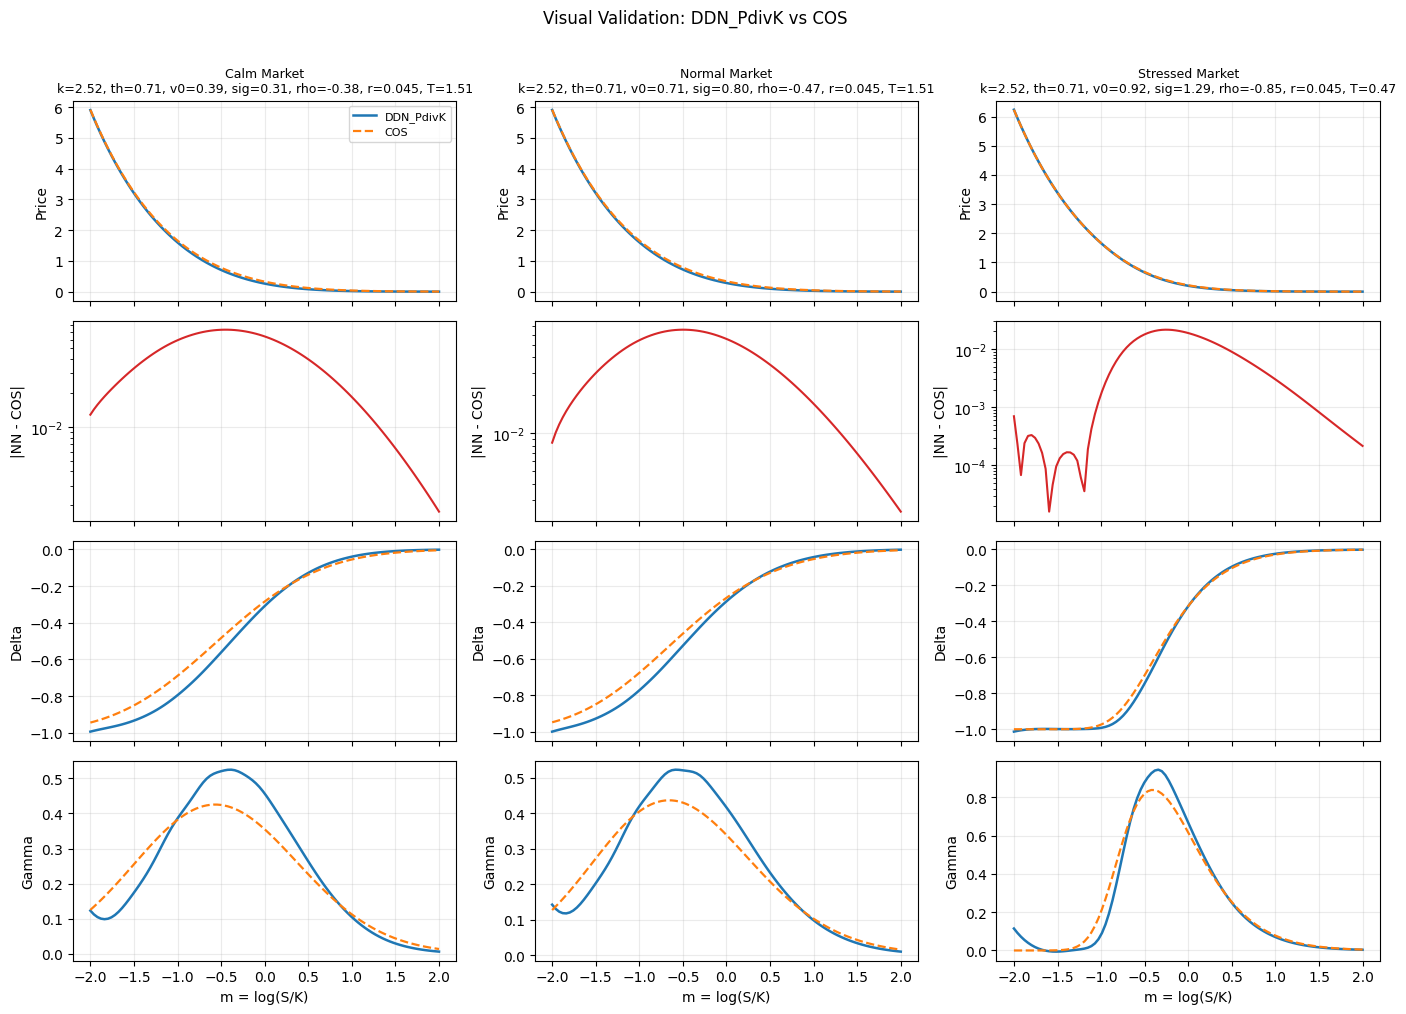

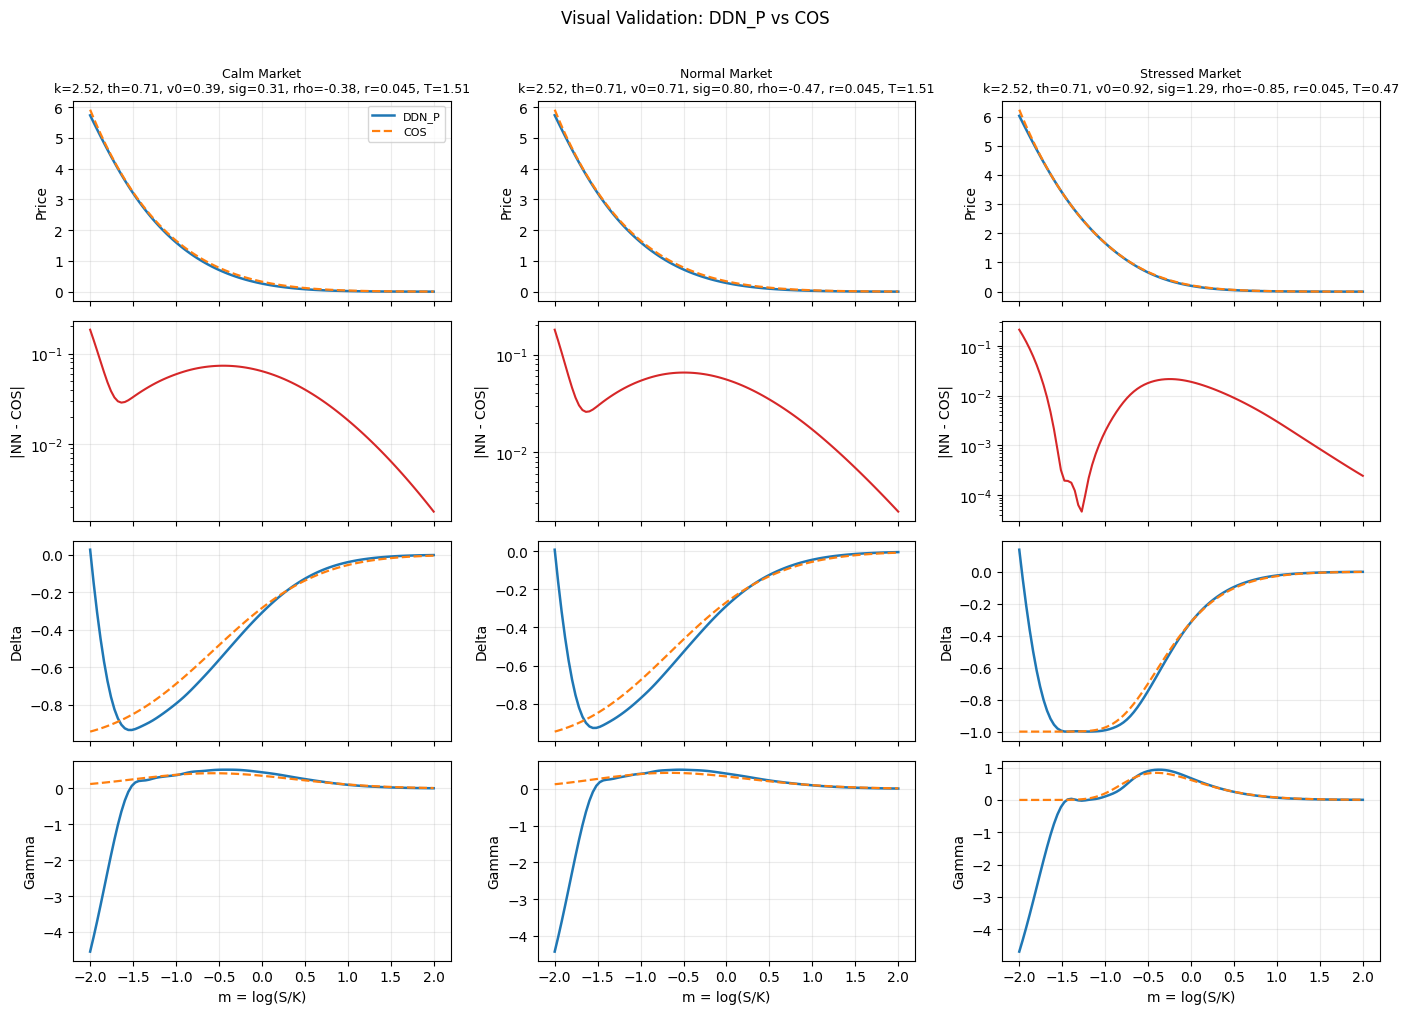

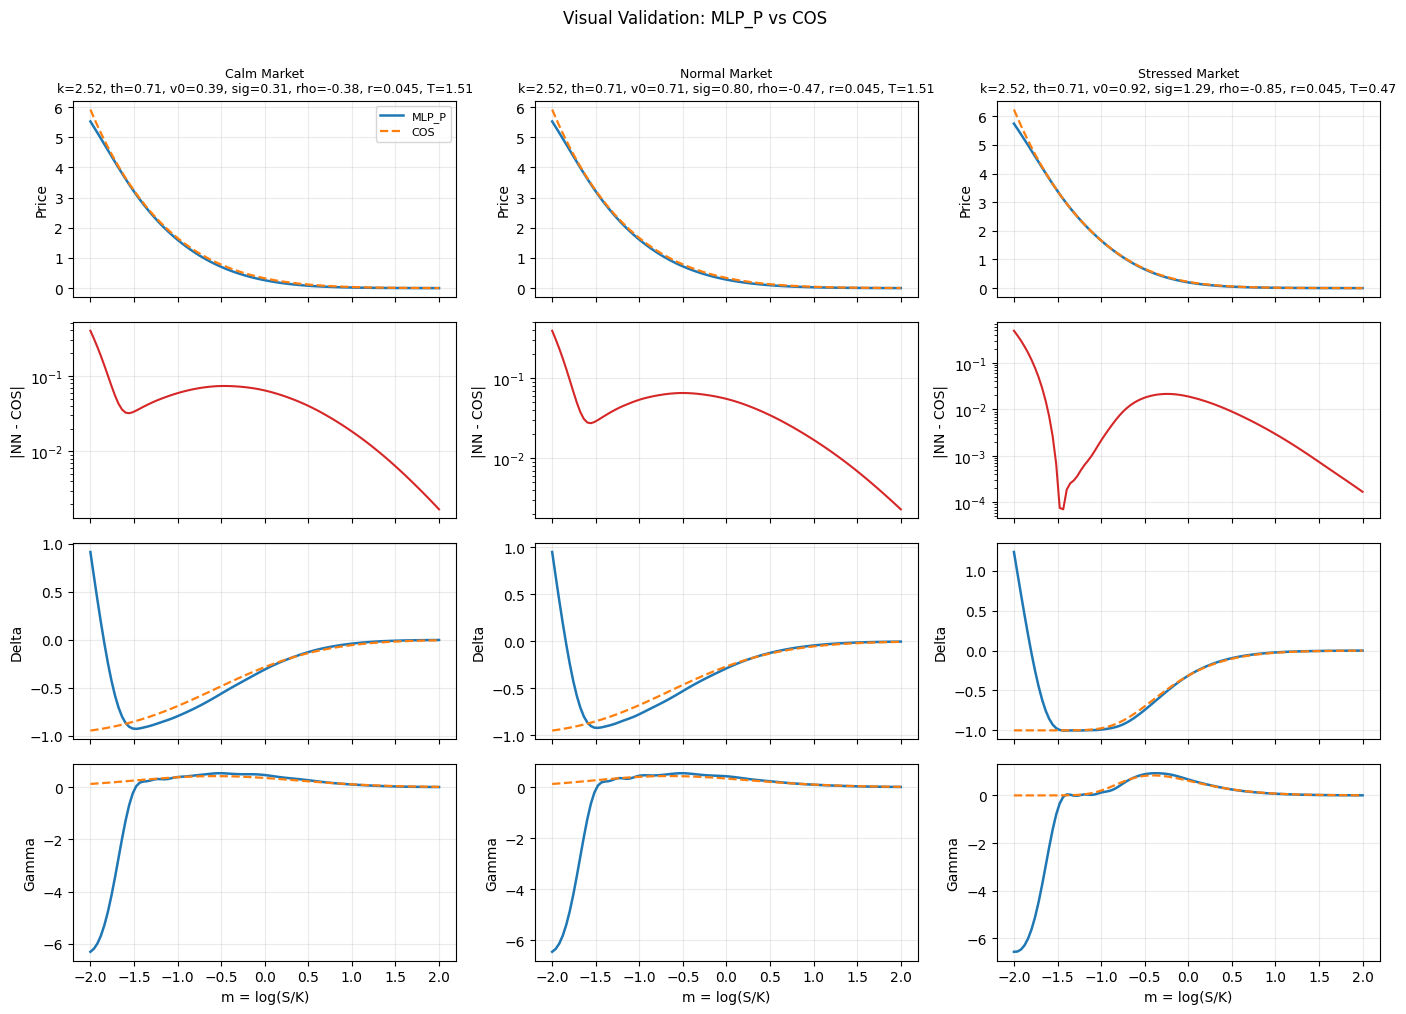

/Users/manswestman/Kandidatarbete/venv/lib/python3.13/site-packages/matplotlib/scale.py:270: RuntimeWarning: overflow encountered in power
  return np.power(self.base, values)
/Users/manswestman/Kandidatarbete/venv/lib/python3.13/site-packages/matplotlib/axes/_base.py:3070: RuntimeWarning: overflow encountered in scalar subtract
  x0, x1 = inverse_trans.transform([x0t - delta, x1t + delta])


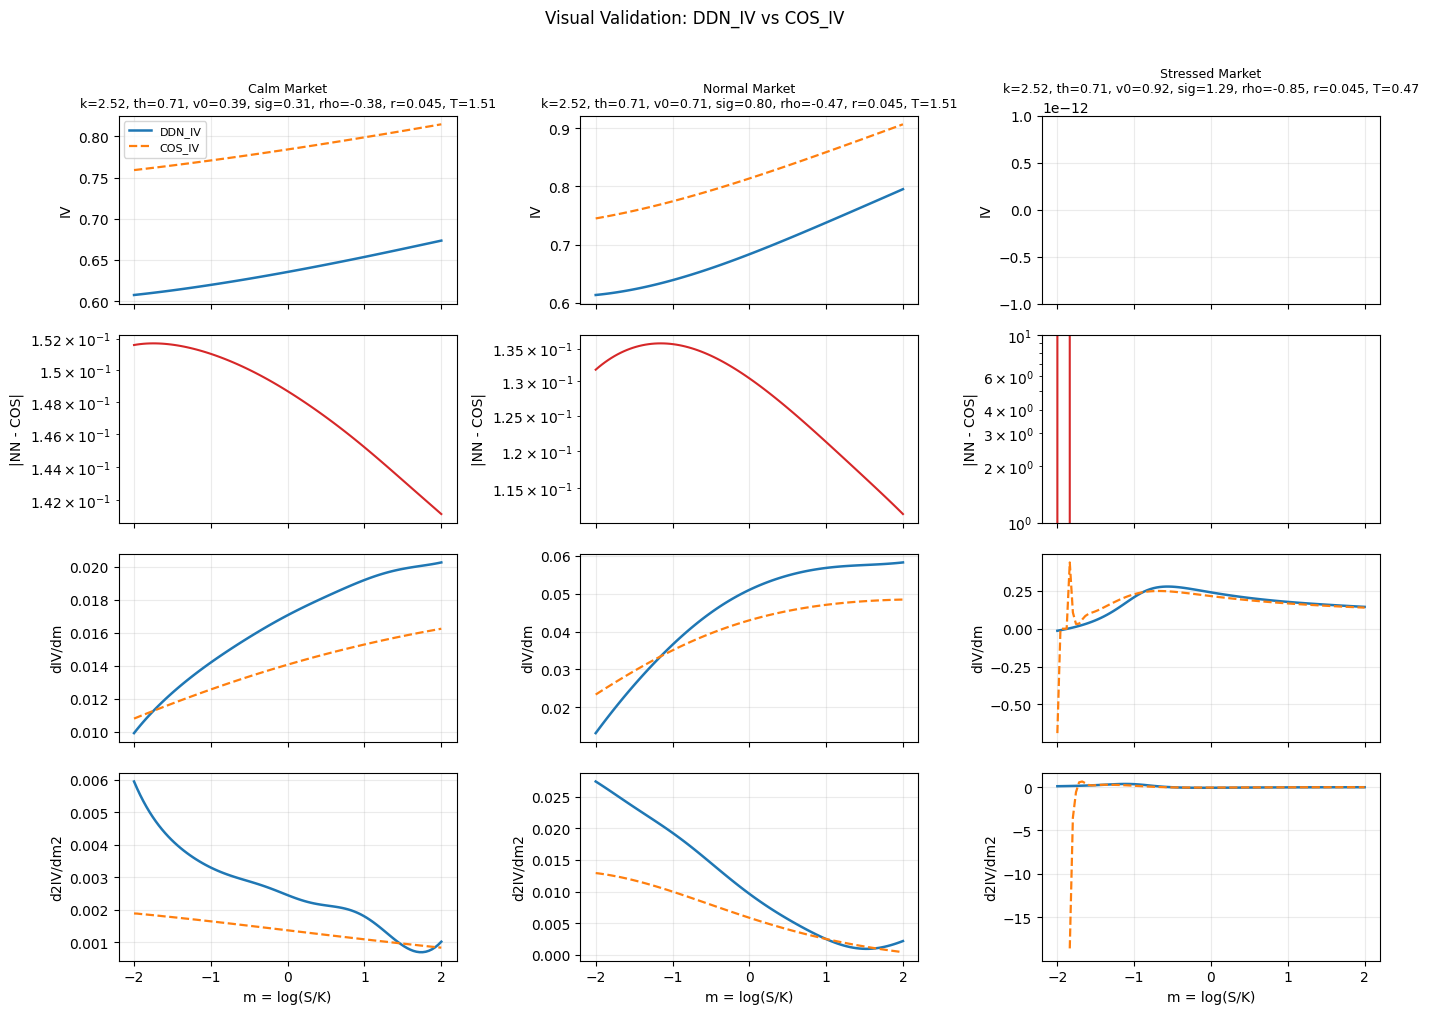

In [14]:
#=============================================================================

# 6.7) Visual Validation (4x3 Grid)

#=============================================================================



VISVAL_RUN = True

VISVAL_RUN_PDIVK = True

VISVAL_RUN_P = True

VISVAL_RUN_IV = True

VISVAL_RUN_MLP = True



VISVAL_N_COLS = 3

VISVAL_N_LM = 100

VISVAL_LM_MIN = -2.0

VISVAL_LM_MAX = 2.0

VISVAL_SEED = 20260411

VISVAL_FD_EPS = 1e-4





def _build_input_grid(base_row, lm_grid, feature_cols=None):

    if feature_cols is None:

        feature_cols = FEATURE_COLS

    grid = pd.DataFrame([base_row[feature_cols].to_dict()] * len(lm_grid))

    grid[LM_COL] = lm_grid

    return grid[feature_cols]





def _to_scaled_tensor(df_raw, feature_cols=None):

    if feature_cols is None:

        feature_cols = FEATURE_COLS

    scaled_df = scale_inputs(df_raw[feature_cols], zero_centered=True)

    return _feature_tensor(scaled_df, requires_grad=True, feature_cols=feature_cols)





def _finite_diff_curve_derivatives(curve_fn, x_grid, h):

    d1 = np.empty_like(x_grid, dtype=float)

    d2 = np.empty_like(x_grid, dtype=float)

    for i, x_i in enumerate(x_grid):

        y_p = float(curve_fn(x_i + h))

        y_m = float(curve_fn(x_i - h))

        y_0 = float(curve_fn(x_i))

        d1[i] = (y_p - y_m) / (2.0 * h)

        d2[i] = (y_p - 2.0 * y_0 + y_m) / (h ** 2)

    return d1, d2





def _cos_price_delta_gamma(base_row, lm_grid, q_val, fd_eps):

    params = jnp.array(

        [

            float(base_row['theta']),

            float(base_row['v0']),

            float(base_row['sigma']),

            float(base_row['rho']),

            float(base_row['kappa']),

        ],

        dtype=jnp.float64,

    )

    T_i = float(base_row['T'])

    r_i = float(base_row['r'])



    def _price_fn(lm_val):

        return price_jit(params, float(lm_val), T_i, r_i, q_val, int(N_COS), int(L_COS))



    price = np.array([float(_price_fn(lm)) for lm in lm_grid], dtype=float)

    dp_dm, d2p_dm2 = _finite_diff_curve_derivatives(_price_fn, lm_grid, float(fd_eps))



    # Same lm-chain convention used by get_delta_gamma_P/get_delta_gamma_PdivK.

    delta = price + dp_dm

    gamma = d2p_dm2 + dp_dm

    return price, delta, gamma, _price_fn





def _panel_title(base_row):

    return (

        f"k={base_row['kappa']:.2f}, th={base_row['theta']:.2f}, v0={base_row['v0']:.2f}, "

        f"sig={base_row['sigma']:.2f}, rho={base_row['rho']:.2f}, r={base_row['r']:.3f}, T={base_row['T']:.2f}"

    )





def _scenario_column_label(col_idx):

    labels = ['Calm Market', 'Normal Market', 'Stressed Market']

    if 0 <= int(col_idx) < len(labels):

        return labels[int(col_idx)]

    return f'State {int(col_idx) + 1}'





def _select_shared_base_rows():

    n_cols = int(VISVAL_N_COLS)

    if n_cols <= 0:

        return pd.DataFrame(columns=FEATURE_COLS)



    source_names = ['input_raw_DDN_P', 'input_raw_DDN_PdivK', 'input_raw_DDN_IV', 'input_raw_MLP_P']

    source_df = None

    for name in source_names:

        if name in globals() and isinstance(globals()[name], pd.DataFrame):

            cand = globals()[name]

            if all(col in cand.columns for col in FEATURE_COLS):

                source_df = cand[FEATURE_COLS].copy()

                break



    if source_df is None or len(source_df) == 0:

        return pd.DataFrame(columns=FEATURE_COLS)



    def _q(col, p):

        return float(np.nanquantile(source_df[col].to_numpy(dtype=float), p))



    def _clip_to_bounds(col, x):

        lo, hi = param_bounds[col]

        return float(np.clip(float(x), float(lo), float(hi)))



    med = source_df[FEATURE_COLS].median(numeric_only=True).to_dict()



    calm = dict(med)

    calm['v0'] = _q('v0', 0.15)

    calm['sigma'] = _q('sigma', 0.15)

    calm['T'] = _q('T', 0.50)

    calm['rho'] = _q('rho', 0.60)



    normal = dict(med)



    stressed = dict(med)

    stressed['v0'] = _q('v0', 0.85)

    stressed['sigma'] = _q('sigma', 0.85)

    stressed['rho'] = min(_q('rho', 0.10), -0.70)

    stressed['T'] = _q('T', 0.15)



    scenario_rows = pd.DataFrame([calm, normal, stressed], columns=FEATURE_COLS)

    for idx in scenario_rows.index:

        for col in FEATURE_COLS:

            if col == LM_COL:

                continue

            if col in param_bounds:

                scenario_rows.at[idx, col] = _clip_to_bounds(col, scenario_rows.at[idx, col])



    # Anchor at ATM; each panel then sweeps over lm via the shared lm-grid.

    scenario_rows[LM_COL] = 0.0



    scenario_rows = scenario_rows.iloc[:min(n_cols, len(scenario_rows))].reset_index(drop=True)

    return scenario_rows[FEATURE_COLS]





def _plot_put_model_vs_cos(model_label, model_obj, input_df_raw, nn_getter, base_rows=None, feature_cols=None):

    if feature_cols is None:

        feature_cols = FEATURE_COLS

    lm_min, lm_max = param_bounds[LM_COL]

    lm_grid = np.linspace(float(VISVAL_LM_MIN), float(VISVAL_LM_MAX), int(VISVAL_N_LM))

    if base_rows is None:

        n_cols = min(int(VISVAL_N_COLS), len(input_df_raw))

        if n_cols == 0:

            print(f'No rows for {model_label} visual validation.')

            return



        base_rows = input_df_raw.sample(n=n_cols, random_state=int(VISVAL_SEED)).reset_index(drop=True)

    else:

        base_rows = base_rows[feature_cols].copy().reset_index(drop=True)

        n_cols = len(base_rows)

        if n_cols == 0:

            print(f'No shared rows for {model_label} visual validation.')

            return

    q_val = float(globals().get('q_cos', 0.0))



    fig, axes = plt.subplots(4, n_cols, sharex='col', figsize=(14, 10))

    if n_cols == 1:

        axes = np.array(axes).reshape(4, 1)



    for col, row in enumerate(base_rows.itertuples(index=False)):

        base_row = pd.Series(row._asdict())

        raw_grid = _build_input_grid(base_row, lm_grid, feature_cols=feature_cols)

        x_scaled = _to_scaled_tensor(raw_grid, feature_cols=feature_cols)



        nn_price, nn_delta, nn_gamma = nn_getter(

            model_obj, x_scaled, raw_grid, lm_min, lm_max

        )



        cos_price, cos_delta, cos_gamma, _ = _cos_price_delta_gamma(

            base_row, lm_grid, q_val, VISVAL_FD_EPS

        )



        abs_err = np.maximum(np.abs(nn_price - cos_price), 1e-16)



        axes[0, col].plot(lm_grid, nn_price, label=model_label, linewidth=1.8)

        axes[0, col].plot(lm_grid, cos_price, '--', label='COS', linewidth=1.6)

        if base_rows is not None:

            title_prefix = _scenario_column_label(col)

            axes[0, col].set_title(f'{title_prefix}\n{_panel_title(base_row)}', fontsize=9)

        else:

            axes[0, col].set_title(_panel_title(base_row), fontsize=9)

        axes[0, col].set_ylabel('Price')



        axes[1, col].plot(lm_grid, abs_err, color='tab:red', linewidth=1.5)

        axes[1, col].set_yscale('log')

        axes[1, col].set_ylabel('|NN - COS|')



        axes[2, col].plot(lm_grid, nn_delta, label=model_label, linewidth=1.8)

        axes[2, col].plot(lm_grid, cos_delta, '--', label='COS', linewidth=1.6)

        axes[2, col].set_ylabel('Delta')



        axes[3, col].plot(lm_grid, nn_gamma, label=model_label, linewidth=1.8)

        axes[3, col].plot(lm_grid, cos_gamma, '--', label='COS', linewidth=1.6)

        axes[3, col].set_ylabel('Gamma')

        axes[3, col].set_xlabel('m = log(S/K)')



    for c in range(n_cols):

        for r in range(4):

            axes[r, c].grid(alpha=0.25)

    handles, _ = axes[0, 0].get_legend_handles_labels()

    if handles:

        axes[0, 0].legend(loc='best', fontsize=8)



    fig.suptitle(f'Visual Validation: {model_label} vs COS', y=1.01, fontsize=12)

    plt.tight_layout()

    plt.show()





def _nn_getter_pdivk(model_obj, x_scaled, raw_grid, lm_min, lm_max):

    return get_delta_gamma_PdivK(

        model=model_obj,

        x_scaled=x_scaled,

        lm_raw=raw_grid[LM_COL].values,

        lm_min=lm_min,

        lm_max=lm_max,

    )





def _nn_getter_p(model_obj, x_scaled, raw_grid, lm_min, lm_max):

    return get_delta_gamma_P(

        model=model_obj,

        x_scaled=x_scaled,

        lm_min=lm_min,

        lm_max=lm_max,

        pmin=pmin,

        pmax=pmax,

    )





def _nn_getter_mlp(model_obj, x_scaled, raw_grid, lm_min, lm_max):

    return get_delta_gamma_MLP(

        model=model_obj,

        x_scaled=x_scaled,

        lm_min=lm_min,

        lm_max=lm_max,

        ymin=ymin_MLP,

        ymax=ymax_MLP,

    )





def _cos_iv_from_price_curve(base_row, price_curve, lm_grid, q_val):

    if '_pricehat_to_iv_and_ivgreeks' not in globals():

        return None



    iv_curve = np.full(len(lm_grid), np.nan, dtype=float)

    dummy_greeks = np.zeros(5, dtype=float)

    T_i = float(base_row['T'])

    r_i = float(base_row['r'])

    for i, lm_i in enumerate(lm_grid):

        iv_i, _, _ = _pricehat_to_iv_and_ivgreeks(

            float(price_curve[i]),

            dummy_greeks,

            float(lm_i),

            T_i,

            r_i,

            q=float(q_val),

        )

        iv_curve[i] = float(iv_i)

    return iv_curve





def _plot_iv_model_vs_cosiv(model_obj, input_df_raw, base_rows=None):

    if '_pricehat_to_iv_and_ivgreeks' not in globals():

        print('Skipping DDN_IV visual check: missing _pricehat_to_iv_and_ivgreeks runtime helper.')

        return



    lm_min, lm_max = param_bounds[LM_COL]

    lm_grid = np.linspace(float(VISVAL_LM_MIN), float(VISVAL_LM_MAX), int(VISVAL_N_LM))

    if base_rows is None:

        n_cols = min(int(VISVAL_N_COLS), len(input_df_raw))

        if n_cols == 0:

            print('No rows for DDN_IV visual validation.')

            return



        base_rows = input_df_raw.sample(n=n_cols, random_state=int(VISVAL_SEED)).reset_index(drop=True)

    else:

        base_rows = base_rows[FEATURE_COLS].copy().reset_index(drop=True)

        n_cols = len(base_rows)

        if n_cols == 0:

            print('No shared rows for DDN_IV visual validation.')

            return

    q_val = float(globals().get('q_cos', 0.0))



    fig, axes = plt.subplots(4, n_cols, sharex='col', figsize=(14, 10))

    if n_cols == 1:

        axes = np.array(axes).reshape(4, 1)



    for col, row in enumerate(base_rows.itertuples(index=False)):

        base_row = pd.Series(row._asdict())

        raw_grid = _build_input_grid(base_row, lm_grid)

        x_scaled = _to_scaled_tensor(raw_grid)



        nn_iv, nn_div, nn_d2iv = get_iv_lm_derivatives(

            model=model_obj,

            x_scaled=x_scaled,

            lm_min=lm_min,

            lm_max=lm_max,

        )



        cos_price, _, _, price_fn = _cos_price_delta_gamma(base_row, lm_grid, q_val, VISVAL_FD_EPS)

        cos_iv = _cos_iv_from_price_curve(base_row, cos_price, lm_grid, q_val)

        if cos_iv is None:

            print('Skipping DDN_IV visual check: could not build COS IV curve.')

            return



        def _iv_fn(lm_val):

            p_val = float(price_fn(lm_val))

            iv_i, _, _ = _pricehat_to_iv_and_ivgreeks(

                p_val,

                np.zeros(5, dtype=float),

                float(lm_val),

                float(base_row['T']),

                float(base_row['r']),

                q=float(q_val),

            )

            return float(iv_i)



        cos_div, cos_d2iv = _finite_diff_curve_derivatives(_iv_fn, lm_grid, float(VISVAL_FD_EPS))



        abs_err = np.maximum(np.abs(nn_iv - cos_iv), 1e-16)



        axes[0, col].plot(lm_grid, nn_iv, label='DDN_IV', linewidth=1.8)

        axes[0, col].plot(lm_grid, cos_iv, '--', label='COS_IV', linewidth=1.6)

        if base_rows is not None:

            title_prefix = _scenario_column_label(col)

            axes[0, col].set_title(f'{title_prefix}\n{_panel_title(base_row)}', fontsize=9)

        else:

            axes[0, col].set_title(_panel_title(base_row), fontsize=9)

        axes[0, col].set_ylabel('IV')



        axes[1, col].plot(lm_grid, abs_err, color='tab:red', linewidth=1.5)

        axes[1, col].set_yscale('log')

        axes[1, col].set_ylabel('|NN - COS|')



        axes[2, col].plot(lm_grid, nn_div, label='DDN_IV', linewidth=1.8)

        axes[2, col].plot(lm_grid, cos_div, '--', label='COS_IV', linewidth=1.6)

        axes[2, col].set_ylabel('dIV/dm')



        axes[3, col].plot(lm_grid, nn_d2iv, label='DDN_IV', linewidth=1.8)

        axes[3, col].plot(lm_grid, cos_d2iv, '--', label='COS_IV', linewidth=1.6)

        axes[3, col].set_ylabel('d2IV/dm2')

        axes[3, col].set_xlabel('m = log(S/K)')



    for c in range(n_cols):

        for r in range(4):

            axes[r, c].grid(alpha=0.25)

    handles, _ = axes[0, 0].get_legend_handles_labels()

    if handles:

        axes[0, 0].legend(loc='best', fontsize=8)



    fig.suptitle('Visual Validation: DDN_IV vs COS_IV', y=1.01, fontsize=12)

    plt.tight_layout()

    plt.show()





def run_visual_validation_suite():

    needed = ['FEATURE_COLS', 'LM_COL', 'jnp', 'price_jit', 'N_COS', 'L_COS', 'param_bounds', 'scale_inputs']

    missing = [k for k in needed if k not in globals()]

    if missing:

        print(f'Missing prerequisites for visual validation: {missing}')

        return



    shared_base_rows = _select_shared_base_rows()



    if VISVAL_RUN_PDIVK:

        if 'model_PdivK' in globals() and 'input_raw_DDN_PdivK' in globals():

            _plot_put_model_vs_cos('DDN_PdivK', model_PdivK, input_raw_DDN_PdivK, _nn_getter_pdivk, base_rows=shared_base_rows)

        else:

            print('Skipping DDN_PdivK visual check: missing model/input objects.')



    if VISVAL_RUN_P:

        if 'model_P' in globals() and 'input_raw_DDN_P' in globals() and 'pmin' in globals() and 'pmax' in globals():

            _plot_put_model_vs_cos('DDN_P', model_P, input_raw_DDN_P, _nn_getter_p, base_rows=shared_base_rows)

        else:

            print('Skipping DDN_P visual check: missing model/input objects or pmin/pmax.')



    if VISVAL_RUN_MLP:

        if (

            'model_MLP' in globals()

            and 'input_raw_MLP_P' in globals()

            and 'ymin_MLP' in globals()

            and 'ymax_MLP' in globals()

        ):

            _plot_put_model_vs_cos(

                'MLP_P',

                model_MLP,

                input_raw_MLP_P,

                _nn_getter_mlp,

                base_rows=shared_base_rows,

                feature_cols=FEATURE_COLS_MLP,

            )

        else:

            print('Skipping MLP_P visual check: missing model/input objects or ymin/ymax.')



    if VISVAL_RUN_IV:

        if 'model_IV' in globals() and 'input_raw_DDN_IV' in globals():

            _plot_iv_model_vs_cosiv(model_IV, input_raw_DDN_IV, base_rows=shared_base_rows)

        else:

            print('Skipping DDN_IV visual check: missing model/input objects.')





if VISVAL_RUN:

    run_visual_validation_suite()

In [15]:
#=============================================================================
# 6.8) Empirical Lipschitz Continuity Check (Put / IV vs lm)
#=============================================================================

LIPSCHITZ_EMPIRICAL_RUN = True
LIPSCHITZ_PAIRWISE_RUN = True
LIPSCHITZ_PAIRWISE_INPUT_SPACE = "scaled"  # "scaled" or "raw"
LIPSCHITZ_PAIRWISE_NORM = "l2"  # "l2" or "linf"
LIPSCHITZ_PAIRWISE_N_PAIRS = 20000
LIPSCHITZ_PAIRWISE_SEED = 20260411

# Optional baseline comparison against COS Greeks.
LIPSCHITZ_COS_BASELINE_RUN = True
LIPSCHITZ_COS_BASELINE_SHOW_TABLE = True
LIPSCHITZ_COS_PRICE_GREEKS = ['theta', 'v0', 'sigma', 'rho', 'kappa']
LIPSCHITZ_COS_IV_GREEKS = ['theta', 'v0', 'sigma', 'rho', 'kappa']


def _print_put_delta_bounds(model_label, delta_vals):
    delta_vals = np.asarray(delta_vals, dtype=float)
    finite_mask = np.isfinite(delta_vals)
    total_n = len(delta_vals)
    finite_n = int(np.sum(finite_mask))
    if finite_n == 0:
        print(f'[{model_label}] No finite Delta values.')
        return None

    delta_f = delta_vals[finite_mask]
    violation_mask = (delta_f < -1.0) | (delta_f > 0.0)
    violation_pct = 100.0 * float(np.mean(violation_mask))

    print(f'[{model_label}] Put Delta bounds check on test set (theory: Delta in [-1, 0])')
    print(f'Finite samples         : {finite_n}/{total_n}')
    print(f'Delta min              : {np.min(delta_f): .6e}')
    print(f'Delta max              : {np.max(delta_f): .6e}')
    print(f'Violation count        : {int(np.sum(violation_mask))}')
    print(f'Violation percentage   : {violation_pct:.4f}%')

    return {
        'delta_min': float(np.min(delta_f)),
        'delta_max': float(np.max(delta_f)),
        'delta_violation_pct': float(violation_pct),
    }


def _pairwise_lipschitz_stats(y, X, n_pairs=20000, seed=0, norm="l2"):
    y = np.asarray(y, dtype=float).flatten()
    X = np.asarray(X, dtype=float)
    n = min(len(y), len(X))
    if n < 2:
        return None

    y = y[:n]
    X = X[:n]
    rng = np.random.default_rng(int(seed))
    idx1 = rng.integers(0, n, size=int(n_pairs))
    idx2 = rng.integers(0, n, size=int(n_pairs))
    keep = idx1 != idx2
    idx1 = idx1[keep]
    idx2 = idx2[keep]
    if len(idx1) == 0:
        return None

    dy = np.abs(y[idx1] - y[idx2])
    dX = X[idx1] - X[idx2]
    if norm == "linf":
        dist = np.max(np.abs(dX), axis=1)
    else:
        dist = np.linalg.norm(dX, axis=1)

    finite = np.isfinite(dy) & np.isfinite(dist) & (dist > 0)
    if not np.any(finite):
        return None

    slopes = dy[finite] / dist[finite]
    return {
        'n_points': int(n),
        'n_pairs': int(len(slopes)),
        'L_max': float(np.max(slopes)),
        'L_p99': float(np.quantile(slopes, 0.99)),
        'L_p95': float(np.quantile(slopes, 0.95)),
        'L_median': float(np.median(slopes)),
    }


def _feature_frame(df_name, n_rows=None, feature_cols=None):
    if df_name not in globals():
        return None
    if feature_cols is None:
        feature_cols = FEATURE_COLS
    frame = globals()[df_name][feature_cols]
    if n_rows is not None:
        frame = frame.iloc[:int(n_rows)]
    return frame


def _scaled_tensor_from_sources(test_df_name=None, raw_df_name=None, n_rows=None, need_raw_lm=False, feature_cols=None):
    if feature_cols is None:
        feature_cols = FEATURE_COLS
    test_frame = _feature_frame(test_df_name, n_rows=n_rows, feature_cols=feature_cols) if test_df_name else None
    if test_frame is not None:
        x_scaled = _feature_tensor(test_frame, requires_grad=True, feature_cols=feature_cols)
        lm_raw = None
        if need_raw_lm and raw_df_name in globals():
            lm_raw = globals()[raw_df_name].iloc[:len(test_frame)][LM_COL].values
        return x_scaled, lm_raw

    raw_frame = _feature_frame(raw_df_name, n_rows=n_rows, feature_cols=feature_cols) if raw_df_name else None
    if raw_frame is not None and 'scale_inputs' in globals():
        if '_to_scaled_tensor' in globals():
            x_scaled = _to_scaled_tensor(raw_frame, feature_cols=feature_cols)
        else:
            scaled_df = scale_inputs(raw_frame, zero_centered=True)
            x_scaled = _feature_tensor(scaled_df, requires_grad=True, feature_cols=feature_cols)
        lm_raw = raw_frame[LM_COL].values if need_raw_lm else None
        return x_scaled, lm_raw

    return None, None


def _raw_inputs_for_model(model_name, n_rows):
    source_by_model = {
        'DDN_PdivK': 'input_raw_DDN_PdivK',
        'DDN_P': 'input_raw_DDN_P',
        'DDN_IV': 'input_raw_DDN_IV',
        'MLP_P': 'input_raw_MLP_P',
    }
    src_name = source_by_model.get(model_name)
    if src_name in globals():
        feature_cols = FEATURE_COLS
        if model_name == 'MLP_P' and 'FEATURE_COLS_MLP' in globals():
            feature_cols = FEATURE_COLS_MLP
        return globals()[src_name][feature_cols].iloc[:n_rows].values
    return None


def _pairwise_input_matrix(model_name, x_scaled, n_rows):
    if LIPSCHITZ_PAIRWISE_INPUT_SPACE == 'scaled':
        return x_scaled.detach().cpu().numpy()
    return _raw_inputs_for_model(model_name, n_rows)


def _shared_pairwise_inputs(kind, n_rows):
    if kind == 'price':
        scaled_name = 'input_df_DDN_P'
        raw_name = 'input_raw_DDN_P'
    else:
        scaled_name = 'input_df_DDN_IV'
        raw_name = 'input_raw_DDN_IV'

    if LIPSCHITZ_PAIRWISE_INPUT_SPACE == 'scaled':
        frame = _feature_frame(scaled_name, n_rows=n_rows)
    else:
        frame = _feature_frame(raw_name, n_rows=n_rows)

    return None if frame is None else frame.values


def _append_greek_pairwise_rows(rows, model_label, model_df, greek_names, col_prefix, X):
    if model_df is None or X is None:
        return

    for g in greek_names:
        col = f'{col_prefix}{g}'
        if col not in model_df.columns:
            continue

        y = np.asarray(model_df[col].values, dtype=float)
        stats = _pairwise_lipschitz_stats(
            y,
            X,
            n_pairs=LIPSCHITZ_PAIRWISE_N_PAIRS,
            seed=LIPSCHITZ_PAIRWISE_SEED,
            norm=LIPSCHITZ_PAIRWISE_NORM,
        )
        if stats is None:
            continue

        rows.append(
            {
                'target': col,
                'model': model_label,
                **stats,
            }
        )


def _display_lipschitz_table(df_table, title):
    print(title)
    if df_table.empty:
        print('No rows available.')
        return

    show_cols = ['target', 'model', 'L_max', 'L_p99', 'L_p95', 'L_median', 'n_points', 'n_pairs']
    try:
        display(df_table[show_cols])
    except NameError:
        print(df_table[show_cols].to_string(index=False))


def _safe_ratio(num, den):
    if den is None or not np.isfinite(den) or abs(float(den)) < 1e-15:
        return np.nan
    if num is None or not np.isfinite(num):
        return np.nan
    return float(num) / float(den)


def _ratio_vs_cos_table(df_table):
    if df_table.empty or 'model' not in df_table.columns:
        return pd.DataFrame()

    has_cos = np.any(df_table['model'].values == 'COS')
    if not has_cos:
        return pd.DataFrame()

    ratio_rows = []
    for target, grp in df_table.groupby('target', sort=True):
        cos_rows = grp[grp['model'] == 'COS']
        if cos_rows.empty:
            continue
        cos_row = cos_rows.iloc[0]

        for _, row in grp[grp['model'] != 'COS'].iterrows():
            ratio_rows.append(
                {
                    'target': target,
                    'model': row['model'],
                    'L_p99_ratio_vs_COS': _safe_ratio(row['L_p99'], cos_row['L_p99']),
                    'L_median_ratio_vs_COS': _safe_ratio(row['L_median'], cos_row['L_median']),
                }
            )

    if not ratio_rows:
        return pd.DataFrame()

    return pd.DataFrame(ratio_rows).sort_values(['target', 'model']).reset_index(drop=True)


def _display_ratio_table(df_table, title):
    print(title)
    if df_table.empty:
        print('No rows available.')
        return

    show_cols = ['target', 'model', 'L_p99_ratio_vs_COS', 'L_median_ratio_vs_COS']
    try:
        display(df_table[show_cols])
    except NameError:
        print(df_table[show_cols].to_string(index=False))


def _run_cos_baseline_pairwise():
    baseline_out = {}

    if 'df_COS' not in globals():
        print('[COS baseline] df_COS is not available; skipping COS comparison.')
        return baseline_out

    # Price Greeks: compare COS against DDN price models.
    rows_price = []
    X_price = _shared_pairwise_inputs('price', len(df_COS))
    if X_price is None:
        print('[COS baseline][Price Greeks] Missing shared input features; skipping.')
    else:
        _append_greek_pairwise_rows(rows_price, 'COS', df_COS, LIPSCHITZ_COS_PRICE_GREEKS, 'd', X_price)
        if 'df_DDN_P' in globals():
            _append_greek_pairwise_rows(rows_price, 'DDN_P', df_DDN_P, LIPSCHITZ_COS_PRICE_GREEKS, 'd', X_price)
        if 'df_DDN_PdivK' in globals():
            _append_greek_pairwise_rows(rows_price, 'DDN_PdivK', df_DDN_PdivK, LIPSCHITZ_COS_PRICE_GREEKS, 'd', X_price)
        if 'df_MLP_P' in globals():
            _append_greek_pairwise_rows(rows_price, 'MLP_P', df_MLP_P, LIPSCHITZ_COS_PRICE_GREEKS, 'd', X_price)

    if rows_price:
        price_df = pd.DataFrame(rows_price).sort_values(['target', 'model']).reset_index(drop=True)
        ratio_price_df = _ratio_vs_cos_table(price_df)
        if LIPSCHITZ_COS_BASELINE_SHOW_TABLE:
            _display_lipschitz_table(price_df, '[COS baseline] Pairwise Lipschitz on price Greeks')
            _display_ratio_table(ratio_price_df, '[COS baseline] DDN/COS ratios on price Greeks (L_p99, L_median)')
        baseline_out['price_greeks'] = rows_price
        baseline_out['price_greeks_ratio_vs_COS'] = ratio_price_df.to_dict('records')
    else:
        print('[COS baseline][Price Greeks] No comparable columns found.')

    # IV Greeks: compare COS against DDN_IV.
    rows_iv = []
    X_iv = _shared_pairwise_inputs('iv', len(df_COS))
    if X_iv is None:
        print('[COS baseline][IV Greeks] Missing shared input features; skipping.')
    else:
        _append_greek_pairwise_rows(rows_iv, 'COS', df_COS, LIPSCHITZ_COS_IV_GREEKS, 'IVd', X_iv)
        if 'df_DDN_IV' in globals():
            _append_greek_pairwise_rows(rows_iv, 'DDN_IV', df_DDN_IV, LIPSCHITZ_COS_IV_GREEKS, 'IVd', X_iv)

    if rows_iv:
        iv_df = pd.DataFrame(rows_iv).sort_values(['target', 'model']).reset_index(drop=True)
        ratio_iv_df = _ratio_vs_cos_table(iv_df)
        if LIPSCHITZ_COS_BASELINE_SHOW_TABLE:
            _display_lipschitz_table(iv_df, '[COS baseline] Pairwise Lipschitz on IV Greeks')
            _display_ratio_table(ratio_iv_df, '[COS baseline] DDN/COS ratios on IV Greeks (L_p99, L_median)')
        baseline_out['iv_greeks'] = rows_iv
        baseline_out['iv_greeks_ratio_vs_COS'] = ratio_iv_df.to_dict('records')
    else:
        print('[COS baseline][IV Greeks] No comparable columns found.')

    return baseline_out


def _print_pairwise_stats(label, stats):
    if stats is None:
        print(f'[{label}] Pairwise Lipschitz stats unavailable.')
        return
    print(f'[{label}] Pairwise empirical Lipschitz ({LIPSCHITZ_PAIRWISE_INPUT_SPACE}, {LIPSCHITZ_PAIRWISE_NORM})')
    print(f"n points               : {stats['n_points']}")
    print(f"n sampled pairs        : {stats['n_pairs']}")
    print(f"L_max                  : {stats['L_max']: .6e}")
    print(f"L_p99                  : {stats['L_p99']: .6e}")
    print(f"L_p95                  : {stats['L_p95']: .6e}")
    print(f"L_median               : {stats['L_median']: .6e}")


def _attach_pairwise(out_dict, key, stats):
    base = out_dict.get(key)
    if base is None or not isinstance(base, dict):
        base = {}
    base['pairwise_lipschitz'] = stats
    out_dict[key] = base


def empirical_lipschitz_check_put_and_iv():
    required = ['FEATURE_COLS', 'LM_COL', 'model_P', 'model_PdivK', 'model_IV', 'param_bounds']
    missing = [k for k in required if k not in globals()]
    if missing:
        print(f'Missing prerequisites: {missing}')
        return None

    lm_min, lm_max = param_bounds[LM_COL]
    lm_scale = 2.0 / (float(lm_max) - float(lm_min))

    print('=' * 100)
    print('Empirical Lipschitz / Slope diagnostics (w.r.t lm)')
    print('=' * 100)

    out = {}

    # ----- DDN_PdivK put Delta bounds -----
    n_pk = None
    if 'df_test_DDN_PdivK' in globals() and 'input_raw_DDN_PdivK' in globals():
        n_pk = min(len(df_test_DDN_PdivK), len(input_raw_DDN_PdivK))
    x_pk_scaled, lm_raw_pk = _scaled_tensor_from_sources(
        test_df_name='df_test_DDN_PdivK',
        raw_df_name='input_raw_DDN_PdivK',
        n_rows=n_pk,
        need_raw_lm=True,
    )
    if x_pk_scaled is None or lm_raw_pk is None:
        print('[DDN_PdivK] Missing test inputs.')
    else:
        _, delta_pk, _ = get_delta_gamma_PdivK(
            model=model_PdivK,
            x_scaled=x_pk_scaled,
            lm_raw=lm_raw_pk,
            lm_min=lm_min,
            lm_max=lm_max,
        )
        out['DDN_PdivK'] = _print_put_delta_bounds('DDN_PdivK', delta_pk)

        if LIPSCHITZ_PAIRWISE_RUN:
            X_pk = _pairwise_input_matrix('DDN_PdivK', x_pk_scaled, len(delta_pk))
            stats_pk = _pairwise_lipschitz_stats(
                delta_pk,
                X_pk,
                n_pairs=LIPSCHITZ_PAIRWISE_N_PAIRS,
                seed=LIPSCHITZ_PAIRWISE_SEED,
                norm=LIPSCHITZ_PAIRWISE_NORM,
            )
            _print_pairwise_stats('DDN_PdivK Delta', stats_pk)
            _attach_pairwise(out, 'DDN_PdivK', stats_pk)

    print('-' * 100)

    # ----- DDN_P put Delta bounds -----
    x_p_scaled, _ = _scaled_tensor_from_sources(
        test_df_name='df_test_DDN_P',
        raw_df_name='input_raw_DDN_P',
    )
    if x_p_scaled is None:
        print('[DDN_P] Missing test inputs.')
    else:
        _, delta_p, _ = get_delta_gamma_P(
            model=model_P,
            x_scaled=x_p_scaled,
            lm_min=lm_min,
            lm_max=lm_max,
            pmin=pmin,
            pmax=pmax,
        )
        out['DDN_P'] = _print_put_delta_bounds('DDN_P', delta_p)

        if LIPSCHITZ_PAIRWISE_RUN:
            X_p = _pairwise_input_matrix('DDN_P', x_p_scaled, len(delta_p))
            stats_p = _pairwise_lipschitz_stats(
                delta_p,
                X_p,
                n_pairs=LIPSCHITZ_PAIRWISE_N_PAIRS,
                seed=LIPSCHITZ_PAIRWISE_SEED,
                norm=LIPSCHITZ_PAIRWISE_NORM,
            )
            _print_pairwise_stats('DDN_P Delta', stats_p)
            _attach_pairwise(out, 'DDN_P', stats_p)

    print('-' * 100)

    # ----- MLP_P put Delta bounds -----
    if 'model_MLP' not in globals() or 'ymin_MLP' not in globals() or 'ymax_MLP' not in globals():
        print('[MLP_P] Missing model or scaling bounds.')
    else:
        x_mlp_scaled, _ = _scaled_tensor_from_sources(
            test_df_name='df_test_MLP_P',
            raw_df_name='input_raw_MLP_P',
            feature_cols=FEATURE_COLS_MLP,
        )
        if x_mlp_scaled is None:
            print('[MLP_P] Missing test inputs.')
        else:
            _, delta_mlp, _ = get_delta_gamma_MLP(
                model=model_MLP,
                x_scaled=x_mlp_scaled,
                lm_min=lm_min,
                lm_max=lm_max,
                ymin=ymin_MLP,
                ymax=ymax_MLP,
            )
            out['MLP_P'] = _print_put_delta_bounds('MLP_P', delta_mlp)

            if LIPSCHITZ_PAIRWISE_RUN:
                X_mlp = _pairwise_input_matrix('MLP_P', x_mlp_scaled, len(delta_mlp))
                stats_mlp = _pairwise_lipschitz_stats(
                    delta_mlp,
                    X_mlp,
                    n_pairs=LIPSCHITZ_PAIRWISE_N_PAIRS,
                    seed=LIPSCHITZ_PAIRWISE_SEED,
                    norm=LIPSCHITZ_PAIRWISE_NORM,
                )
                _print_pairwise_stats('MLP_P Delta', stats_mlp)
                _attach_pairwise(out, 'MLP_P', stats_mlp)

    print('-' * 100)

    # ----- DDN_IV empirical Lipschitz: max |dIV/dlm| -----
    x_iv_scaled, _ = _scaled_tensor_from_sources(
        test_df_name='df_test_DDN_IV',
        raw_df_name='input_raw_DDN_IV',
    )
    if x_iv_scaled is None:
        print('[DDN_IV] Missing test inputs.')
    else:
        iv_pred = model_IV(x_iv_scaled)
        if iv_pred.ndim > 1:
            iv_pred = iv_pred.squeeze(-1)

        grads_iv = torch.autograd.grad(
            iv_pred,
            x_iv_scaled,
            grad_outputs=torch.ones_like(iv_pred),
            create_graph=False,
            retain_graph=False,
        )[0]

        div_dlm = grads_iv[:, LM_IDX] * lm_scale
        div_dlm_np = div_dlm.detach().cpu().numpy().astype(float)
        finite_iv = np.isfinite(div_dlm_np)

        if np.any(finite_iv):
            div_f = div_dlm_np[finite_iv]
            L_iv_empirical = float(np.max(np.abs(div_f)))
            print('[DDN_IV] IV Lipschitz diagnostic on test set (w.r.t lm)')
            print(f'Finite samples         : {int(np.sum(finite_iv))}/{len(div_dlm_np)}')
            print(f'max |dIV/dlm|          : {L_iv_empirical: .6e}')
            print(f'median |dIV/dlm|       : {np.median(np.abs(div_f)): .6e}')
            print(f'p99 |dIV/dlm|          : {np.quantile(np.abs(div_f), 0.99): .6e}')
            out['DDN_IV'] = {
                'iv_lipschitz_max_abs': L_iv_empirical,
                'iv_dlm_median_abs': float(np.median(np.abs(div_f))),
                'iv_dlm_p99_abs': float(np.quantile(np.abs(div_f), 0.99)),
            }

            if LIPSCHITZ_PAIRWISE_RUN:
                X_iv = _pairwise_input_matrix('DDN_IV', x_iv_scaled, len(div_dlm_np))
                stats_iv = _pairwise_lipschitz_stats(
                    div_dlm_np,
                    X_iv,
                    n_pairs=LIPSCHITZ_PAIRWISE_N_PAIRS,
                    seed=LIPSCHITZ_PAIRWISE_SEED,
                    norm=LIPSCHITZ_PAIRWISE_NORM,
                )
                _print_pairwise_stats('DDN_IV dIV/dlm', stats_iv)
                _attach_pairwise(out, 'DDN_IV', stats_iv)
        else:
            print('[DDN_IV] No finite dIV/dlm values.')
            out['DDN_IV'] = None

    if LIPSCHITZ_COS_BASELINE_RUN:
        print('-' * 100)
        out['COS_baseline_pairwise'] = _run_cos_baseline_pairwise()

    return out


if LIPSCHITZ_EMPIRICAL_RUN:
    empirical_lipschitz_summary = empirical_lipschitz_check_put_and_iv()

Empirical Lipschitz / Slope diagnostics (w.r.t lm)
[DDN_PdivK] Put Delta bounds check on test set (theory: Delta in [-1, 0])
Finite samples         : 4989/4989
Delta min              : -1.005983e+00
Delta max              : -1.070428e-09
Violation count        : 108
Violation percentage   : 2.1648%
[DDN_PdivK Delta] Pairwise empirical Lipschitz (scaled, l2)
n points               : 4989
n sampled pairs        : 19994
L_max                  :  9.522407e-01
L_p99                  :  5.098659e-01
L_p95                  :  4.153227e-01
L_median               :  1.567103e-01
----------------------------------------------------------------------------------------------------
[DDN_P] Put Delta bounds check on test set (theory: Delta in [-1, 0])
Finite samples         : 4989/4989
Delta min              : -1.012156e+00
Delta max              : -3.658996e-09
Violation count        : 97
Violation percentage   : 1.9443%
[DDN_P Delta] Pairwise empirical Lipschitz (scaled, l2)
n points              

,target,model,L_max,L_p99,L_p95,L_median,n_points,n_pairs
0,dkappa,COS,6.396,0.1116,4.090e-02,4.090e-03,4989,19994
1,dkappa,DDN_P,0.3867,8.501e-02,3.603e-02,4.004e-03,4989,19994
2,dkappa,DDN_PdivK,0.3839,8.487e-02,3.592e-02,3.994e-03,4989,19994
3,dkappa,MLP_P,0.3779,8.490e-02,3.616e-02,4.010e-03,4989,19994
4,drho,COS,0.2831,7.863e-02,4.842e-02,8.723e-03,4989,19994
5,drho,DDN_P,0.2834,7.872e-02,4.837e-02,8.735e-03,4989,19994
6,drho,DDN_PdivK,0.2828,7.889e-02,4.858e-02,8.729e-03,4989,19994
7,drho,MLP_P,0.286,7.785e-02,4.823e-02,8.767e-03,4989,19994
8,dsigma,COS,0.2518,6.003e-02,3.547e-02,6.185e-03,4989,19994
9,dsigma,DDN_P,0.2237,5.785e-02,3.494e-02,6.095e-03,4989,19994


[COS baseline] DDN/COS ratios on price Greeks (L_p99, L_median)


,target,model,L_p99_ratio_vs_COS,L_median_ratio_vs_COS
0,dkappa,DDN_P,0.7619,0.9789
1,dkappa,DDN_PdivK,0.7607,0.9765
2,dkappa,MLP_P,0.761,0.9804
3,drho,DDN_P,1.001,1.001
4,drho,DDN_PdivK,1.003,1.001
5,drho,MLP_P,0.99,1.005
6,dsigma,DDN_P,0.9636,0.9855
7,dsigma,DDN_PdivK,0.9635,0.9819
8,dsigma,MLP_P,0.9644,0.9828
9,dtheta,DDN_P,0.9897,0.9962


[COS baseline] Pairwise Lipschitz on IV Greeks


,target,model,L_max,L_p99,L_p95,L_median,n_points,n_pairs
0,IVdkappa,COS,833.3,0.413,0.1097,1.777e-02,4989,19471
1,IVdkappa,DDN_IV,0.5715,0.1708,9.585e-02,1.710e-02,4989,19994
2,IVdrho,COS,19.43,0.4025,0.1966,4.888e-02,4989,19471
3,IVdrho,DDN_IV,0.9109,0.3589,0.2087,5.026e-02,4989,19994
4,IVdsigma,COS,92.39,0.2943,0.1231,3.277e-02,4989,19471
5,IVdsigma,DDN_IV,0.6889,0.1657,0.1127,3.253e-02,4989,19994
6,IVdtheta,COS,145.9,0.7153,0.3773,0.1132,4989,19471
7,IVdtheta,DDN_IV,2.17,0.5426,0.3551,0.1126,4989,19994
8,IVdv0,COS,143.1,0.6112,0.292,7.840e-02,4989,19471
9,IVdv0,DDN_IV,1.557,0.4299,0.2706,7.800e-02,4989,19994


[COS baseline] DDN/COS ratios on IV Greeks (L_p99, L_median)


,target,model,L_p99_ratio_vs_COS,L_median_ratio_vs_COS
0,IVdkappa,DDN_IV,0.4136,0.9622
1,IVdrho,DDN_IV,0.8918,1.028
2,IVdsigma,DDN_IV,0.563,0.9927
3,IVdtheta,DDN_IV,0.7586,0.9948
4,IVdv0,DDN_IV,0.7034,0.9948


## 7) Arbitrage Diagnostics
Final consistency checks reported in two lenses:
1. Price-space arbitrage diagnostics
2. IV-space and IV-implied-price arbitrage diagnostics

This phase has two parts:
- Dataset-based sanity checks on observed predictions.
- Dense-grid sweeps on synthetic surface grids for stronger structural evidence.

Outputs support cross-model and model-vs-COS comparison.

In [16]:
#=============================================================================
# Shared arbitrage helpers (used by Cells 20-21)e
#=============================================================================

def _pct(n, d):
    """Helper for percentage formatting with NaN handling."""
    if d <= 0:
        return np.nan
    return 100.0 * float(n) / float(d)


def _rate_str(n, d):
    """Helper for rate string formatting with NaN handling."""
    if d <= 0:
        return "NaN"
    return f"{100.0 * float(n) / float(d):.2f}%"


def _build_surface_ids(df_ref, candidate_keys=None, round_decimals=10):
    """
    Build surface IDs for grouping comparable contracts.
    A valid static-arbitrage comparison should hold model state fixed and vary strike/maturity.
    """
    if candidate_keys is None:
        candidate_keys = ["kappa", "theta", "v0", "rho", "sigma", "r"]

    keys = [k for k in candidate_keys if k in df_ref.columns]
    if not keys:
        return pd.Series(np.zeros(len(df_ref), dtype=np.int64), index=df_ref.index), []

    key_df = df_ref[keys].astype(float).round(round_decimals)
    surface_ids = pd.util.hash_pandas_object(key_df, index=False).astype(np.int64)
    return surface_ids, keys


def put_bounds_absolute_from_lm(lm, tau, r, q=0.0, s0=1.0):
    """
    Absolute put bounds for spot-normalized setup where S0=s0 and K=s0*exp(-lm).
    lower = max(K*exp(-r*tau) - S0*exp(-q*tau), 0)
    upper = K*exp(-r*tau)
    """
    lm = np.asarray(lm, dtype=float).flatten()
    tau = np.clip(np.asarray(tau, dtype=float).flatten(), 1e-12, None)
    r = np.asarray(r, dtype=float).flatten()

    n = min(len(lm), len(tau), len(r))
    if n == 0:
        return np.array([]), np.array([]), np.array([])

    lm = lm[:n]
    tau = tau[:n]
    r = r[:n]

    K = float(s0) * np.exp(-lm)
    lower = np.maximum(K * np.exp(-r * tau) - float(s0) * np.exp(-q * tau), 0.0)
    upper = K * np.exp(-r * tau)
    return lower, upper, K


def count_put_bound_breaches_absolute(price_abs, lm, tau, r, q=0.0, tol=1e-12, s0=1.0):
    """Count breaches of absolute put price bounds for spot-normalized setup.
    Returns dict with breach counts and indices of breaches."""
    p = np.asarray(price_abs, dtype=float).flatten()
    lm = np.asarray(lm, dtype=float).flatten()
    tau = np.asarray(tau, dtype=float).flatten()
    r = np.asarray(r, dtype=float).flatten()

    n = min(len(p), len(lm), len(tau), len(r))
    if n == 0:
        return {
            "n_total": 0,
            "n_valid_for_bounds": 0,
            "n_nan_or_inf_price": 0,
            "n_lower_breach": 0,
            "n_upper_breach": 0,
            "n_breach_total": 0,
            "breach_indices": np.array([], dtype=int),
        }

    p = p[:n]
    lm = lm[:n]
    tau = tau[:n]
    r = r[:n]

    lower, upper, _ = put_bounds_absolute_from_lm(lm, tau, r, q=q, s0=s0)
    valid = np.isfinite(p) & np.isfinite(lower) & np.isfinite(upper)

    lower_breach = valid & (p < (lower - tol))
    upper_breach = valid & (p > (upper + tol))
    any_breach = lower_breach | upper_breach

    return {
        "n_total": int(n),
        "n_valid_for_bounds": int(np.sum(valid)),
        "n_nan_or_inf_price": int(np.sum(~np.isfinite(p))),
        "n_lower_breach": int(np.sum(lower_breach)),
        "n_upper_breach": int(np.sum(upper_breach)),
        "n_breach_total": int(np.sum(any_breach)),
        "breach_indices": np.flatnonzero(any_breach).astype(int),
    }


def compute_shape_violations_grouped(pred_price, lm_vals, tau_vals, surface_ids, lm_bins=20, tau_bins=20, tol=1e-10):
    """
    Grouped shape checks to avoid comparing unrelated parameter states.
    - Calendar: for each (surface_id, lm_bin), P should be non-decreasing in tau.
    - Monotonicity: for each (surface_id, tau_bin), P should be non-increasing in lm (equiv non-decreasing in K).
    - Butterfly/convexity: for each (surface_id, tau_bin), P(K) should be convex in K.
    """
    pred = np.asarray(pred_price, dtype=float).flatten()
    lm_vals = np.asarray(lm_vals, dtype=float).flatten()
    tau_vals = np.asarray(tau_vals, dtype=float).flatten()
    surface_ids = np.asarray(surface_ids).flatten()

    n = min(len(pred), len(lm_vals), len(tau_vals), len(surface_ids))
    if n == 0:
        return {
            "calendar_violations": 0,
            "calendar_comparisons": 0,
            "butterfly_violations": 0,
            "butterfly_comparisons": 0,
            "monotonicity_violations": 0,
            "monotonicity_comparisons": 0,
            "n_used": 0,
            "n_surfaces": 0,
            "shape_row_indices": np.array([], dtype=int),
        }

    work = pd.DataFrame(
        {
            "price": pred[:n],
            "lm": lm_vals[:n],
            "tau": tau_vals[:n],
            "surface_id": surface_ids[:n],
            "row_idx": np.arange(n, dtype=int),
        }
    ).dropna().copy()

    if len(work) < 3:
        return {
            "calendar_violations": 0,
            "calendar_comparisons": 0,
            "butterfly_violations": 0,
            "butterfly_comparisons": 0,
            "monotonicity_violations": 0,
            "monotonicity_comparisons": 0,
            "n_used": int(len(work)),
            "n_surfaces": int(work["surface_id"].nunique()),
            "shape_row_indices": np.array([], dtype=int),
        }

    calendar_violations = 0
    calendar_comparisons = 0
    monotonicity_violations = 0
    monotonicity_comparisons = 0
    butterfly_violations = 0
    butterfly_comparisons = 0

    calendar_rows = set()
    monotonicity_rows = set()
    butterfly_rows = set()

    for _, surf_df in work.groupby("surface_id", observed=False):
        if len(surf_df) < 3:
            continue

        # Calendar checks in approximately fixed-strike slices.
        lm_nunique = int(surf_df["lm"].nunique())
        if lm_nunique >= 2:
            n_bins_lm = max(2, min(int(lm_bins), lm_nunique))
            surf_cal = surf_df.copy()
            surf_cal["lm_bin"] = pd.cut(surf_cal["lm"], bins=n_bins_lm, duplicates="drop")

            for _, sub in surf_cal.groupby("lm_bin", observed=False):
                if len(sub) < 2:
                    continue

                sub = sub.sort_values("tau")
                tau = sub["tau"].to_numpy(dtype=float)
                price = sub["price"].to_numpy(dtype=float)
                rows = sub["row_idx"].to_numpy(dtype=int)

                dt = np.diff(tau)
                dp = np.diff(price)
                valid_pairs = dt > 0
                if not np.any(valid_pairs):
                    continue

                calendar_comparisons += int(np.sum(valid_pairs))
                bad = valid_pairs & (dp < -tol)
                if np.any(bad):
                    bad_idx = np.flatnonzero(bad)
                    calendar_violations += int(len(bad_idx))
                    for j in bad_idx:
                        calendar_rows.add(int(rows[j]))
                        calendar_rows.add(int(rows[j + 1]))

        # Monotonicity and convexity checks in approximately fixed-maturity slices.
        tau_nunique = int(surf_df["tau"].nunique())
        if tau_nunique >= 3:
            n_bins_tau = max(2, min(int(tau_bins), tau_nunique))
            surf_strike = surf_df.copy()
            surf_strike["tau_bin"] = pd.cut(surf_strike["tau"], bins=n_bins_tau, duplicates="drop")

            for _, sub in surf_strike.groupby("tau_bin", observed=False):
                if len(sub) < 2:
                    continue

                # Monotonicity in lm: put price should not increase as lm increases (K decreases).
                sub_lm = sub.sort_values("lm")
                lm = sub_lm["lm"].to_numpy(dtype=float)
                price = sub_lm["price"].to_numpy(dtype=float)
                rows = sub_lm["row_idx"].to_numpy(dtype=int)

                dlm = np.diff(lm)
                dp = np.diff(price)
                valid_pairs = dlm > 0
                if np.any(valid_pairs):
                    monotonicity_comparisons += int(np.sum(valid_pairs))
                    bad = valid_pairs & (dp > tol)
                    if np.any(bad):
                        bad_idx = np.flatnonzero(bad)
                        monotonicity_violations += int(len(bad_idx))
                        for j in bad_idx:
                            monotonicity_rows.add(int(rows[j]))
                            monotonicity_rows.add(int(rows[j + 1]))

                # Convexity in strike K with non-uniform grid via chord test.
                if len(sub) >= 3:
                    sub_k = sub.assign(K=np.exp(-sub["lm"].to_numpy(dtype=float))).sort_values("K")
                    K = sub_k["K"].to_numpy(dtype=float)
                    P = sub_k["price"].to_numpy(dtype=float)
                    rows_k = sub_k["row_idx"].to_numpy(dtype=int)

                    for i in range(1, len(sub_k) - 1):
                        k1, k2, k3 = K[i - 1], K[i], K[i + 1]
                        if not (k1 < k2 < k3):
                            continue
                        w = (k3 - k2) / (k3 - k1)
                        chord_val = w * P[i - 1] + (1.0 - w) * P[i + 1]
                        butterfly_comparisons += 1
                        if P[i] > (chord_val + tol):
                            butterfly_violations += 1
                            butterfly_rows.add(int(rows_k[i - 1]))
                            butterfly_rows.add(int(rows_k[i]))
                            butterfly_rows.add(int(rows_k[i + 1]))

    shape_rows = sorted(calendar_rows | monotonicity_rows | butterfly_rows)
    return {
        "calendar_violations": int(calendar_violations),
        "calendar_comparisons": int(calendar_comparisons),
        "butterfly_violations": int(butterfly_violations),
        "butterfly_comparisons": int(butterfly_comparisons),
        "monotonicity_violations": int(monotonicity_violations),
        "monotonicity_comparisons": int(monotonicity_comparisons),
        "n_used": int(len(work)),
        "n_surfaces": int(work["surface_id"].nunique()),
        "shape_row_indices": np.asarray(shape_rows, dtype=int),
    }


def iv_surface_calendar_checks(iv, lm, tau, surface_ids, lm_bins=20):
    """
    Calendar check for total variance w=IV^2*T within grouped state slices.
    Comparisons are done inside (surface_id, lm_bin) to avoid mixed-state artifacts.
    """
    iv = np.asarray(iv, dtype=float).flatten()
    lm = np.asarray(lm, dtype=float).flatten()
    tau = np.asarray(tau, dtype=float).flatten()
    surface_ids = np.asarray(surface_ids).flatten()

    n = min(len(iv), len(lm), len(tau), len(surface_ids))
    if n == 0:
        return {
            "n_total": 0,
            "n_valid": 0,
            "invalid_nonpos_or_nan": 0,
            "invalid_gt5": 0,
            "calendar_tv_violations": 0,
            "calendar_tv_comparisons": 0,
            "calendar_tv_rate": np.nan,
        }

    iv = iv[:n]
    lm = lm[:n]
    tau = np.clip(tau[:n], 1e-12, None)
    surface_ids = surface_ids[:n]

    finite = np.isfinite(iv)
    positive = iv > 0.0
    invalid_nonpos_or_nan = int(np.sum(~finite | ~positive))
    invalid_gt5 = int(np.sum(finite & (iv > 5.0)))

    work = pd.DataFrame({"iv": iv, "lm": lm, "tau": tau, "surface_id": surface_ids})
    work = work[np.isfinite(work["iv"]) & (work["iv"] > 0.0)].copy()

    if len(work) < 3:
        return {
            "n_total": n,
            "n_valid": int(len(work)),
            "invalid_nonpos_or_nan": invalid_nonpos_or_nan,
            "invalid_gt5": invalid_gt5,
            "calendar_tv_violations": 0,
            "calendar_tv_comparisons": 0,
            "calendar_tv_rate": np.nan,
        }

    violations = 0
    comparisons = 0
    tol = 1e-10

    for _, surf_df in work.groupby("surface_id", observed=False):
        if len(surf_df) < 3:
            continue

        lm_nunique = int(surf_df["lm"].nunique())
        if lm_nunique < 2:
            continue

        n_bins_lm = max(2, min(int(lm_bins), lm_nunique))
        surf_df = surf_df.copy()
        surf_df["lm_bin"] = pd.cut(surf_df["lm"], bins=n_bins_lm, duplicates="drop")

        for _, sub in surf_df.groupby("lm_bin", observed=False):
            if len(sub) < 2:
                continue

            sub = sub.sort_values("tau")
            tau_vals = sub["tau"].to_numpy(dtype=float)
            iv_vals = sub["iv"].to_numpy(dtype=float)
            tv = iv_vals * iv_vals * tau_vals

            dt = np.diff(tau_vals)
            dtv = np.diff(tv)
            valid_pairs = dt > 0
            if not np.any(valid_pairs):
                continue

            comparisons += int(np.sum(valid_pairs))
            violations += int(np.sum(valid_pairs & (dtv < -tol)))

    rate = (violations / comparisons) if comparisons > 0 else np.nan
    return {
        "n_total": n,
        "n_valid": int(len(work)),
        "invalid_nonpos_or_nan": invalid_nonpos_or_nan,
        "invalid_gt5": invalid_gt5,
        "calendar_tv_violations": int(violations),
        "calendar_tv_comparisons": int(comparisons),
        "calendar_tv_rate": rate,
    }


# Call options used for calender checks are more likely to be monotone in maturity, so we can get more meaningful calendar violation stats on sparse 
# grids by using call prices for the calendar check instead of put prices.
DENSE_CALENDAR_ON_CALL = True


def _init_stats():
    """Defines the structure of the stats dictionary for aggregation."""
    return {
        "n_surfaces": 0,
        "n_points": 0,
        "bound_valid": 0,
        "bound_breach": 0,
        "bound_lower": 0,
        "bound_upper": 0,
        "calendar_comp": 0,
        "calendar_viol": 0,
        "mono_comp": 0,
        "mono_viol": 0,
        "butter_comp": 0,
        "butter_viol": 0,
        "iv_tv_comp": 0,
        "iv_tv_viol": 0,
        "iv_valid": 0,
        "iv_total": 0,
    }


def _update_price_stats(acc, out):
    """Continiously update the stats dictionary with new output from price-shape and bound checks."""
    acc["bound_valid"] += int(out["bound_valid"])
    acc["bound_breach"] += int(out["bound_breach"])
    acc["bound_lower"] += int(out["bound_lower"])
    acc["bound_upper"] += int(out["bound_upper"])
    acc["calendar_comp"] += int(out["calendar_comp"])
    acc["calendar_viol"] += int(out["calendar_viol"])
    acc["mono_comp"] += int(out["mono_comp"])
    acc["mono_viol"] += int(out["mono_viol"])
    acc["butter_comp"] += int(out["butter_comp"])
    acc["butter_viol"] += int(out["butter_viol"])


def _update_iv_stats(acc, iv_out, price_out=None):
    """Continiously update the stats dictionary with new output from IV surface checks."""
    # Keep IV-TV stats, and optionally carry price-shape/bound stats so row totals are comparable.
    acc["iv_tv_comp"] += int(iv_out["iv_tv_comp"])
    acc["iv_tv_viol"] += int(iv_out["iv_tv_viol"])
    acc["iv_valid"] += int(iv_out["iv_valid"])
    acc["iv_total"] += int(iv_out["iv_total"])
    if price_out is not None:
        _update_price_stats(acc, price_out)


def _build_surface_grid(surface_row, lm_grid, T_grid):
    """Construct the grid for arbitrage checks"""
    n_lm = len(lm_grid)
    n_t = len(T_grid)
    n = n_lm * n_t

    raw = pd.DataFrame(np.repeat(surface_row.values[None, :], n, axis=0), columns=surface_cols)
    raw["T"] = np.repeat(T_grid, n_lm)
    raw["lm"] = np.tile(lm_grid, n_t)
    return raw


def _build_scaled_inputs(raw_df, input_order):
    """Scale inputs according to the same procedure as model training, with zero-centering if applicable."""
    work = raw_df.copy()
    work[["theta", "v0"]] = np.sqrt(np.clip(work[["theta", "v0"]], 0.0, None))
    return scale_inputs(work[input_order], zero_centered=True)


def _run_model(model, scaled_df):
    """Run the model on the scaled inputs and return predictions as a numpy array."""
    model_device = next(model.parameters()).device
    x = torch.tensor(scaled_df.values, dtype=torch.float32, device=model_device)
    with torch.no_grad():
        pred = model(x).detach().cpu().numpy().flatten()
    return pred


def _put_to_call_grid(put_grid, lm_grid, T_grid, r_grid, q=0.0):
    """Construct the call price grid from the put price grid using put-call parity for the normalized setup."""
    # Normalized setup uses S0=1 and K=exp(-lm).
    t_col = np.asarray(T_grid, dtype=float)[:, None]
    k_row = np.exp(-np.asarray(lm_grid, dtype=float))[None, :]
    s_disc = np.exp(-float(q) * t_col)
    k_disc = k_row * np.exp(-np.asarray(r_grid, dtype=float) * t_col)
    return put_grid + s_disc - k_disc


def _price_shape_checks(price_grid, lm_grid, T_grid, r_grid, q=0.0, shape_tol=1e-10, bound_tol=1e-12):
    """Checks for shape violations and bound breaches on the price grid. (For surface sweeps)"""
    n_t, n_lm = price_grid.shape

    flat_price = price_grid.reshape(-1)
    flat_lm = np.tile(lm_grid, n_t)
    flat_t = np.repeat(T_grid, n_lm)
    flat_r = r_grid.reshape(-1)

    b = count_put_bound_breaches_absolute(
        flat_price,
        flat_lm,
        flat_t,
        flat_r,
        q=q,
        tol=bound_tol,
    )

    # Calendar check via put-call parity: call prices should be non-decreasing in maturity.
    if DENSE_CALENDAR_ON_CALL:
        cal_grid = _put_to_call_grid(price_grid, lm_grid, T_grid, r_grid, q=q)
    else:
        cal_grid = price_grid

    cal_diff = np.diff(cal_grid, axis=0)
    cal_viol = int(np.sum(cal_diff < -shape_tol))
    cal_comp = int(cal_diff.size)

    # Monotonicity in lm: put should be non-increasing in lm (equiv. non-decreasing in strike K).
    mono_diff = np.diff(price_grid, axis=1)
    mono_viol = int(np.sum(mono_diff > shape_tol))
    mono_comp = int(mono_diff.size)

    # Butterfly convexity in strike K at fixed maturity.
    k_vals = np.exp(-lm_grid)
    k_order = np.argsort(k_vals)
    k_sorted = k_vals[k_order]
    p_sorted = price_grid[:, k_order]

    butter_viol = 0
    butter_comp = 0
    for j in range(1, n_lm - 1):
        dk1 = k_sorted[j] - k_sorted[j - 1]
        dk2 = k_sorted[j + 1] - k_sorted[j]
        if dk1 <= 0 or dk2 <= 0:
            continue
        slope_l = (p_sorted[:, j] - p_sorted[:, j - 1]) / dk1
        slope_r = (p_sorted[:, j + 1] - p_sorted[:, j]) / dk2
        viol_mask = slope_r < (slope_l - shape_tol)
        butter_viol += int(np.sum(viol_mask))
        butter_comp += int(len(slope_r))

    return {
        "bound_valid": int(b["n_valid_for_bounds"]),
        "bound_breach": int(b["n_breach_total"]),
        "bound_lower": int(b["n_lower_breach"]),
        "bound_upper": int(b["n_upper_breach"]),
        "calendar_comp": cal_comp,
        "calendar_viol": cal_viol,
        "mono_comp": mono_comp,
        "mono_viol": mono_viol,
        "butter_comp": butter_comp,
        "butter_viol": butter_viol,
    }


def _iv_total_variance_checks(iv_grid, T_grid, tol=1e-10):
    """Checks for calendar violations in total variance w=IV^2*T on the IV grid. (For surface sweeps)"""
    # IV version: at fixed strike (lm), total variance w = iv^2 * T should be non-decreasing in T.
    valid_iv = np.isfinite(iv_grid) & (iv_grid > 0.0)
    t_col = np.asarray(T_grid, dtype=float)[:, None]

    iv_safe = np.where(valid_iv, iv_grid, np.nan)
    with np.errstate(over="ignore", invalid="ignore"):
        tv = (iv_safe * iv_safe) * t_col

    d_tv = np.diff(tv, axis=0)
    valid_pairs = valid_iv[:-1, :] & valid_iv[1:, :] & np.isfinite(d_tv)
    viol = int(np.sum(valid_pairs & (d_tv < -tol)))
    comp = int(np.sum(valid_pairs))

    return {
        "iv_tv_comp": comp,
        "iv_tv_viol": viol,
        "iv_valid": int(np.sum(valid_iv)),
        "iv_total": int(valid_iv.size),
    }


def _safe_rate(num, den):
    """Helper for safe rate calculation with NaN handling."""
    if den <= 0:
        return np.nan
    return 100.0 * float(num) / float(den)

In [17]:
#=============================================================================
# Static arbitrage diagnostics per model (actual dataset outputs)
# NOTE:
# - Price outputs in this notebook are absolute put prices P (not P/K).
# - Shape checks are only meaningful when comparing contracts on the same underlying state.
#   We therefore group by state keys and only compare within each state-slice.
# - This cell is a sanity check on model predictions at observed data points and on bound breaches.
#   It complements the dense-grid sweeps in Cell 21, which test consistency on synthetic grids.
#=============================================================================

# Reuse buckets from Cell 14.
# For absolute-price diagnostics, exclude DDN_IV because IV-derived prices are handled separately below.
price_models_diag = {k: v for k, v in price_models.items() if k != "DDN_IV"}
iv_models_diag = dict(iv_models)

maturity_col = first_existing_column(df, ["tau", "T", "maturity", "time_to_maturity"])
if maturity_col is None:
    raise ValueError("No maturity column found in df. Expected one of: tau, T, maturity, time_to_maturity")

surface_ids_full, surface_key_cols = _build_surface_ids(df)
surface_sizes = surface_ids_full.value_counts()
comparable_surfaces = int((surface_sizes >= 3).sum())

print("\n" + "=" * 90)
print("ARBITRAGE CHECK DATASET SUITABILITY")
print("=" * 90)
print(f"Surface keys used: {surface_key_cols if surface_key_cols else '[none]'}")
print(f"Rows: {len(df)} | Unique surfaces: {int(surface_sizes.shape[0])} | Surfaces with >=3 rows: {comparable_surfaces}")
if comparable_surfaces == 0:
    print("Warning: no repeated state slices with enough points for strict shape arbitrage checks.")
    print("Bound checks remain valid per row; shape checks will show 0 comparisons on this dataset.")

print("\n" + "=" * 90)
print("STATIC ARBITRAGE DIAGNOSTICS: PRICE OUTPUTS (ABSOLUTE PRICE)")
print("=" * 90)

for model_name, model_df in price_models_diag.items():
    if "Predicted Price" not in model_df.columns:
        continue

    pred = np.asarray(model_df["Predicted Price"]).flatten()
    n = min(len(pred), len(df))

    arb = compute_shape_violations_grouped(
        pred[:n],
        df["lm"].values[:n],
        df[maturity_col].values[:n],
        surface_ids_full.values[:n],
    )

    bound_stats = count_put_bound_breaches_absolute(
        pred[:n],
        df["lm"].values[:n],
        df[maturity_col].values[:n],
        df["r"].values[:n],
        q=0.0,
        tol=1e-12,
    )

    shape_rows = arb["shape_row_indices"]
    breach_rows = bound_stats["breach_indices"]
    captured = int(len(np.intersect1d(shape_rows, breach_rows)))
    captured_rate = _pct(captured, bound_stats["n_breach_total"])
    captured_rate_str = "NaN" if not np.isfinite(captured_rate) else f"{captured_rate:.2f}%"

    print(
        f"{model_name:10s} | Calendar: {arb['calendar_violations']:6d}/{arb['calendar_comparisons']:6d} ({_rate_str(arb['calendar_violations'], arb['calendar_comparisons'])}) | "
        f"Butterfly: {arb['butterfly_violations']:6d}/{arb['butterfly_comparisons']:6d} ({_rate_str(arb['butterfly_violations'], arb['butterfly_comparisons'])}) | "
        f"Monotonicity: {arb['monotonicity_violations']:6d}/{arb['monotonicity_comparisons']:6d} ({_rate_str(arb['monotonicity_violations'], arb['monotonicity_comparisons'])})"
    )
    print(
        f"{'':10s} | Lower-bound breaches: {bound_stats['n_lower_breach']:6d} | "
        f"Upper-bound breaches: {bound_stats['n_upper_breach']:6d} | "
        f"Total bound breaches: {bound_stats['n_breach_total']:6d}/{bound_stats['n_valid_for_bounds']:6d} ({_rate_str(bound_stats['n_breach_total'], bound_stats['n_valid_for_bounds'])}) | "
        f"Captured by shape checks: {captured:6d} ({captured_rate_str})"
    )

print("\n" + "=" * 90)
print("STATIC ARBITRAGE DIAGNOSTICS: IV OUTPUTS (IV -> ABSOLUTE PRICE)")
print("=" * 90)

iv_rows_printed = 0
for model_name, model_df in iv_models_diag.items():
    pred_iv_col = first_existing_column(model_df, ["Predicted IV", "IV", "iv"])
    if pred_iv_col is None:
        continue

    iv_pred = np.asarray(model_df[pred_iv_col]).flatten()
    n = min(len(iv_pred), len(df))

    # Keep conversion metadata so we can relate bound breaches to IV validity.
    iv_price_abs, iv_meta = iv_to_put_price_from_iv(
        iv_pred[:n],
        df["lm"].values[:n],
        df[maturity_col].values[:n],
        df["r"].values[:n],
        return_meta=True,
    )

    arb = compute_shape_violations_grouped(
        iv_price_abs,
        df["lm"].values[:n],
        df[maturity_col].values[:n],
        surface_ids_full.values[:n],
    )

    bound_stats = count_put_bound_breaches_absolute(
        iv_price_abs,
        df["lm"].values[:n],
        df[maturity_col].values[:n],
        df["r"].values[:n],
        q=0.0,
        tol=1e-12,
    )

    shape_rows = arb["shape_row_indices"]
    breach_rows = bound_stats["breach_indices"]
    captured = int(len(np.intersect1d(shape_rows, breach_rows)))
    captured_rate = _pct(captured, bound_stats["n_breach_total"])
    captured_rate_str = "NaN" if not np.isfinite(captured_rate) else f"{captured_rate:.2f}%"

    iv_rows_printed += 1
    print(
        f"{model_name:10s} | Calendar: {arb['calendar_violations']:6d}/{arb['calendar_comparisons']:6d} ({_rate_str(arb['calendar_violations'], arb['calendar_comparisons'])}) | "
        f"Butterfly: {arb['butterfly_violations']:6d}/{arb['butterfly_comparisons']:6d} ({_rate_str(arb['butterfly_violations'], arb['butterfly_comparisons'])}) | "
        f"Monotonicity: {arb['monotonicity_violations']:6d}/{arb['monotonicity_comparisons']:6d} ({_rate_str(arb['monotonicity_violations'], arb['monotonicity_comparisons'])})"
    )
    print(
        f"{'':10s} | Invalid IV input: {iv_meta['n_invalid_iv_input']:6d} | "
        f"Converted finite prices: {iv_meta['n_valid_price_after_conversion']:6d}/{iv_meta['n_total']:6d}"
    )
    print(
        f"{'':10s} | Lower-bound breaches: {bound_stats['n_lower_breach']:6d} | "
        f"Upper-bound breaches: {bound_stats['n_upper_breach']:6d} | "
        f"Total bound breaches: {bound_stats['n_breach_total']:6d}/{bound_stats['n_valid_for_bounds']:6d} ({_rate_str(bound_stats['n_breach_total'], bound_stats['n_valid_for_bounds'])}) | "
        f"Captured by shape checks: {captured:6d} ({captured_rate_str})"
    )

if iv_rows_printed == 0:
    print("No models with IV outputs found for IV->price arbitrage diagnostics.")

print("\nNote: Bound checks are strict no-arbitrage inequalities per row. Shape checks are only counted where comparable within-state slices exist.")

print("\n" + "=" * 90)
print("STATIC ARBITRAGE DIAGNOSTICS: NATIVE IV SURFACE CHECKS (GROUPED)")
print("=" * 90)
iv_native_rows_printed = 0
for model_name, model_df in iv_models_diag.items():
    pred_iv_col = first_existing_column(model_df, ["Predicted IV", "IV", "iv"])
    if pred_iv_col is None:
        continue

    iv_pred = np.asarray(model_df[pred_iv_col]).flatten()
    n = min(len(iv_pred), len(df))

    iv_stats = iv_surface_calendar_checks(
        iv_pred[:n],
        df["lm"].values[:n],
        df[maturity_col].values[:n],
        surface_ids_full.values[:n],
        lm_bins=20,
    )

    iv_native_rows_printed += 1
    tv_rate = iv_stats["calendar_tv_rate"]
    tv_rate_str = "NaN" if not np.isfinite(tv_rate) else f"{100.0 * tv_rate:.2f}%"
    print(
        f"{model_name:10s} | TV calendar viol: {iv_stats['calendar_tv_violations']:6d}/"
        f"{iv_stats['calendar_tv_comparisons']:6d} ({tv_rate_str}) | "
        f"Valid IV: {iv_stats['n_valid']:6d}/{iv_stats['n_total']:6d} | "
        f"Invalid(<=0/NaN): {iv_stats['invalid_nonpos_or_nan']:6d} | IV>5: {iv_stats['invalid_gt5']:6d}"
    )

if iv_native_rows_printed == 0:
    print("No models with IV outputs found for native IV-surface arbitrage checks.")


ARBITRAGE CHECK DATASET SUITABILITY
Surface keys used: ['kappa', 'theta', 'v0', 'rho', 'sigma', 'r']
Rows: 4989 | Unique surfaces: 4989 | Surfaces with >=3 rows: 0
Bound checks remain valid per row; shape checks will show 0 comparisons on this dataset.

STATIC ARBITRAGE DIAGNOSTICS: PRICE OUTPUTS (ABSOLUTE PRICE)
DDN_P      | Calendar:      0/     0 (NaN) | Butterfly:      0/     0 (NaN) | Monotonicity:      0/     0 (NaN)
           | Lower-bound breaches:    123 | Upper-bound breaches:      0 | Total bound breaches:    123/  4989 (2.47%) | Captured by shape checks:      0 (0.00%)
DDN_PdivK  | Calendar:      0/     0 (NaN) | Butterfly:      0/     0 (NaN) | Monotonicity:      0/     0 (NaN)
           | Lower-bound breaches:    110 | Upper-bound breaches:      0 | Total bound breaches:    110/  4989 (2.20%) | Captured by shape checks:      0 (0.00%)
MLP_P      | Calendar:      0/     0 (NaN) | Butterfly:      0/     0 (NaN) | Monotonicity:      0/     0 (NaN)
           | Lower-bound

In [18]:
#===============================================================================
# Robust static-arbitrage evaluation (multi-seed + stratified surface sampling)
#===============================================================================

# ------------------------------
# Robust evaluation config
# ------------------------------
ROBUST_RUN = True
ROBUST_SELECTION_MODE = "stratified"   # "stratified" for quantile-based or "random" for pure random sampling (uniformly distributed over surfaces)
ROBUST_Q_BINS = 3
ROBUST_NUM_SURFACES = 400
ROBUST_REPEATS = 30
ROBUST_BASE_SEED = 20260403

ROBUST_LM_POINTS = 30
ROBUST_T_POINTS = 20

# COS is much more expensive; evaluate on a smaller but repeated subset.
ROBUST_INCLUDE_COS =True
ROBUST_COS_REPEATS = 10
ROBUST_COS_SURFACES = 50

# Practical tolerances: tight enough to catch smaller violations, loose enough for numeric noise.
ROBUST_SHAPE_TOL = 1e-8
ROBUST_BOUND_TOL = 1e-10


surface_cols = ["kappa", "theta", "v0", "rho", "sigma", "r"]
surfaces_all = df[surface_cols].drop_duplicates().reset_index(drop=True)
n_available = len(surfaces_all)
if n_available == 0:
    raise ValueError("No available surfaces to sample from.")


lm_lo, lm_hi = param_bounds.get("lm", [float(df["lm"].min()), float(df["lm"].max())])
t_lo, t_hi = param_bounds.get("T", [float(df["T"].min()), float(df["T"].max())])
lm_grid_rb = np.linspace(float(lm_lo), float(lm_hi), int(ROBUST_LM_POINTS))
T_grid_rb = np.linspace(float(t_lo), float(t_hi), int(ROBUST_T_POINTS))

n_t_rb = len(T_grid_rb)
n_lm_rb = len(lm_grid_rb)
n_points_per_surface_rb = n_t_rb * n_lm_rb

order_ddn = ["kappa", "theta", "v0", "rho", "sigma", "r", "lm", "T"]
order_mlp = ["kappa", "v0", "theta", "rho", "sigma", "r", "lm", "T"]


def _sample_surface_indices(surfaces_df, n_pick, rng, mode="stratified", q_bins=3):
    """Sample surface indices from the available surfaces with optional stratification."""
    n_total = len(surfaces_df)
    n_pick = min(int(n_pick), int(n_total))
    if n_pick <= 0:
        return np.array([], dtype=int)

    if mode != "stratified":
        return np.sort(rng.choice(n_total, size=n_pick, replace=False))

    tmp = surfaces_df.copy()
    bin_cols = []
    for c in surface_cols:
        n_unique = int(tmp[c].nunique())
        n_bins_eff = int(max(1, min(int(q_bins), n_unique)))
        try:
            bins = pd.qcut(tmp[c], q=n_bins_eff, labels=False, duplicates="drop")
            bins = bins.fillna(0).astype(int)
        except Exception:
            bins = pd.Series(np.zeros(len(tmp), dtype=int), index=tmp.index)
        bcol = f"__bin_{c}"
        tmp[bcol] = bins
        bin_cols.append(bcol)

    tmp["__stratum"] = tmp[bin_cols].astype(str).agg("|".join, axis=1)
    group_map = tmp.groupby("__stratum").indices

    groups = list(group_map.keys())
    rng.shuffle(groups)

    selected = []

    if len(groups) >= n_pick:
        chosen_groups = groups[:n_pick]
        for g in chosen_groups:
            idx_pool = np.array(group_map[g], dtype=int)
            selected.append(int(rng.choice(idx_pool)))
        return np.sort(np.array(selected, dtype=int))

    # Take one representative per non-empty stratum first.
    for g in groups:
        idx_pool = np.array(group_map[g], dtype=int)
        selected.append(int(rng.choice(idx_pool)))

    selected = np.array(sorted(set(selected)), dtype=int)
    remaining = n_pick - len(selected)
    if remaining <= 0:
        return selected[:n_pick]

    all_idx = np.arange(n_total, dtype=int)
    leftover = np.setdiff1d(all_idx, selected, assume_unique=False)
    if len(leftover) > 0:
        fill = rng.choice(leftover, size=min(remaining, len(leftover)), replace=False)
        selected = np.sort(np.concatenate([selected, np.array(fill, dtype=int)]))

    return selected[:n_pick]


def _prepare_raw_from_indices(surface_indices):
    """Prepare the raw DataFrame for the given surface indices by constructing the grid for each surface and concatenating."""
    blocks = [
        _build_surface_grid(surfaces_all.iloc[int(i)], lm_grid_rb, T_grid_rb)
        for i in surface_indices
    ]
    return pd.concat(blocks, ignore_index=True)


if not ROBUST_RUN:
    print("Robust evaluation disabled (ROBUST_RUN=False).")
else:
    t0 = time.perf_counter()
    seeds = [int(ROBUST_BASE_SEED + i) for i in range(int(ROBUST_REPEATS))]

    has_cos_runtime_rb = all(name in globals() for name in ["price_jit", "jnp", "N_COS", "L_COS"])
    has_lbr_runtime_rb = "lbr" in globals() and hasattr(lbr, "implied_volatility_from_a_transformed_rational_guess")

    records = []
    selected_union = set()

    print("=" * 110)
    print("ROBUST STATIC-ARBITRAGE EVALUATION")
    print("=" * 110)
    print(
        f"Selection={ROBUST_SELECTION_MODE} (q_bins={ROBUST_Q_BINS}), repeats={ROBUST_REPEATS}, surfaces/repeat={ROBUST_NUM_SURFACES}, "
        f"grid={n_t_rb}x{n_lm_rb} ({n_points_per_surface_rb} points/surface)"
    )

    for rep_i, seed in enumerate(seeds, start=1):
        rng = np.random.default_rng(seed)
        pick_idx = _sample_surface_indices(
            surfaces_all,
            n_pick=ROBUST_NUM_SURFACES,
            rng=rng,
            mode=ROBUST_SELECTION_MODE,
            q_bins=ROBUST_Q_BINS,
        )
        selected_union.update([int(i) for i in pick_idx.tolist()])

        n_surfaces_rep = len(pick_idx)
        if n_surfaces_rep == 0:
            continue

        raw_all = _prepare_raw_from_indices(pick_idx)
        r_all = raw_all["r"].to_numpy()

        # Shared model inputs per repeat
        x_ddn_all = _build_scaled_inputs(raw_all, order_ddn)
        x_mlp_all = _build_scaled_inputs(raw_all, order_mlp)

        pred_p = _run_model(model_P, x_ddn_all)
        pred_pk = _run_model(model_PdivK, x_ddn_all)
        pred_iv = _run_model(model_IV, x_ddn_all)
        pred_mlp = _run_model(model_MLP, x_mlp_all)

        price_p = pred_p * (pmax - pmin) + pmin
        price_pk = pred_pk * np.exp(-raw_all["lm"].to_numpy())
        price_mlp = pred_mlp * (ymax_MLP - ymin_MLP) + ymin_MLP

        price_iv = iv_to_put_price_from_iv(
            pred_iv,
            raw_all["lm"].to_numpy(),
            raw_all["T"].to_numpy(),
            raw_all["r"].to_numpy(),
            q=0.0,
            return_meta=False,
        )

        # Per-repeat accumulators
        st_p = _init_stats()
        st_pk = _init_stats()
        st_mlp = _init_stats()
        st_iv_price = _init_stats()
        st_iv_tv = _init_stats()
        for st in [st_p, st_pk, st_mlp, st_iv_price, st_iv_tv]:
            st["n_surfaces"] = int(n_surfaces_rep)
            st["n_points"] = int(n_surfaces_rep * n_points_per_surface_rb)

        # Optional COS for this repeat
        run_cos_this_repeat = bool(ROBUST_INCLUDE_COS and has_cos_runtime_rb and rep_i <= int(ROBUST_COS_REPEATS))
        st_cos_price = _init_stats()
        st_cos_ivtv = _init_stats()

        if run_cos_this_repeat:
            cos_pick_idx = pick_idx
            if len(cos_pick_idx) > int(ROBUST_COS_SURFACES):
                cos_pick_idx = np.sort(rng.choice(cos_pick_idx, size=int(ROBUST_COS_SURFACES), replace=False))
            cos_raw = _prepare_raw_from_indices(cos_pick_idx)
            cos_price = np.full(len(cos_raw), np.nan, dtype=float)
            q_local = float(globals().get("q_cos", 0.0))

            for k_row, row_tuple in enumerate(cos_raw.itertuples(index=False)):
                params = jnp.array(
                    [
                        float(row_tuple.theta),
                        float(row_tuple.v0),
                        float(row_tuple.sigma),
                        float(row_tuple.rho),
                        float(row_tuple.kappa),
                    ],
                    dtype=jnp.float64,
                )
                cos_price[k_row] = float(
                    price_jit(
                        params,
                        float(row_tuple.lm),
                        float(row_tuple.T),
                        float(row_tuple.r),
                        q_local,
                        int(N_COS),
                        int(L_COS),
                    )
                )

            st_cos_price["n_surfaces"] = int(len(cos_pick_idx))
            st_cos_price["n_points"] = int(len(cos_price))
            st_cos_ivtv["n_surfaces"] = int(len(cos_pick_idx))
            st_cos_ivtv["n_points"] = int(len(cos_price))

            if has_lbr_runtime_rb:
                cos_iv = np.full(len(cos_raw), np.nan, dtype=float)

        # Slice over surfaces and compute shape checks
        for s in range(n_surfaces_rep):
            a = s * n_points_per_surface_rb
            b = (s + 1) * n_points_per_surface_rb
            r_grid_s = r_all[a:b].reshape(n_t_rb, n_lm_rb)

            out_p = _price_shape_checks(
                price_p[a:b].reshape(n_t_rb, n_lm_rb),
                lm_grid_rb,
                T_grid_rb,
                r_grid_s,
                q=0.0,
                shape_tol=ROBUST_SHAPE_TOL,
                bound_tol=ROBUST_BOUND_TOL,
            )
            _update_price_stats(st_p, out_p)

            out_pk = _price_shape_checks(
                price_pk[a:b].reshape(n_t_rb, n_lm_rb),
                lm_grid_rb,
                T_grid_rb,
                r_grid_s,
                q=0.0,
                shape_tol=ROBUST_SHAPE_TOL,
                bound_tol=ROBUST_BOUND_TOL,
            )
            _update_price_stats(st_pk, out_pk)

            out_mlp = _price_shape_checks(
                price_mlp[a:b].reshape(n_t_rb, n_lm_rb),
                lm_grid_rb,
                T_grid_rb,
                r_grid_s,
                q=0.0,
                shape_tol=ROBUST_SHAPE_TOL,
                bound_tol=ROBUST_BOUND_TOL,
            )
            _update_price_stats(st_mlp, out_mlp)

            out_iv_price = _price_shape_checks(
                price_iv[a:b].reshape(n_t_rb, n_lm_rb),
                lm_grid_rb,
                T_grid_rb,
                r_grid_s,
                q=0.0,
                shape_tol=ROBUST_SHAPE_TOL,
                bound_tol=ROBUST_BOUND_TOL,
            )
            _update_price_stats(st_iv_price, out_iv_price)

            iv_grid_s = pred_iv[a:b].reshape(n_t_rb, n_lm_rb)
            out_ivtv = _iv_total_variance_checks(iv_grid_s, T_grid_rb, tol=ROBUST_SHAPE_TOL)
            _update_iv_stats(st_iv_tv, out_ivtv, price_out=out_iv_price)

        # COS per-surface checks (if enabled this repeat)
        if run_cos_this_repeat:
            cos_n_surfaces = int(st_cos_price["n_surfaces"])
            cos_nps = int(n_points_per_surface_rb)
            cos_r_all = cos_raw["r"].to_numpy()

            for s in range(cos_n_surfaces):
                a = s * cos_nps
                b = (s + 1) * cos_nps
                r_grid_s = cos_r_all[a:b].reshape(n_t_rb, n_lm_rb)

                out_cos_price = _price_shape_checks(
                    cos_price[a:b].reshape(n_t_rb, n_lm_rb),
                    lm_grid_rb,
                    T_grid_rb,
                    r_grid_s,
                    q=float(globals().get("q_cos", 0.0)),
                    shape_tol=ROBUST_SHAPE_TOL,
                    bound_tol=ROBUST_BOUND_TOL,
                )
                _update_price_stats(st_cos_price, out_cos_price)

                if has_lbr_runtime_rb:
                    for k_row in range(a, b):
                        row_tuple = cos_raw.iloc[k_row]
                        price_hat = float(cos_price[k_row])
                        if not np.isfinite(price_hat):
                            continue
                        K_i = np.exp(-float(row_tuple["lm"]))
                        q_local = float(globals().get("q_cos", 0.0))
                        F_over_K_i = np.exp(float(row_tuple["lm"]) + (float(row_tuple["r"]) - q_local) * float(row_tuple["T"]))
                        F_i = F_over_K_i * K_i
                        p_undisc = price_hat * np.exp(float(row_tuple["r"]) * float(row_tuple["T"]))
                        try:
                            iv_i = lbr.implied_volatility_from_a_transformed_rational_guess(
                                float(p_undisc), float(F_i), float(K_i), float(row_tuple["T"]), -1
                            )
                        except Exception:
                            iv_i = np.nan
                        cos_iv[k_row] = float(iv_i) if np.isfinite(iv_i) else np.nan

                    out_cos_ivtv = _iv_total_variance_checks(cos_iv[a:b].reshape(n_t_rb, n_lm_rb), T_grid_rb, tol=ROBUST_SHAPE_TOL)
                    _update_iv_stats(st_cos_ivtv, out_cos_ivtv, price_out=out_cos_price)

        # Collect repeat-level records
        repeat_stats = {
            "DDN_P": st_p,
            "DDN_PdivK": st_pk,
            "MLP_P": st_mlp,
            "DDN_IV(price)": st_iv_price,
            "DDN_IV(IV-TV)": st_iv_tv,
        }

        if run_cos_this_repeat:
            repeat_stats["COS(price)"] = st_cos_price
            if has_lbr_runtime_rb:
                repeat_stats["COS(IV-TV)"] = st_cos_ivtv

        for model_name, st in repeat_stats.items():
            records.append(
                {
                    "repeat": int(rep_i),
                    "seed": int(seed),
                    "model": model_name,
                    "surfaces": int(st["n_surfaces"]),
                    "points": int(st["n_points"]),
                    "bound_valid": int(st["bound_valid"]),
                    "bound_breach": int(st["bound_breach"]),
                    "bound_breach_pct": _safe_rate(st["bound_breach"], st["bound_valid"]),
                    "calendar_comp": int(st["calendar_comp"]),
                    "calendar_viol": int(st["calendar_viol"]),
                    "calendar_pct": _safe_rate(st["calendar_viol"], st["calendar_comp"]),
                    "mono_comp": int(st["mono_comp"]),
                    "mono_viol": int(st["mono_viol"]),
                    "mono_pct": _safe_rate(st["mono_viol"], st["mono_comp"]),
                    "butter_comp": int(st["butter_comp"]),
                    "butter_viol": int(st["butter_viol"]),
                    "butter_pct": _safe_rate(st["butter_viol"], st["butter_comp"]),
                    "ivtv_comp": int(st["iv_tv_comp"]),
                    "ivtv_viol": int(st["iv_tv_viol"]),
                    "ivtv_pct": _safe_rate(st["iv_tv_viol"], st["iv_tv_comp"]),
                    "iv_valid": int(st["iv_valid"]),
                    "iv_total": int(st["iv_total"]),
                },
            )

        if rep_i == 1 or rep_i % max(1, ROBUST_REPEATS // 5) == 0 or rep_i == ROBUST_REPEATS:
            print(f"Completed repeat {rep_i}/{ROBUST_REPEATS} (seed={seed}).")

    robust_repeat_df = pd.DataFrame(records)

    if robust_repeat_df.empty:
        print("No robust-evaluation records generated.")
    else:
        agg_rows = []
        for model_name, g in robust_repeat_df.groupby("model", sort=False):
            row = {
                "Model": model_name,
                "Repeats": int(g["repeat"].nunique()),
                "Avg surfaces/repeat": float(g["surfaces"].mean()),
                "Avg points/repeat": float(g["points"].mean()),
                "Bound breach % mean": float(g["bound_breach_pct"].mean()),
                "Bound breach % std": float(g["bound_breach_pct"].std(ddof=0)),
                "Calendar % mean": float(g["calendar_pct"].mean()),
                "Calendar % std": float(g["calendar_pct"].std(ddof=0)),
                "Monotonicity % mean": float(g["mono_pct"].mean()),
                "Monotonicity % std": float(g["mono_pct"].std(ddof=0)),
                "Butterfly % mean": float(g["butter_pct"].mean()),
                "Butterfly % std": float(g["butter_pct"].std(ddof=0)),
                "IV-TV % mean": float(g["ivtv_pct"].mean(skipna=True)) if g["ivtv_pct"].notna().any() else np.nan,
                "IV-TV % std": float(g["ivtv_pct"].std(ddof=0, skipna=True)) if g["ivtv_pct"].notna().any() else np.nan,
            }
            agg_rows.append(row)

        robust_summary_df = pd.DataFrame(agg_rows)
        robust_coverage_df = pd.DataFrame(
            [
                {
                    "Total available surfaces": int(n_available),
                    "Unique sampled surfaces (all repeats)": int(len(selected_union)),
                    "Coverage (%)": 100.0 * float(len(selected_union)) / float(n_available),
                    "Selection mode": ROBUST_SELECTION_MODE,
                    "q_bins": int(ROBUST_Q_BINS),
                    "repeats": int(ROBUST_REPEATS),
                    "surfaces_per_repeat": int(min(ROBUST_NUM_SURFACES, n_available)),
                    "grid_points_per_surface": int(n_points_per_surface_rb),
                }
            ]
        )

        elapsed = time.perf_counter() - t0
        print("\n" + "=" * 110)
        print("ROBUST EVALUATION SUMMARY")
        print("=" * 110)
        print(f"Elapsed: {elapsed:.2f}s")
        display(robust_coverage_df)
        display(robust_summary_df)

        print("\nPer-repeat sample (first 20 rows):")
        with pd.option_context("display.max_columns", None, "display.width", 0, "display.max_colwidth", None):
            display(robust_repeat_df.head(20))

ROBUST STATIC-ARBITRAGE EVALUATION
Selection=stratified (q_bins=3), repeats=30, surfaces/repeat=400, grid=20x30 (600 points/surface)
Completed repeat 1/30 (seed=20260403).
Completed repeat 6/30 (seed=20260408).
Completed repeat 12/30 (seed=20260414).
Completed repeat 18/30 (seed=20260420).
Completed repeat 24/30 (seed=20260426).
Completed repeat 30/30 (seed=20260432).

ROBUST EVALUATION SUMMARY
Elapsed: 171.75s


,Total available surfaces,Unique sampled surfaces (all repeats),Coverage (%),Selection mode,q_bins,repeats,surfaces_per_repeat,grid_points_per_surface
0,4989,4456,89.32,stratified,3,30,400,600


,Model,Repeats,Avg surfaces/repeat,Avg points/repeat,Bound breach % mean,Bound breach % std,Calendar % mean,Calendar % std,Monotonicity % mean,Monotonicity % std,Butterfly % mean,Butterfly % std,IV-TV % mean,IV-TV % std
0,DDN_P,30,400,2.400e+05,3.619,0.1035,1.918,0.1548,1.149e-04,4.301e-04,2.709,8.207e-02,NaN,NaN
1,DDN_PdivK,30,400,2.400e+05,2.554,8.969e-02,2.273,0.1741,1.566e-03,1.679e-03,2.283,7.639e-02,NaN,NaN
2,MLP_P,30,400,2.400e+05,3.688,0.1377,2.832,0.1607,0,0,3.121,9.033e-02,NaN,NaN
3,DDN_IV(price),30,400,2.400e+05,0,0,0.3107,8.371e-02,0,0,3.571e-04,1.336e-03,NaN,NaN
4,DDN_IV(IV-TV),30,400,2.400e+05,0,0,0.3107,8.371e-02,0,0,3.571e-04,1.336e-03,4.192e-02,2.372e-02
5,COS(price),10,50,3.000e+04,2.112,0.3159,1.299,0.4183,0.6041,7.341e-02,2.01,0.4039,NaN,NaN
6,COS(IV-TV),10,50,3.000e+04,2.112,0.3159,1.299,0.4183,0.6041,7.341e-02,2.01,0.4039,0.7357,0.2018



Per-repeat sample (first 20 rows):


,repeat,seed,model,surfaces,points,bound_valid,bound_breach,bound_breach_pct,calendar_comp,calendar_viol,calendar_pct,mono_comp,mono_viol,mono_pct,butter_comp,butter_viol,butter_pct,ivtv_comp,ivtv_viol,ivtv_pct,iv_valid,iv_total
0,1,20260403,DDN_P,400,240000,240000,9059,3.775,228000,5112,2.242,232000,0,0,224000,6434,2.872,0,0,NaN,0,0
1,1,20260403,DDN_PdivK,400,240000,240000,6417,2.674,228000,5834,2.559,232000,9,3.879e-03,224000,5322,2.376,0,0,NaN,0,0
2,1,20260403,MLP_P,400,240000,240000,9659,4.025,228000,6930,3.039,232000,0,0,224000,7295,3.257,0,0,NaN,0,0
3,1,20260403,DDN_IV(price),400,240000,240000,0,0,228000,892,0.3912,232000,0,0,224000,0,0,0,0,NaN,0,0
4,1,20260403,DDN_IV(IV-TV),400,240000,240000,0,0,228000,892,0.3912,232000,0,0,224000,0,0,228000,67,2.939e-02,240000,240000
5,1,20260403,COS(price),50,30000,30000,622,2.073,28500,232,0.814,29000,153,0.5276,28000,496,1.771,0,0,NaN,0,0
6,1,20260403,COS(IV-TV),50,30000,30000,622,2.073,28500,232,0.814,29000,153,0.5276,28000,496,1.771,27692,181,0.6536,29274,30000
7,2,20260404,DDN_P,400,240000,240000,8679,3.616,228000,4581,2.009,232000,0,0,224000,5944,2.654,0,0,NaN,0,0
8,2,20260404,DDN_PdivK,400,240000,240000,5889,2.454,228000,5185,2.274,232000,0,0,224000,4872,2.175,0,0,NaN,0,0
9,2,20260404,MLP_P,400,240000,240000,8540,3.558,228000,6502,2.852,232000,0,0,224000,6840,3.054,0,0,NaN,0,0


## 8) Metrics diagnostics
Plots and tables for error diagnostics and distribution checks.
Run the helper cell first, then the MAPE/MSE/MAE tables as needed.

In [19]:
#=============================================================================
# Shared diagnostics helpers (run this cell first)
#=============================================================================

# ------------------------------
# User knobs
# ------------------------------
ROBUST_PRICE_FLOOR = 0.1
ROBUST_IV_FLOOR = 1e-4  # distinct threshold for IV
ROBUST_LM_BINS = 20
ROBUST_TAU_BINS = 20
ROBUST_SHOW_HEATMAPS = False
ROBUST_PLOT_CAP_Q = 0.999
DIAG_QUANTILES = [0.50, 0.75, 0.90, 0.95, 0.99, 0.995, 0.999]
_DIAG_ABS_CAP = np.finfo(float).max / 1e6

if "price_models" in globals() and isinstance(price_models, dict) and "df_MLP_P" in globals():
    if "MLP_P" not in price_models:
        price_models = dict(price_models)
        price_models["MLP_P"] = df_MLP_P


def _diag_model_sort_key(model_name):
    """Defines a sorting key for model names to prioritize certain model types in diagnostics output."""
    # Explicit target-agnostic priority where applicable:
    # DDN_P -> DDN_PdivK -> MLP -> COS
    # For IV-style groups this naturally gives DDN_IV -> COS.
    s = str(model_name).lower()

    has_cos = "cos" in s
    has_pdivk = any(k in s for k in ["pdivk", "ddn_pk", "_pk", " pk"])
    has_ddn_p = ("ddn_p" in s) and (not has_pdivk)
    has_ddn_iv = ("ddn_iv" in s) or (("ddn" in s) and ("iv" in s))
    has_mlp = "mlp" in s

    if has_ddn_p:
        rank = 0
    elif has_pdivk:
        rank = 1
    elif has_mlp:
        rank = 2
    elif has_cos:
        rank = 3
    elif has_ddn_iv:
        rank = 0
    elif "ddn" in s:
        rank = 0
    elif "iv" in s:
        rank = 0
    else:
        rank = 2

    return rank, 0, s


def _diag_target_sort_key(target_name):
    """Defines a sorting key for target names to prioritize certain target types in diagnostics output."""
    if target_name == "Price":
        return 0, "", 0
    if target_name == "IV":
        return 1, "", 0
    if isinstance(target_name, str) and target_name.startswith("Greek: "):
        return 2, target_name.replace("Greek: ", ""), 0
    if isinstance(target_name, str) and target_name.startswith("IV Price Greek: "):
        return 2, target_name.replace("IV Price Greek: ", ""), 1
    if isinstance(target_name, str) and target_name.startswith("IV Greek: "):
        return 2, target_name.replace("IV Greek: ", ""), 2
    return 3, str(target_name), 0


def _diag_align_with_coords(y_true, y_pred, lm_vals, tau_vals):
    """Aligns the input arrays and filters out any rows with non-finite values in any of the arrays."""
    yt = np.asarray(y_true, dtype=float).flatten()
    yp = np.asarray(y_pred, dtype=float).flatten()
    lm = np.asarray(lm_vals, dtype=float).flatten()
    tau = np.asarray(tau_vals, dtype=float).flatten()

    n = min(len(yt), len(yp), len(lm), len(tau))
    if n == 0:
        return np.array([]), np.array([]), np.array([]), np.array([])

    yt = yt[:n]
    yp = yp[:n]
    lm = lm[:n]
    tau = tau[:n]

    mask = np.isfinite(yt) & np.isfinite(yp) & np.isfinite(lm) & np.isfinite(tau)
    return yt[mask], yp[mask], lm[mask], tau[mask]


def _diag_safe_mean(values):
    """Computes a mean of the input values with robust handling of non-finite values and extreme outliers."""
    vals = np.asarray(values, dtype=float)
    vals = vals[np.isfinite(vals)]
    if len(vals) == 0:
        return np.nan

    vals = np.clip(vals, -_DIAG_ABS_CAP, _DIAG_ABS_CAP)
    scale = float(np.max(np.abs(vals)))
    if not np.isfinite(scale) or scale == 0.0:
        return float(np.mean(vals))

    with np.errstate(over="ignore", invalid="ignore"):
        return float(np.mean(vals / scale) * scale)


def _diag_quantiles(values, q_levels=DIAG_QUANTILES):
    """Computes quantiles of the input values with robust handling of non-finite values and extreme outliers."""
    vals = np.asarray(values, dtype=float)
    vals = vals[np.isfinite(vals)]
    if len(vals) == 0:
        return {f"q{int(1000*q):03d}": np.nan for q in q_levels}

    vals = np.clip(vals, -_DIAG_ABS_CAP, _DIAG_ABS_CAP)
    scale = float(np.max(np.abs(vals)))
    if not np.isfinite(scale) or scale == 0.0:
        return {f"q{int(1000*q):03d}": float(np.quantile(vals, q)) for q in q_levels}

    scaled = vals / scale
    with np.errstate(over="ignore", invalid="ignore"):
        return {f"q{int(1000*q):03d}": float(np.quantile(scaled, q) * scale) for q in q_levels}


def _diag_plot_metric_heatmaps(err_df, value_col, title_prefix, lm_bins=20, tau_bins=20, cmap="magma", cap_q=ROBUST_PLOT_CAP_Q):
    """Plots heatmaps of the input error values with logarithmic color scaling to highlight structural error gradients."""
    if err_df.empty or value_col not in err_df.columns:
        return

    work = err_df[np.isfinite(err_df[value_col])].copy()
    if work.empty:
        return

    # Keep your clipping! It's a great safety net against COS method boundary explosions.
    if cap_q is not None and len(work) > 10:
        cap_val = float(np.quantile(work[value_col].to_numpy(dtype=float), cap_q))
        if np.isfinite(cap_val):
            work[value_col] = np.clip(work[value_col].to_numpy(dtype=float), None, cap_val)

    work["lm_bin"] = pd.cut(work["lm"], bins=lm_bins)
    work["tau_bin"] = pd.cut(work["tau"], bins=tau_bins)

    pivot_mean = work.pivot_table(
        index="lm_bin",
        columns="tau_bin",
        values=value_col,
        aggfunc="mean",
        observed=False,
    ).iloc[::-1]

    pivot_q95 = work.pivot_table(
        index="lm_bin",
        columns="tau_bin",
        values=value_col,
        aggfunc=lambda x: np.quantile(x, 0.95) if len(x) else np.nan,
        observed=False,
    ).iloc[::-1]

    if pivot_mean.empty or pivot_q95.empty:
        return

    # Safety check: LogNorm hates exact zeros or negative numbers. 
    # Since these are absolute errors (MAE, MSE, MAPE), we just clip the lower bound to a tiny epsilon.
    vmin_mean = max(pivot_mean.min().min(), 1e-10)
    vmax_mean = max(pivot_mean.max().max(), 1e-9)
    
    vmin_q95 = max(pivot_q95.min().min(), 1e-10)
    vmax_q95 = max(pivot_q95.max().max(), 1e-9)

    fig, axes = plt.subplots(1, 2, figsize=(17, 6), constrained_layout=True)
    
    # Apply LogNorm to Mean Heatmap
    sns.heatmap(pivot_mean, cmap=cmap, ax=axes[0], 
                norm=LogNorm(vmin=vmin_mean, vmax=vmax_mean),
                cbar_kws={'label': f'Log10({value_col})'})
    axes[0].set_title(f"{title_prefix} mean")
    axes[0].set_xlabel("Tau")
    axes[0].set_ylabel("Log-moneyness")

    # Apply LogNorm to q95 Heatmap
    sns.heatmap(pivot_q95, cmap=cmap, ax=axes[1], 
                norm=LogNorm(vmin=vmin_q95, vmax=vmax_q95),
                cbar_kws={'label': f'Log10({value_col})'})
    axes[1].set_title(f"{title_prefix} q95")
    axes[1].set_xlabel("Tau")
    axes[1].set_ylabel("Log-moneyness")
    
    plt.show()


def _diag_metric_values(yt, yp, metric_name):
    """Computes the specified error metric values between the true and predicted values with robust handling of non-finite values and extreme outliers."""
    metric_name = metric_name.upper()
    residual = yp - yt

    if metric_name == "MSE":
        with np.errstate(over="ignore", invalid="ignore"):
            vals = residual * residual
        return np.asarray(vals, dtype=float)

    if metric_name == "MAE":
        return np.abs(residual)

    if metric_name == "MAPE":
        denom = np.abs(yt)
        vals = np.full(len(denom), np.nan, dtype=float)
        nz = denom > 0.0
        with np.errstate(over="ignore", invalid="ignore", divide="ignore"):
            vals[nz] = 100.0 * np.abs(residual[nz]) / denom[nz]
        return vals

    raise ValueError(f"Unsupported metric: {metric_name}")


def _diag_align_with_coords(y_true, y_pred, base_true, lm_vals, tau_vals):
    """Aligns the input arrays and filters out any rows with non-finite values."""
    yt = np.asarray(y_true, dtype=float).flatten()
    yp = np.asarray(y_pred, dtype=float).flatten()
    bt = np.asarray(base_true, dtype=float).flatten()
    lm = np.asarray(lm_vals, dtype=float).flatten()
    tau = np.asarray(tau_vals, dtype=float).flatten()

    n = min(len(yt), len(yp), len(bt), len(lm), len(tau))
    if n == 0:
        return np.array([]), np.array([]), np.array([]), np.array([]), np.array([])

    yt = yt[:n]
    yp = yp[:n]
    bt = bt[:n]
    lm = lm[:n]
    tau = tau[:n]

    mask = np.isfinite(yt) & np.isfinite(yp) & np.isfinite(bt) & np.isfinite(lm) & np.isfinite(tau)
    return yt[mask], yp[mask], bt[mask], lm[mask], tau[mask]


def _diag_collect_specs(df_obj):
    """Collects the specifications, injecting the base truth array to correctly map Greek thresholds back to Price/IV."""
    specs = []

    has_price_models = "price_models" in globals() and isinstance(price_models, dict)
    has_iv_models = "iv_models" in globals() and isinstance(iv_models, dict)

    price_true_local = y_true_price if "y_true_price" in globals() else None

    iv_true_local = None
    if "y_true_iv" in globals() and y_true_iv is not None:
        iv_true_local = y_true_iv
    elif "iv_target_col" in globals() and isinstance(iv_target_col, str) and iv_target_col in df_obj.columns:
        iv_true_local = df_obj[iv_target_col].values
    elif "IV" in df_obj.columns:
        iv_true_local = df_obj["IV"].values

    if price_true_local is not None and has_price_models:
        specs.append(
            {
                "Target": "Price",
                "models": price_models,
                "y_true": price_true_local,
                "base_true": price_true_local,
                "floor_type": "Price",
                "pred_getter": lambda mdf: np.asarray(mdf["Predicted Price"]).flatten() if "Predicted Price" in mdf.columns else None,
            }
        )

    if iv_true_local is not None and has_iv_models:
        def _pred_iv_getter(mdf):
            if "Predicted IV" in mdf.columns:
                return np.asarray(mdf["Predicted IV"]).flatten()
            if "IV" in mdf.columns:
                return np.asarray(mdf["IV"]).flatten()
            if "iv" in mdf.columns:
                return np.asarray(mdf["iv"]).flatten()
            return None

        specs.append(
            {
                "Target": "IV",
                "models": iv_models,
                "y_true": iv_true_local,
                "base_true": iv_true_local,
                "floor_type": "IV",
                "pred_getter": _pred_iv_getter,
            }
        )

    price_greeks = globals().get("y_true_greeks", {})
    iv_greeks = globals().get("y_true_iv_greeks", {})
    vega_col = first_existing_column(df_obj, ["vega", "Vega", "VEGA"])
    vega_local = np.asarray(df_obj[vega_col].values, dtype=float).flatten() if vega_col is not None else None

    greek_names = sorted(set(price_greeks.keys()) | set(iv_greeks.keys()))
    for g in greek_names:
        if g in price_greeks and has_price_models and price_true_local is not None:
            specs.append(
                {
                    "Target": f"Greek: {g}",
                    "models": price_models,
                    "y_true": price_greeks[g],
                    "base_true": price_true_local,
                    "floor_type": "Price",
                    "pred_getter": lambda mdf, _g=g: np.asarray(mdf[f"d{_g}"]).flatten() if f"d{_g}" in mdf.columns else None,
                }
            )

        if g in iv_greeks and has_iv_models and iv_true_local is not None:
            specs.append(
                {
                    "Target": f"IV Greek: {g}",
                    "models": iv_models,
                    "y_true": iv_greeks[g],
                    "base_true": iv_true_local,
                    "floor_type": "IV",
                    "pred_getter": lambda mdf, _g=g: np.asarray(mdf[f"IVd{_g}"]).flatten() if f"IVd{_g}" in mdf.columns else None,
                }
            )

        if g in iv_greeks and has_iv_models and (vega_local is not None):
            specs.append(
                {
                    "Target": f"IV Price Greek: {g}",
                    "models": iv_models,
                    "y_true": np.asarray(iv_greeks[g], dtype=float).flatten() * vega_local,
                    "base_true": price_true_local if price_true_local is not None else np.asarray(iv_greeks[g], dtype=float).flatten() * vega_local,
                    "floor_type": "Price",
                    "pred_getter": lambda mdf, _g=g, _vg=vega_local: (np.asarray(mdf[f"IVd{_g}"], dtype=float).flatten() * _vg) if f"IVd{_g}" in mdf.columns else None,
                }
            )

    return specs


def _diag_run_metric(metric_name, show_heatmaps=None):
    """Runs the specified error metric diagnostics using isolated Price/IV base threshold masks."""
    metric_name = metric_name.upper()
    if show_heatmaps is None:
        show_heatmaps = ROBUST_SHOW_HEATMAPS

    if metric_name not in {"MAPE", "MSE", "MAE"}:
        raise ValueError("metric_name must be one of: MAPE, MSE, MAE")

    if "df" not in globals() or "lm" not in df.columns:
        raise RuntimeError("Missing df/lm in kernel state. Run earlier data/model cells first.")

    tau_name = None
    if "maturity_col" in globals() and isinstance(maturity_col, str) and maturity_col in df.columns:
        tau_name = maturity_col
    else:
        tau_name = first_existing_column(df, ["tau", "T", "maturity", "time_to_maturity"])
    if tau_name is None:
        raise RuntimeError("No maturity column found in df.")

    lm_vals = np.asarray(df["lm"].values, dtype=float)
    tau_vals = np.asarray(df[tau_name].values, dtype=float)

    specs = _diag_collect_specs(df)
    rows = []

    for spec in specs:
        target = spec["Target"]
        y_true_full = spec["y_true"]
        base_true_full = spec["base_true"]
        floor_type = spec["floor_type"]

        # Dynamically set threshold based on whether we are analyzing Price space or IV space
        if floor_type == "Price":
            floor_threshold = ROBUST_PRICE_FLOOR
            floor_view_name = f"floor(|Price|>={floor_threshold:g})"
        else:
            floor_threshold = globals().get("ROBUST_IV_FLOOR", 1e-4)
            floor_view_name = f"floor(|IV|>={floor_threshold:g})"

        model_items = sorted(spec["models"].items(), key=lambda kv: _diag_model_sort_key(kv[0]))
        for model_name, model_df in model_items:
            y_pred_full = spec["pred_getter"](model_df)
            if y_pred_full is None:
                continue

            yt, yp, bt, lm_used, tau_used = _diag_align_with_coords(y_true_full, y_pred_full, base_true_full, lm_vals, tau_vals)
            if len(yt) == 0:
                continue

            metric_vals = _diag_metric_values(yt, yp, metric_name)
            finite = np.isfinite(metric_vals)
            if not np.any(finite):
                continue

            yt = yt[finite]
            yp = yp[finite]
            bt = bt[finite]
            lm_used = lm_used[finite]
            tau_used = tau_used[finite]
            metric_vals = np.clip(metric_vals[finite], -_DIAG_ABS_CAP, _DIAG_ABS_CAP)

            abs_true = np.abs(yt)
            
            # THE FIX: Floor is evaluated strictly against the parent base feature (Price or IV)
            abs_base = np.abs(bt)
            mask_floor = abs_base >= floor_threshold

            view_specs = [
                ("full", np.ones(len(metric_vals), dtype=bool)),
                (floor_view_name, mask_floor),
            ]

            for view_name, view_mask in view_specs:
                n_view = int(np.sum(view_mask))
                if n_view == 0:
                    continue

                vals_view = metric_vals[view_mask]
                abs_true_view = abs_true[view_mask]  # Keep this on yt to calculate 'share_<x>' metrics accurately 
                q = _diag_quantiles(vals_view)

                row = {
                    "Target": target,
                    "Model": model_name,
                    "View": view_name,
                    "N": n_view,
                    "Coverage vs full (%)": 100.0 * n_view / len(metric_vals),
                    "mean": _diag_safe_mean(vals_view),
                    "median": float(np.median(vals_view)),
                    "share_|true|<1e-06": float(np.mean(abs_true_view < 1e-6)),
                    "share_|true|<1e-04": float(np.mean(abs_true_view < 1e-4)),
                    "share_|true|<1e-03": float(np.mean(abs_true_view < 1e-3)),
                }
                row.update(q)
                rows.append(row)

            if show_heatmaps:
                err_df = pd.DataFrame(
                    {
                        "metric": metric_vals,
                        "lm": lm_used,
                        "tau": tau_used,
                        "abs_true": abs_true,
                    }
                )

                err_full = err_df.copy()
                err_floor = err_df[mask_floor].copy()

                _diag_plot_metric_heatmaps(
                    err_full,
                    value_col="metric",
                    title_prefix=f"{metric_name} | {target} | {model_name} | full",
                    lm_bins=ROBUST_LM_BINS,
                    tau_bins=ROBUST_TAU_BINS,
                    cmap="magma",
                    cap_q=ROBUST_PLOT_CAP_Q,
                )
                _diag_plot_metric_heatmaps(
                    err_floor,
                    value_col="metric",
                    title_prefix=f"{metric_name} | {target} | {model_name} | floor",
                    lm_bins=ROBUST_LM_BINS,
                    tau_bins=ROBUST_TAU_BINS,
                    cmap="magma",
                    cap_q=ROBUST_PLOT_CAP_Q,
                )

    return pd.DataFrame(rows)


def _diag_side_by_side(metric_df):
    """Transforms the metric DataFrame to side-by-side columns, adapting to dynamic floor names."""
    if metric_df.empty:
        return metric_df

    key_cols = ["Target", "Model"]
    value_cols = [c for c in metric_df.columns if c not in key_cols + ["View"]]

    full_df = metric_df[metric_df["View"] == "full"].set_index(key_cols)[value_cols].add_prefix("full | ")
    
    # Dynamically extract floor data based on anything not labeled "full"
    floor_mask = metric_df["View"] != "full"
    floor_df = metric_df[floor_mask].set_index(key_cols)[value_cols].add_prefix("floor | ")

    out = full_df.join(floor_df, how="outer").reset_index()

    tkeys = out["Target"].map(_diag_target_sort_key)
    mkeys = out["Model"].map(_diag_model_sort_key)

    out["_trank"] = tkeys.map(lambda x: x[0])
    out["_tgreek"] = tkeys.map(lambda x: x[1])
    out["_tsub"] = tkeys.map(lambda x: x[2])
    out["_mrank"] = mkeys.map(lambda x: x[0])
    out["_mname"] = mkeys.map(lambda x: x[2])

    out = out.sort_values(["_trank", "_tgreek", "_tsub", "_mrank", "_mname"]).reset_index(drop=True)
    out = out.drop(columns=["_trank", "_tgreek", "_tsub", "_mrank", "_mname"])
    return out


def _diag_show_metric_table(metric_label, metric_df):
    """Displays the metric DataFrame in a side-by-side format for the full and floor views, along with quantiles if available."""
    if metric_df.empty:
        print(f"No valid model/target pairs found for {metric_label}.")
        return pd.DataFrame()

    side = _diag_side_by_side(metric_df)

    print("\n" + "=" * 120)
    print(f"{metric_label} summary (Full vs Floor, all Greeks included)")
    print("=" * 120)
    with pd.option_context("display.max_columns", None, "display.width", 2000, "display.max_colwidth", None):
        display(side)

    quant_cols = ["Target", "Model"] + [c for c in side.columns if " | q" in c]
    if len(quant_cols) > 2:
        print(f"\n{metric_label} quantiles only:")
        with pd.option_context("display.max_columns", None, "display.width", 2000, "display.max_colwidth", None):
            display(side[quant_cols])

    return side


def _diag_dumbbell_quantile_plot(
    metric_df,
    metric_label,
    q_low="q500",
    q_high="q990",
    view="full",
    floor_display=1e-15,
    figsize=None,
    title=None,
    palette=None,
    savepath=None,
    ):
    """Dumbbell plot of (q_low, mean, q_high) per (Target, Model) on a log x-axis.

    For each (Target, Model): horizontal segment from q_low (open circle) to q_high
    (filled circle), with the mean overlaid as a filled diamond. When the mean falls
    outside [q_low, q_high] (heavy-tail case, e.g. COS), the diamond sits beyond
    the dumbbell -- this is informative, not an error. Values below floor_display
    are display-clipped (relevant for COS Greek medians at ~1e-29).
    """
    if metric_df.empty:
        print(f"Empty metric_df; nothing to plot for {metric_label}.")
        return None

    work = metric_df[metric_df["View"] == view].copy()
    if work.empty:
        print(f"No rows for view='{view}'. Available: {sorted(metric_df['View'].unique())}")
        return None

    for c in (q_low, q_high, "mean"):
        if c not in work.columns:
            raise ValueError(f"Missing column '{c}'.")

    # Merge IV-price-greek rows into the regular Greek rows for plotting.
    def _plot_target_label(t):
        if isinstance(t, str) and t.startswith("IV Price Greek: "):
            return f"Greek: {t.replace('IV Price Greek: ', '')}"
        return t

    work["Target"] = work["Target"].map(_plot_target_label)

    # Guard against accidental duplicates after merging labels.
    work = work.drop_duplicates(subset=["Target", "Model", "View"], keep="first")

    tkeys = work["Target"].map(_diag_target_sort_key)
    mkeys = work["Model"].map(_diag_model_sort_key)
    work["_trank"] = tkeys.map(lambda x: x[0])
    work["_tgreek"] = tkeys.map(lambda x: x[1])
    work["_tsub"] = tkeys.map(lambda x: x[2])
    work["_mrank"] = mkeys.map(lambda x: x[0])
    work["_mname"] = mkeys.map(lambda x: x[2])
    work = work.sort_values(["_trank", "_tgreek", "_tsub", "_mrank", "_mname"]).reset_index(drop=True)

    targets = list(dict.fromkeys(work["Target"].tolist()))
    models = list(dict.fromkeys(work["Model"].tolist()))

    # Curated palette: prints well, color-blind reasonable, distinct hues
    default_palette = ["#2E5EAA", "#E07A5F", "#5DA271", "#A23B3B", "#6C757D", "#8E5EA8", "#D4A017"]
    if palette is None:
        palette = default_palette
    color_map = {m: palette[i % len(palette)] for i, m in enumerate(models)}

    target_y = {t: i for i, t in enumerate(targets)}
    n_models = max(len(models), 1)
    offsets = np.linspace(-0.32, 0.32, n_models) if n_models > 1 else np.array([0.0])
    model_offset_map = {m: offsets[i] for i, m in enumerate(models)}

    def _fl(x):
        if not np.isfinite(x):
            return np.nan
        return max(float(x), floor_display)

    if figsize is None:
        figsize = (15, max(5.0, 0.55 * len(targets) + 1.5))

    fig, ax = plt.subplots(figsize=figsize)

    # Subtle alternating row bands
    for i in range(len(targets)):
        if i % 2 == 0:
            ax.axhspan(i - 0.5, i + 0.5, color="0.965", zorder=0)

    # Group separators between target categories (Price/IV, Price Greeks, IV Price Greeks, IV Greeks)
    target_ranks = [_diag_target_sort_key(t)[0] for t in targets]
    target_subs  = [_diag_target_sort_key(t)[2] for t in targets]
    for i in range(1, len(targets)):
        if target_ranks[i] != target_ranks[i - 1] or target_subs[i] != target_subs[i - 1]:
            ax.axhline(i - 0.5, color="0.55", linestyle="-", linewidth=0.7, alpha=0.7, zorder=0.5)

    plotted_models = []
    for _, row in work.iterrows():
        ql = _fl(row[q_low])
        qh = _fl(row[q_high])
        mn = _fl(row["mean"])
        if not (np.isfinite(ql) and np.isfinite(qh)):
            continue
        y = target_y[row["Target"]] + model_offset_map[row["Model"]]
        c = color_map[row["Model"]]

        # Dumbbell segment
        ax.plot([ql, qh], [y, y], "-", color=c, linewidth=1.6, alpha=0.75, zorder=2)
        # q_low: open circle
        ax.plot(ql, y, "o", color=c, markerfacecolor="white",
                markeredgecolor=c, markersize=7, markeredgewidth=1.7, zorder=4)
        # q_high: filled circle
        ax.plot(qh, y, "o", color=c, markersize=7, zorder=4,
                markeredgecolor="white", markeredgewidth=0.9)
        # mean: filled diamond
        if np.isfinite(mn):
            ax.plot(mn, y, "D", color=c, markersize=5, zorder=5,
                    markeredgecolor="white", markeredgewidth=0.9)

        if row["Model"] not in plotted_models:
            plotted_models.append(row["Model"])

    # Axes
    ax.set_xscale("log")
    ax.set_yticks(range(len(targets)))
    ax.set_yticklabels(targets, fontsize=10)
    ax.invert_yaxis()
    ax.set_xlabel(f"{metric_label} (log scale)", fontsize=10)

    if title is None:
        title = f"{metric_label}: {q_low}, mean, {q_high} per (target, model)"
    ax.set_title(title, fontsize=12.5, pad=14, loc="left", fontweight="semibold")

    # Subtitle line
    n_avg = int(work["N"].mean()) if "N" in work.columns else None
    bits = [f"view: {view}"]
    if n_avg:
        bits.append(f"N≈{n_avg:,}")
    if floor_display > 0:
        bits.append(f"display floor {floor_display:g}")
    ax.text(0.0, 1.012, "  ·  ".join(bits), transform=ax.transAxes,
            fontsize=8.5, color="0.4", ha="left", va="bottom")

    # Spines & grid
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
    for s in ("left", "bottom"):
        ax.spines[s].set_color("0.55")
        ax.spines[s].set_linewidth(0.8)
    ax.tick_params(colors="0.3", labelsize=9)
    ax.grid(True, axis="x", which="major", alpha=0.28, linewidth=0.6, color="0.5")
    ax.grid(True, axis="x", which="minor", alpha=0.12, linewidth=0.4, color="0.5")

    # Two legends: models, then statistic markers
    model_handles = [plt.Line2D([0], [0], marker="o", color=color_map[m],
                                markerfacecolor=color_map[m], markersize=7,
                                linewidth=1.6, label=m) for m in plotted_models]
    marker_handles = [
        plt.Line2D([0], [0], marker="o", color="0.35", markerfacecolor="white",
                   markeredgecolor="0.35", markeredgewidth=1.7, markersize=7,
                   linewidth=0, label=q_low),
        plt.Line2D([0], [0], marker="D", color="0.35", markersize=5,
                   markeredgecolor="white", markeredgewidth=0.9,
                   linewidth=0, label="mean"),
        plt.Line2D([0], [0], marker="o", color="0.35", markersize=7,
                   markeredgecolor="white", markeredgewidth=0.9,
                   linewidth=0, label=q_high),
    ]
    fig.subplots_adjust(left=0.10, right=0.78, top=0.92, bottom=0.12)
    fig.legend(handles=model_handles, loc="upper left", bbox_to_anchor=(0.80, 0.92),
           title="Model", frameon=False, fontsize=9, title_fontsize=9.5, alignment="left")
    fig.legend(handles=marker_handles, loc="upper left", bbox_to_anchor=(0.80, 0.55),
           title="Statistic", frameon=False, fontsize=9, title_fontsize=9.5, alignment="left")

    fig.subplots_adjust(left=0.10, right=0.8, top=0.92, bottom=0.12)

    if savepath:
        fig.savefig(savepath, bbox_inches="tight", dpi=200)
    plt.show()
    return fig

def _diag_residual_distribution_plot(
    view="full",
    transform="log_abs",
    floor_display=1e-30,
    bins=70,
    figsize=None,
    title=None,
    palette=None,
    savepath=None,
    targets_filter=None,
    models_filter=None,
    show_kde=True,
    show_hist=True,
    hist_alpha=0.18,
    kde_linewidth=1.6,
    show_eps_line=True,
):
    """Per-target residual distribution plot, all models overlaid.

    One subplot per Target (stacked vertically), models overlaid as KDE
    and/or histogram. Defaults to log10(|residual|) which makes the bimodal
    structure of high-precision pricers (machine-precision mass + heavy
    tail) immediately visible.

    Parameters
    ----------
    view : {"full", "floor"}
        Floor view applies the same Price/IV base-magnitude masks as
        _diag_run_metric (using ROBUST_PRICE_FLOOR / ROBUST_IV_FLOOR).
    transform : {"log_abs", "signed", "abs"}
        log_abs  -> log10(max(|y_pred - y_true|, floor_display))   [default]
        signed   -> y_pred - y_true                                [bias detection]
        abs      -> |y_pred - y_true|                              [linear, positive]
    floor_display : float
        Lower clip for log_abs to avoid -inf at exact zeros. 1e-30 covers
        the COS Greek/IV medians (~1e-29) you mentioned.
    targets_filter, models_filter : iterable[str] | None
        Optional whitelists, useful for zooming in on COS alone.
    show_eps_line : bool
        Vertical reference at log10(machine epsilon) when transform='log_abs'.
    """
    if "df" not in globals() or "lm" not in df.columns:
        raise RuntimeError("Missing df/lm in kernel state. Run earlier data/model cells first.")

    tau_name = None
    if "maturity_col" in globals() and isinstance(maturity_col, str) and maturity_col in df.columns:
        tau_name = maturity_col
    else:
        tau_name = first_existing_column(df, ["tau", "T", "maturity", "time_to_maturity"])
    if tau_name is None:
        raise RuntimeError("No maturity column found in df.")

    lm_vals = np.asarray(df["lm"].values, dtype=float)
    tau_vals = np.asarray(df[tau_name].values, dtype=float)

    specs = _diag_collect_specs(df)

    def _plot_target_label(t):
        if isinstance(t, str) and t.startswith("IV Price Greek: "):
            return f"Greek: {t.replace('IV Price Greek: ', '')}"
        return t

    data_by_target = {}  # {target_label: {model: array of transformed residuals}}

    for spec in specs:
        target_label = _plot_target_label(spec["Target"])
        if targets_filter is not None and target_label not in targets_filter:
            continue

        y_true_full = spec["y_true"]
        base_true_full = spec["base_true"]
        floor_threshold = (
            ROBUST_PRICE_FLOOR if spec["floor_type"] == "Price"
            else globals().get("ROBUST_IV_FLOOR", 1e-4)
        )

        model_items = sorted(spec["models"].items(), key=lambda kv: _diag_model_sort_key(kv[0]))
        for model_name, model_df in model_items:
            if models_filter is not None and model_name not in models_filter:
                continue
            y_pred_full = spec["pred_getter"](model_df)
            if y_pred_full is None:
                continue

            yt, yp, bt, _, _ = _diag_align_with_coords(
                y_true_full, y_pred_full, base_true_full, lm_vals, tau_vals
            )
            if len(yt) == 0:
                continue

            residual = yp - yt
            finite = np.isfinite(residual)
            residual = residual[finite]
            bt_f = bt[finite]

            if view == "floor":
                residual = residual[np.abs(bt_f) >= floor_threshold]
            elif view != "full":
                raise ValueError(f"Unsupported view: {view!r} (use 'full' or 'floor').")

            if len(residual) == 0:
                continue

            if transform == "log_abs":
                vals = np.log10(np.maximum(np.abs(residual), floor_display))
            elif transform == "signed":
                vals = residual
            elif transform == "abs":
                vals = np.abs(residual)
            else:
                raise ValueError(f"Unsupported transform: {transform!r}")

            data_by_target.setdefault(target_label, {})[model_name] = vals

    if not data_by_target:
        print("No data to plot.")
        return None

    targets = sorted(data_by_target.keys(), key=_diag_target_sort_key)
    all_models = []
    for t in targets:
        for m in data_by_target[t].keys():
            if m not in all_models:
                all_models.append(m)
    all_models = sorted(all_models, key=_diag_model_sort_key)

    default_palette = ["#2E5EAA", "#E07A5F", "#5DA271", "#A23B3B", "#6C757D", "#8E5EA8", "#D4A017"]
    if palette is None:
        palette = default_palette
    color_map = {m: palette[i % len(palette)] for i, m in enumerate(all_models)}

    n_targets = len(targets)
    if figsize is None:
        figsize = (13, max(3.0, 1.4 * n_targets))

    fig, axes = plt.subplots(n_targets, 1, figsize=figsize, sharex=True, squeeze=False)
    axes = axes[:, 0]

    pooled = np.concatenate([v for d in data_by_target.values() for v in d.values()])
    if transform == "log_abs":
        x_min = float(np.floor(np.nanpercentile(pooled, 0.5)))
        x_max = float(np.ceil(np.nanpercentile(pooled, 99.5)))
    else:
        x_min = float(np.nanpercentile(pooled, 0.25))
        x_max = float(np.nanpercentile(pooled, 99.75))
    if x_min == x_max:
        x_max = x_min + 1.0

    kde_func = None
    if show_kde:
        try:
            from scipy.stats import gaussian_kde
            kde_func = gaussian_kde
        except ImportError:
            show_kde = False

    plotted_models_global = []

    for ax, target in zip(axes, targets):
        models_in_target = sorted(data_by_target[target].keys(), key=_diag_model_sort_key)
        for m in models_in_target:
            vals = data_by_target[target][m]
            c = color_map[m]

            if show_hist:
                ax.hist(vals, bins=bins, range=(x_min, x_max), density=True,
                        color=c, alpha=hist_alpha, edgecolor="none", zorder=2)

            if show_kde and len(vals) > 5 and np.std(vals) > 0:
                try:
                    kde_obj = kde_func(vals, bw_method="scott")
                    xs = np.linspace(x_min, x_max, 400)
                    ys = kde_obj(xs)
                    ax.plot(xs, ys, color=c, linewidth=kde_linewidth, alpha=0.9, zorder=3)
                except Exception:
                    pass

            if m not in plotted_models_global:
                plotted_models_global.append(m)

        ax.set_facecolor("#fafafa")
        ax.set_ylabel(target, rotation=0, ha="right", va="center",
                      fontsize=9.5, labelpad=10)
        ax.set_yticks([])
        for s in ("top", "right", "left"):
            ax.spines[s].set_visible(False)
        ax.spines["bottom"].set_color("0.55")
        ax.spines["bottom"].set_linewidth(0.8)
        ax.tick_params(colors="0.3", labelsize=9)
        ax.grid(True, axis="x", which="major", alpha=0.25, linewidth=0.6, color="0.5")

        if transform == "log_abs" and show_eps_line:
            ax.axvline(np.log10(np.finfo(float).eps), color="0.45",
                       linestyle=":", linewidth=0.8, alpha=0.7, zorder=1)

    if transform == "log_abs":
        axes[-1].set_xlabel("log10(|residual|)", fontsize=10)
    elif transform == "signed":
        axes[-1].set_xlabel("residual = predicted − true", fontsize=10)
    else:
        axes[-1].set_xlabel("|residual|", fontsize=10)

    if title is None:
        title = (f"Residual distribution per (target, model)  ·  view: {view}  ·  "
                 f"transform: {transform}")
    axes[0].set_title(title, fontsize=12.5, pad=14, loc="left", fontweight="semibold")

    if transform == "log_abs" and show_eps_line:
        eps_x = np.log10(np.finfo(float).eps)
        if x_min <= eps_x <= x_max:
            ymax = axes[0].get_ylim()[1]
            axes[0].text(eps_x + 0.15, ymax * 0.78, "ε_machine",
                         fontsize=8, color="0.4", ha="left")

    handles = [plt.Line2D([0], [0], color=color_map[m], linewidth=2.0, label=m)
               for m in plotted_models_global]
    fig.subplots_adjust(left=0.18, right=0.82, top=0.93, bottom=0.08, hspace=0.18)
    fig.legend(handles=handles, loc="upper left", bbox_to_anchor=(0.84, 0.92),
               title="Model", frameon=False, fontsize=9, title_fontsize=9.5,
               alignment="left")

    if savepath:
        fig.savefig(savepath, bbox_inches="tight", dpi=200)
    plt.show()
    return fig


print("Diagnostics helpers loaded. Run MAPE/MSE/MAE cells individually.")
print(first_existing_column(df_DDN_IV, ["Predicted IV", "IV", "iv"]))

Diagnostics helpers loaded. Run MAPE/MSE/MAE cells individually.
Predicted IV



MAPE diagnostics (all targets + all Greeks, Full vs Floor)
Heatmaps enabled: False
Floor definition (price): |true| >= 0.1
Floor definition (IV): |true| >= 0.0001

MAPE (%) summary (Full vs Floor, all Greeks included)


,Target,Model,full | N,full | Coverage vs full (%),full | mean,full | median,full | share_|true|<1e-06,full | share_|true|<1e-04,full | share_|true|<1e-03,full | q500,full | q750,full | q900,full | q950,full | q990,full | q995,full | q999,floor | N,floor | Coverage vs full (%),floor | mean,floor | median,floor | share_|true|<1e-06,floor | share_|true|<1e-04,floor | share_|true|<1e-03,floor | q500,floor | q750,floor | q900,floor | q950,floor | q990,floor | q995,floor | q999
0,Price,DDN_IV,4989,100,0.2941,4.363e-03,9.621e-03,2.485e-02,4.931e-02,4.363e-03,1.702e-02,5.199e-02,0.1111,0.7832,2.029,100,3173,63.6,5.771e-03,1.557e-03,0,0,0,1.557e-03,5.179e-03,1.158e-02,1.841e-02,4.115e-02,5.724e-02,0.3244
1,Price,DDN_P,4989,100,4.196e+06,2.371e-02,9.621e-03,2.485e-02,4.931e-02,2.371e-02,0.1152,0.7119,3.141,323.6,3.645e+04,6.651e+08,3173,63.6,2.201e-02,1.040e-02,0,0,0,1.040e-02,2.503e-02,5.199e-02,8.043e-02,0.1687,0.2269,0.3584
2,Price,DDN_PdivK,4989,100,4.042e+05,1.180e-02,9.621e-03,2.485e-02,4.931e-02,1.180e-02,3.906e-02,0.1852,0.8169,69.4,2302,4.508e+07,3173,63.6,1.165e-02,6.608e-03,0,0,0,6.608e-03,1.360e-02,2.540e-02,3.912e-02,8.399e-02,0.1174,0.1886
3,Price,MLP_P,4989,100,1.055e+07,5.879e-02,9.621e-03,2.485e-02,4.931e-02,5.879e-02,0.2817,1.698,6.602,538.9,4.047e+04,1.342e+09,3173,63.6,5.925e-02,2.679e-02,0,0,0,2.679e-02,6.285e-02,0.1346,0.2206,0.5002,0.7881,1.197
4,Price,COS,4989,100,6.351e+05,2.849e-12,9.621e-03,2.485e-02,4.931e-02,2.849e-12,4.105e-09,1.876e-04,9.615e-03,8.852,95.49,1.349e+07,3173,63.6,1.950e-02,6.753e-13,0,0,0,6.753e-13,8.851e-11,1.545e-05,1.109e-03,0.1659,0.617,2.368
5,IV,DDN_IV,4985,100,0.2185,6.431e-03,0,0,0,6.431e-03,1.339e-02,3.035e-02,5.940e-02,0.5594,16.33,46.89,4985,100,0.2185,6.431e-03,0,0,0,6.431e-03,1.339e-02,3.035e-02,5.940e-02,0.5594,16.33,46.89
6,IV,COS,4927,100,0.5378,3.082e-12,0,0,0,3.082e-12,4.230e-09,3.697e-04,2.219e-02,13.12,37.5,96.67,4927,100,0.5378,3.082e-12,0,0,0,3.082e-12,4.230e-09,3.697e-04,2.219e-02,13.12,37.5,96.67
7,Greek: kappa,DDN_P,4989,100,3.267e+13,1.673,3.808e-02,0.1072,0.2856,1.673,7.525,59.45,801.5,4.796e+08,9.290e+12,4.645e+15,3173,63.6,5.137e+13,1.287,3.971e-02,8.919e-02,0.2026,1.287,5.84,72.86,2862,7.256e+10,5.435e+14,1.029e+16
8,Greek: kappa,DDN_PdivK,4989,100,4.461e+13,0.9806,3.808e-02,0.1072,0.2856,0.9806,4.287,37.79,450.5,4.038e+08,1.236e+13,6.875e+15,3173,63.6,7.013e+13,1.001,3.971e-02,8.919e-02,0.2026,1.001,5.006,69.37,3254,5.413e+10,7.414e+14,1.614e+16
9,Greek: kappa,MLP_P,4989,100,8.179e+13,4.098,3.808e-02,0.1072,0.2856,4.098,17.23,137.1,1643,1.404e+09,3.508e+13,1.842e+16,3173,63.6,1.286e+14,3.437,3.971e-02,8.919e-02,0.2026,3.437,15.29,186.3,7458,4.516e+11,2.337e+15,3.353e+16



MAPE (%) quantiles only:


,Target,Model,full | q500,full | q750,full | q900,full | q950,full | q990,full | q995,full | q999,floor | q500,floor | q750,floor | q900,floor | q950,floor | q990,floor | q995,floor | q999
0,Price,DDN_IV,4.363e-03,1.702e-02,5.199e-02,0.1111,0.7832,2.029,100,1.557e-03,5.179e-03,1.158e-02,1.841e-02,4.115e-02,5.724e-02,0.3244
1,Price,DDN_P,2.371e-02,0.1152,0.7119,3.141,323.6,3.645e+04,6.651e+08,1.040e-02,2.503e-02,5.199e-02,8.043e-02,0.1687,0.2269,0.3584
2,Price,DDN_PdivK,1.180e-02,3.906e-02,0.1852,0.8169,69.4,2302,4.508e+07,6.608e-03,1.360e-02,2.540e-02,3.912e-02,8.399e-02,0.1174,0.1886
3,Price,MLP_P,5.879e-02,0.2817,1.698,6.602,538.9,4.047e+04,1.342e+09,2.679e-02,6.285e-02,0.1346,0.2206,0.5002,0.7881,1.197
4,Price,COS,2.849e-12,4.105e-09,1.876e-04,9.615e-03,8.852,95.49,1.349e+07,6.753e-13,8.851e-11,1.545e-05,1.109e-03,0.1659,0.617,2.368
5,IV,DDN_IV,6.431e-03,1.339e-02,3.035e-02,5.940e-02,0.5594,16.33,46.89,6.431e-03,1.339e-02,3.035e-02,5.940e-02,0.5594,16.33,46.89
6,IV,COS,3.082e-12,4.230e-09,3.697e-04,2.219e-02,13.12,37.5,96.67,3.082e-12,4.230e-09,3.697e-04,2.219e-02,13.12,37.5,96.67
7,Greek: kappa,DDN_P,1.673,7.525,59.45,801.5,4.796e+08,9.290e+12,4.645e+15,1.287,5.84,72.86,2862,7.256e+10,5.435e+14,1.029e+16
8,Greek: kappa,DDN_PdivK,0.9806,4.287,37.79,450.5,4.038e+08,1.236e+13,6.875e+15,1.001,5.006,69.37,3254,5.413e+10,7.414e+14,1.614e+16
9,Greek: kappa,MLP_P,4.098,17.23,137.1,1643,1.404e+09,3.508e+13,1.842e+16,3.437,15.29,186.3,7458,4.516e+11,2.337e+15,3.353e+16


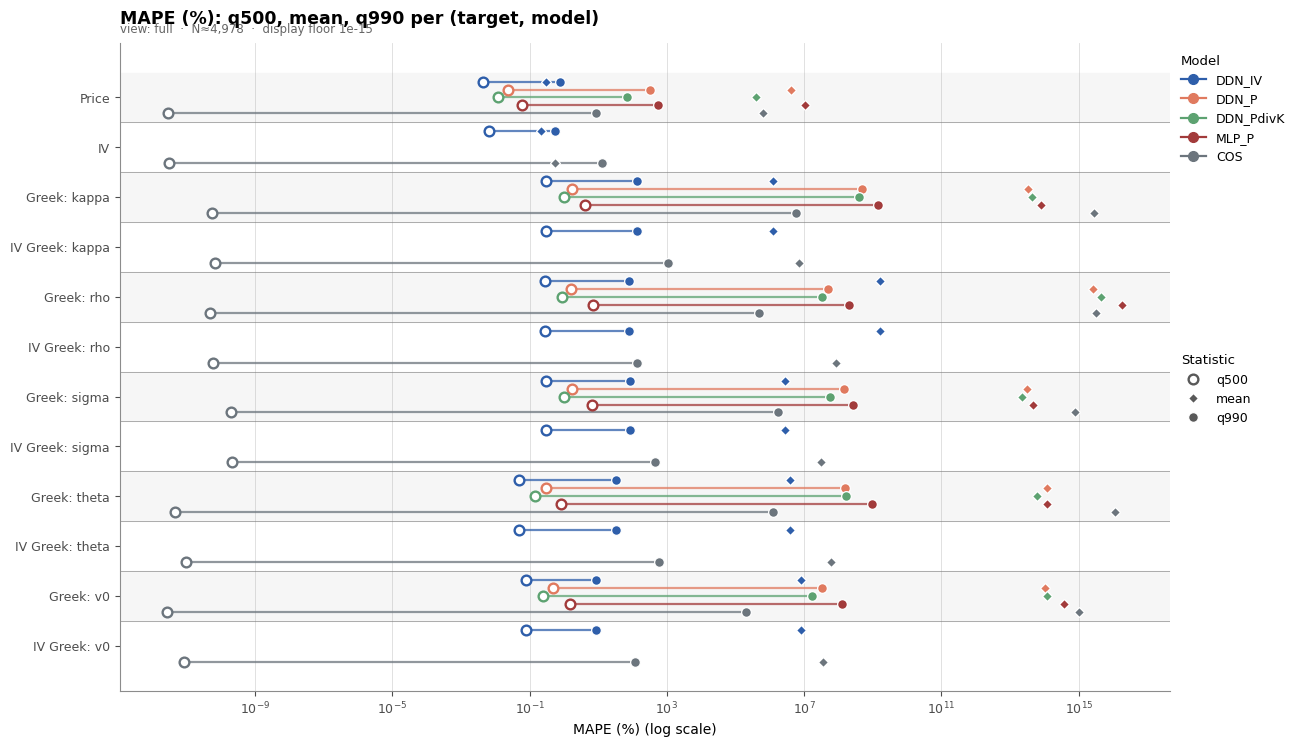

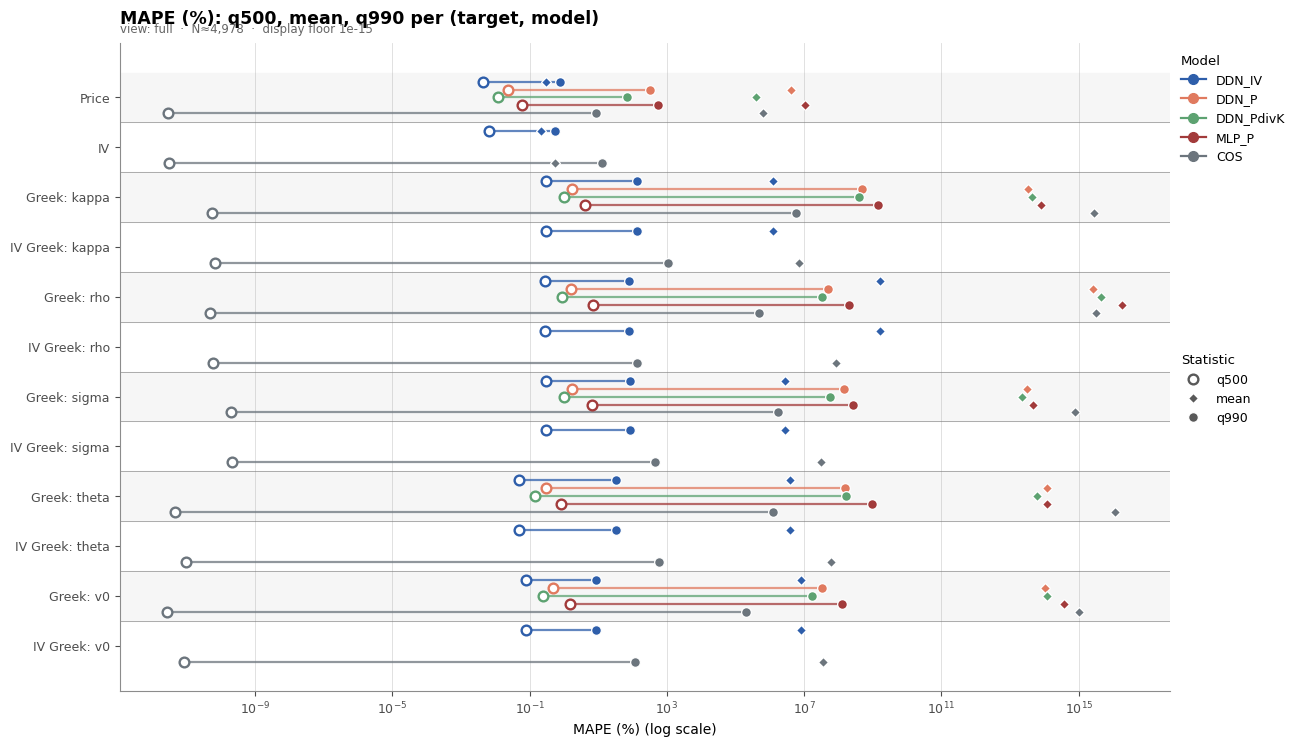

In [20]:
#=============================================================================
# MAPE diagnostics table (all targets + all Greeks, Full vs Floor)
#=============================================================================

print("\n" + "=" * 120)
print("MAPE diagnostics (all targets + all Greeks, Full vs Floor)")
print("=" * 120)
print(f"Heatmaps enabled: {ROBUST_SHOW_HEATMAPS}")
print(f"Floor definition (price): |true| >= {ROBUST_PRICE_FLOOR:g}")
print(f"Floor definition (IV): |true| >= {ROBUST_IV_FLOOR:g}")

mape_long_df = _diag_run_metric("MAPE")
mape_side_by_side_df = _diag_show_metric_table("MAPE (%)", mape_long_df)
_diag_dumbbell_quantile_plot(mape_long_df, metric_label="MAPE (%)", q_low="q500", q_high="q990", view="full")


MSE diagnostics (all targets + all Greeks, Full vs Floor)
Heatmaps enabled: False
Floor definition (price): |true| >= 0.1
Floor definition (IV): |true| >= 0.0001


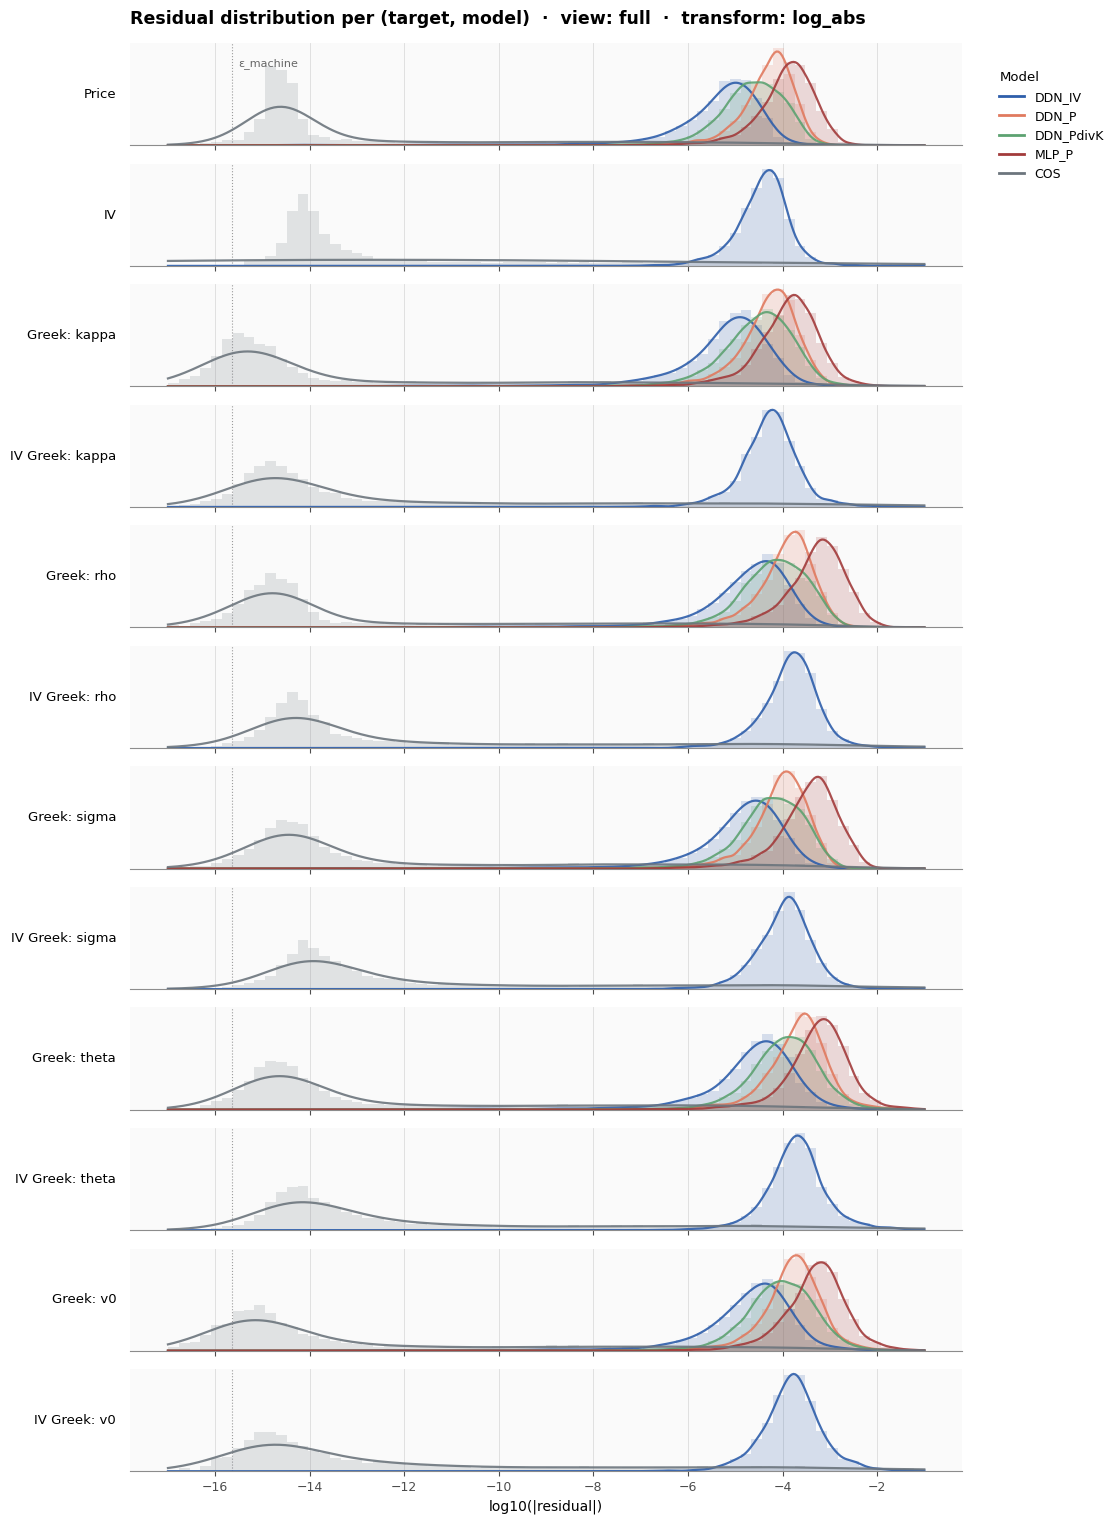

                Target      Model                 View     N  \
0                Price     DDN_IV                 full  4989   
1                Price     DDN_IV  floor(|Price|>=0.1)  3173   
2                Price      DDN_P                 full  4989   
3                Price      DDN_P  floor(|Price|>=0.1)  3173   
4                Price  DDN_PdivK                 full  4989   
..                 ...        ...                  ...   ...   
89        IV Greek: v0        COS  floor(|IV|>=0.0001)  4923   
90  IV Price Greek: v0     DDN_IV                 full  4985   
91  IV Price Greek: v0     DDN_IV  floor(|Price|>=0.1)  3169   
92  IV Price Greek: v0        COS                 full  4923   
93  IV Price Greek: v0        COS  floor(|Price|>=0.1)  3127   

    Coverage vs full (%)      mean    median  share_|true|<1e-06  \
0                    100 8.038e-09 4.747e-11           9.621e-03   
1                   63.6 1.098e-08 1.107e-10                   0   
2                    100 1.

,Target,Model,full | N,full | Coverage vs full (%),full | mean,full | median,full | share_|true|<1e-06,full | share_|true|<1e-04,full | share_|true|<1e-03,full | q500,full | q750,full | q900,full | q950,full | q990,full | q995,full | q999,floor | N,floor | Coverage vs full (%),floor | mean,floor | median,floor | share_|true|<1e-06,floor | share_|true|<1e-04,floor | share_|true|<1e-03,floor | q500,floor | q750,floor | q900,floor | q950,floor | q990,floor | q995,floor | q999
0,Price,DDN_IV,4989,100,8.038e-09,4.747e-11,9.621e-03,2.485e-02,4.931e-02,4.747e-11,3.006e-10,1.221e-09,2.597e-09,1.650e-08,3.756e-08,7.956e-07,3173,63.6,1.098e-08,1.107e-10,0,0,0,1.107e-10,5.221e-10,1.769e-09,3.441e-09,2.177e-08,4.147e-08,2.328e-06
1,Price,DDN_P,4989,100,1.942e-08,3.630e-09,9.621e-03,2.485e-02,4.931e-02,3.630e-09,1.331e-08,4.121e-08,7.467e-08,2.627e-07,3.907e-07,8.851e-07,3173,63.6,2.558e-08,6.261e-09,0,0,0,6.261e-09,1.997e-08,5.418e-08,9.960e-08,3.078e-07,4.455e-07,1.107e-06
2,Price,DDN_PdivK,4989,100,1.188e-08,6.413e-10,9.621e-03,2.485e-02,4.931e-02,6.413e-10,4.893e-09,2.219e-08,4.807e-08,1.648e-07,3.280e-07,7.714e-07,3173,63.6,1.796e-08,2.183e-09,0,0,0,2.183e-09,1.062e-08,3.524e-08,7.057e-08,2.701e-07,4.276e-07,8.677e-07
3,Price,MLP_P,4989,100,1.760e-07,2.012e-08,9.621e-03,2.485e-02,4.931e-02,2.012e-08,9.369e-08,3.298e-07,7.064e-07,2.354e-06,4.619e-06,1.230e-05,3173,63.6,2.445e-07,3.830e-08,0,0,0,3.830e-08,1.489e-07,4.859e-07,9.723e-07,3.016e-06,5.994e-06,1.264e-05
4,Price,COS,4989,100,3.551e-06,1.510e-29,9.621e-03,2.485e-02,4.931e-02,1.510e-29,3.076e-24,1.427e-14,3.312e-11,7.690e-07,5.569e-06,5.261e-04,3173,63.6,3.226e-06,1.780e-29,0,0,0,1.780e-29,2.294e-25,1.243e-14,7.560e-11,8.440e-07,1.579e-05,1.179e-03
5,IV,DDN_IV,4986,100,5.705e-04,1.852e-09,2.006e-04,2.006e-04,2.006e-04,1.852e-09,7.029e-09,2.435e-08,7.081e-08,6.640e-06,6.177e-03,8.187e-02,4985,99.98,5.601e-04,1.850e-09,0,0,0,1.850e-09,7.026e-09,2.427e-08,7.061e-08,5.369e-06,5.840e-03,8.197e-02
6,IV,COS,4927,100,9.650e-04,4.219e-28,0,0,0,4.219e-28,7.122e-22,4.149e-12,1.436e-08,1.736e-03,2.276e-02,0.3024,4927,100,9.650e-04,4.219e-28,0,0,0,4.219e-28,7.122e-22,4.149e-12,1.436e-08,1.736e-03,2.276e-02,0.3024
7,Greek: kappa,DDN_P,4989,100,9.353e-08,3.735e-09,3.808e-02,0.1072,0.2856,3.735e-09,1.696e-08,6.705e-08,1.457e-07,6.597e-07,2.700e-06,1.169e-05,3173,63.6,1.284e-07,6.856e-09,3.971e-02,8.919e-02,0.2026,6.856e-09,2.595e-08,9.091e-08,1.875e-07,8.641e-07,2.917e-06,1.257e-05
8,Greek: kappa,DDN_PdivK,4989,100,7.764e-08,1.292e-09,3.808e-02,0.1072,0.2856,1.292e-09,9.693e-09,4.973e-08,1.259e-07,1.021e-06,2.218e-06,6.840e-06,3173,63.6,1.136e-07,4.169e-09,3.971e-02,8.919e-02,0.2026,4.169e-09,2.155e-08,8.755e-08,2.017e-07,1.564e-06,2.738e-06,9.248e-06
9,Greek: kappa,MLP_P,4989,100,1.836e-06,2.256e-08,3.808e-02,0.1072,0.2856,2.256e-08,1.190e-07,4.948e-07,1.320e-06,1.229e-05,2.898e-05,1.683e-04,3173,63.6,2.665e-06,4.577e-08,3.971e-02,8.919e-02,0.2026,4.577e-08,1.948e-07,7.480e-07,1.838e-06,1.530e-05,3.566e-05,2.164e-04



MSE quantiles only:


,Target,Model,full | q500,full | q750,full | q900,full | q950,full | q990,full | q995,full | q999,floor | q500,floor | q750,floor | q900,floor | q950,floor | q990,floor | q995,floor | q999
0,Price,DDN_IV,4.747e-11,3.006e-10,1.221e-09,2.597e-09,1.650e-08,3.756e-08,7.956e-07,1.107e-10,5.221e-10,1.769e-09,3.441e-09,2.177e-08,4.147e-08,2.328e-06
1,Price,DDN_P,3.630e-09,1.331e-08,4.121e-08,7.467e-08,2.627e-07,3.907e-07,8.851e-07,6.261e-09,1.997e-08,5.418e-08,9.960e-08,3.078e-07,4.455e-07,1.107e-06
2,Price,DDN_PdivK,6.413e-10,4.893e-09,2.219e-08,4.807e-08,1.648e-07,3.280e-07,7.714e-07,2.183e-09,1.062e-08,3.524e-08,7.057e-08,2.701e-07,4.276e-07,8.677e-07
3,Price,MLP_P,2.012e-08,9.369e-08,3.298e-07,7.064e-07,2.354e-06,4.619e-06,1.230e-05,3.830e-08,1.489e-07,4.859e-07,9.723e-07,3.016e-06,5.994e-06,1.264e-05
4,Price,COS,1.510e-29,3.076e-24,1.427e-14,3.312e-11,7.690e-07,5.569e-06,5.261e-04,1.780e-29,2.294e-25,1.243e-14,7.560e-11,8.440e-07,1.579e-05,1.179e-03
5,IV,DDN_IV,1.852e-09,7.029e-09,2.435e-08,7.081e-08,6.640e-06,6.177e-03,8.187e-02,1.850e-09,7.026e-09,2.427e-08,7.061e-08,5.369e-06,5.840e-03,8.197e-02
6,IV,COS,4.219e-28,7.122e-22,4.149e-12,1.436e-08,1.736e-03,2.276e-02,0.3024,4.219e-28,7.122e-22,4.149e-12,1.436e-08,1.736e-03,2.276e-02,0.3024
7,Greek: kappa,DDN_P,3.735e-09,1.696e-08,6.705e-08,1.457e-07,6.597e-07,2.700e-06,1.169e-05,6.856e-09,2.595e-08,9.091e-08,1.875e-07,8.641e-07,2.917e-06,1.257e-05
8,Greek: kappa,DDN_PdivK,1.292e-09,9.693e-09,4.973e-08,1.259e-07,1.021e-06,2.218e-06,6.840e-06,4.169e-09,2.155e-08,8.755e-08,2.017e-07,1.564e-06,2.738e-06,9.248e-06
9,Greek: kappa,MLP_P,2.256e-08,1.190e-07,4.948e-07,1.320e-06,1.229e-05,2.898e-05,1.683e-04,4.577e-08,1.948e-07,7.480e-07,1.838e-06,1.530e-05,3.566e-05,2.164e-04


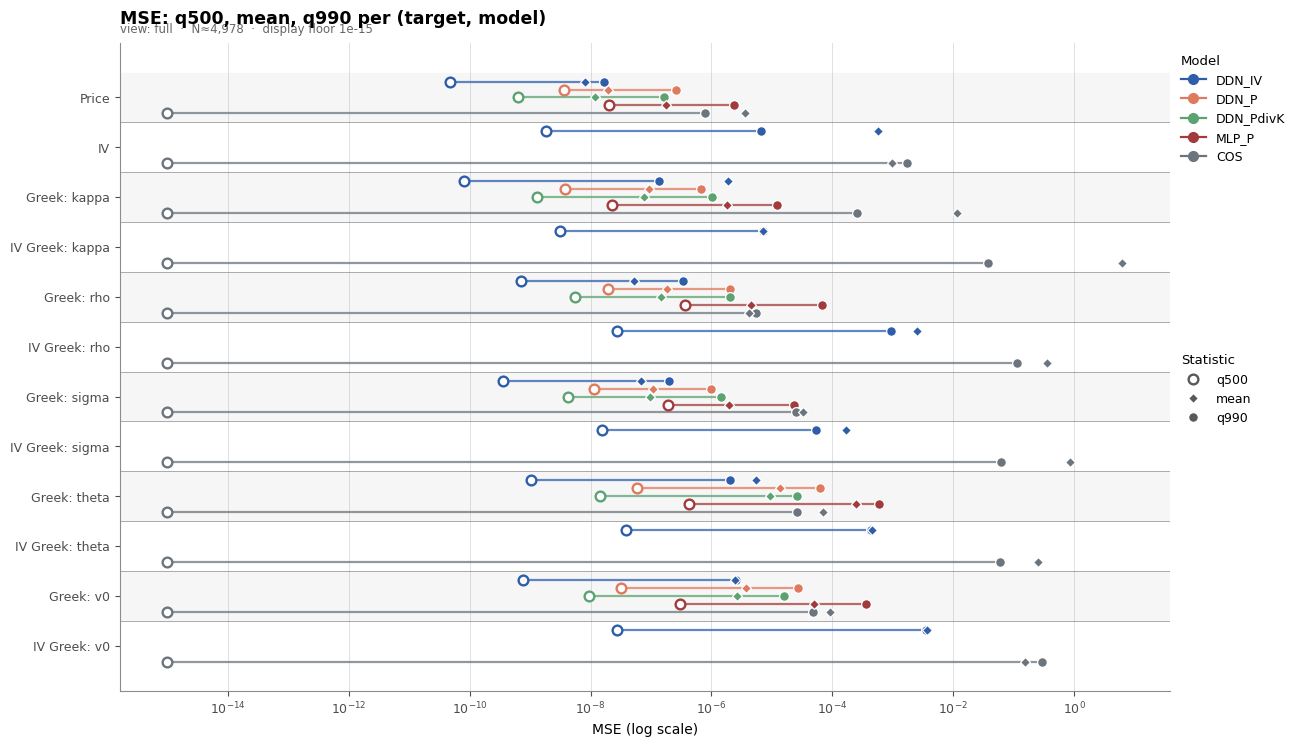

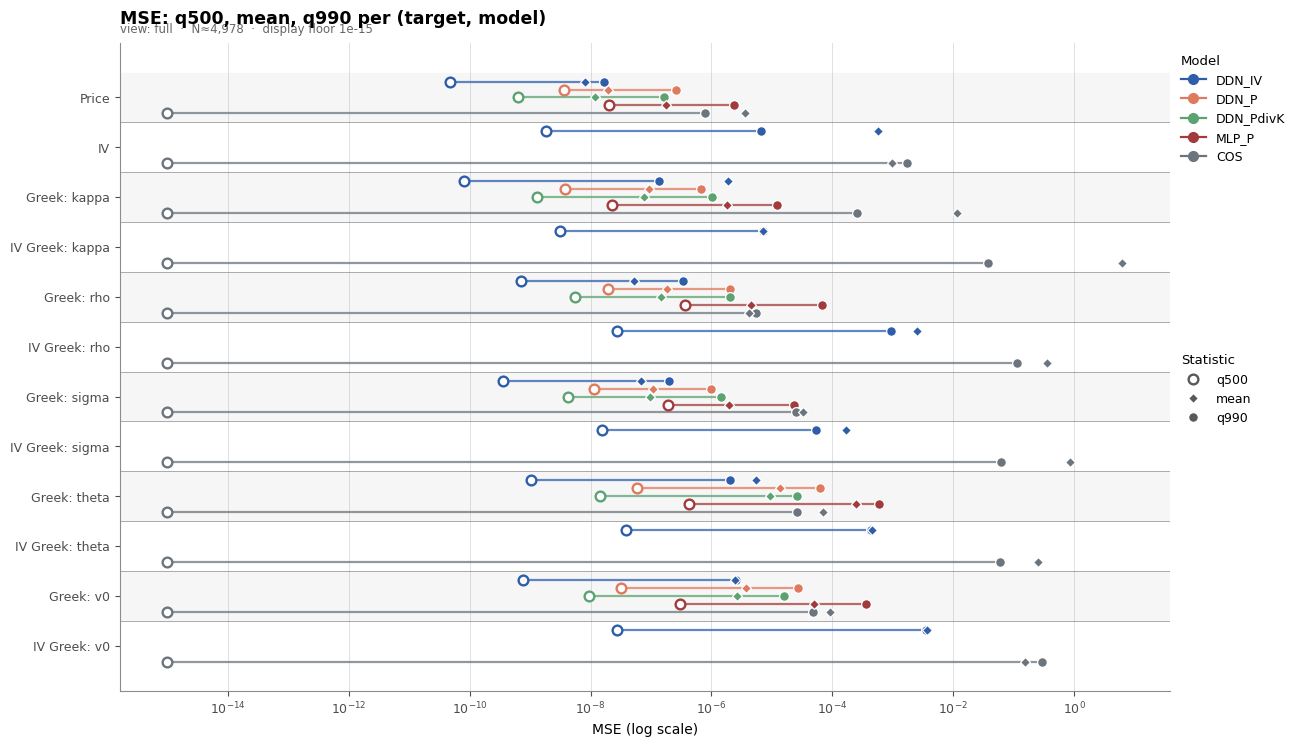

In [21]:
#=============================================================================
# MSE diagnostics table (all targets + all Greeks, Full vs Floor)
#=============================================================================
print("\n" + "=" * 120)
print("MSE diagnostics (all targets + all Greeks, Full vs Floor)")
print("=" * 120)
print(f"Heatmaps enabled: {ROBUST_SHOW_HEATMAPS}")
print(f"Floor definition (price): |true| >= {ROBUST_PRICE_FLOOR:g}")
print(f"Floor definition (IV): |true| >= {ROBUST_IV_FLOOR:g}")

_diag_residual_distribution_plot()


mse_long_df = _diag_run_metric("MSE",show_heatmaps=False)
print(mse_long_df)
mse_side_by_side_df = _diag_show_metric_table("MSE", mse_long_df)
_diag_dumbbell_quantile_plot(mse_long_df, metric_label="MSE", q_low="q500", q_high="q990", view="full")


MAE diagnostics (all targets + all Greeks, Full vs Floor)
Heatmaps enabled: False
Floor definition (price): |true| >= 0.1
Floor definition (IV): |true| >= 0.0001

MAE summary (Full vs Floor, all Greeks included)


,Target,Model,full | N,full | Coverage vs full (%),full | mean,full | median,full | share_|true|<1e-06,full | share_|true|<1e-04,full | share_|true|<1e-03,full | q500,full | q750,full | q900,full | q950,full | q990,full | q995,full | q999,floor | N,floor | Coverage vs full (%),floor | mean,floor | median,floor | share_|true|<1e-06,floor | share_|true|<1e-04,floor | share_|true|<1e-03,floor | q500,floor | q750,floor | q900,floor | q950,floor | q990,floor | q995,floor | q999
0,Price,DDN_IV,4989,100,1.709e-05,6.890e-06,9.621e-03,2.485e-02,4.931e-02,6.890e-06,1.734e-05,3.495e-05,5.096e-05,1.285e-04,1.938e-04,8.882e-04,3173,63.6,2.199e-05,1.052e-05,0,0,0,1.052e-05,2.285e-05,4.206e-05,5.866e-05,1.475e-04,2.036e-04,1.499e-03
1,Price,DDN_P,4989,100,9.031e-05,6.025e-05,9.621e-03,2.485e-02,4.931e-02,6.025e-05,1.154e-04,2.030e-04,2.733e-04,5.126e-04,6.251e-04,9.408e-04,3173,63.6,1.102e-04,7.913e-05,0,0,0,7.913e-05,1.413e-04,2.328e-04,3.156e-04,5.548e-04,6.675e-04,1.052e-03
2,Price,DDN_PdivK,4989,100,5.793e-05,2.532e-05,9.621e-03,2.485e-02,4.931e-02,2.532e-05,6.995e-05,1.490e-04,2.193e-04,4.060e-04,5.727e-04,8.783e-04,3173,63.6,8.092e-05,4.672e-05,0,0,0,4.672e-05,1.030e-04,1.877e-04,2.656e-04,5.197e-04,6.539e-04,9.314e-04
3,Price,MLP_P,4989,100,2.485e-04,1.419e-04,9.621e-03,2.485e-02,4.931e-02,1.419e-04,3.061e-04,5.742e-04,8.405e-04,1.534e-03,2.149e-03,3.508e-03,3173,63.6,3.117e-04,1.957e-04,0,0,0,1.957e-04,3.858e-04,6.971e-04,9.861e-04,1.737e-03,2.448e-03,3.555e-03
4,Price,COS,4989,100,9.679e-05,3.886e-15,9.621e-03,2.485e-02,4.931e-02,3.886e-15,1.754e-12,1.195e-07,5.755e-06,8.769e-04,2.360e-03,2.289e-02,3173,63.6,1.073e-04,4.219e-15,0,0,0,4.219e-15,4.790e-13,1.115e-07,8.695e-06,9.187e-04,3.974e-03,3.395e-02
5,IV,DDN_IV,4986,100,1.502e-03,4.304e-05,2.006e-04,2.006e-04,2.006e-04,4.304e-05,8.384e-05,1.560e-04,2.661e-04,2.577e-03,7.857e-02,0.2856,4985,99.98,1.457e-03,4.301e-05,0,0,0,4.301e-05,8.382e-05,1.558e-04,2.657e-04,2.314e-03,7.642e-02,0.2858
6,IV,COS,4986,100,2.127e+300,2.143e-14,2.006e-04,2.006e-04,2.006e-04,2.143e-14,5.141e-11,4.212e-06,3.649e-04,1.798e+302,1.798e+302,1.798e+302,4985,99.98,2.092e+300,2.143e-14,0,0,0,2.143e-14,5.069e-11,4.080e-06,3.539e-04,1.798e+302,1.798e+302,1.798e+302
7,Greek: kappa,DDN_P,4989,100,1.188e-04,6.112e-05,3.808e-02,0.1072,0.2856,6.112e-05,1.302e-04,2.589e-04,3.817e-04,8.122e-04,1.643e-03,3.420e-03,3173,63.6,1.467e-04,8.280e-05,3.971e-02,8.919e-02,0.2026,8.280e-05,1.611e-04,3.015e-04,4.330e-04,9.295e-04,1.708e-03,3.539e-03
8,Greek: kappa,DDN_PdivK,4989,100,9.839e-05,3.594e-05,3.808e-02,0.1072,0.2856,3.594e-05,9.845e-05,2.230e-04,3.548e-04,1.010e-03,1.489e-03,2.615e-03,3173,63.6,1.363e-04,6.457e-05,3.971e-02,8.919e-02,0.2026,6.457e-05,1.468e-04,2.959e-04,4.492e-04,1.251e-03,1.655e-03,3.038e-03
9,Greek: kappa,MLP_P,4989,100,3.597e-04,1.502e-04,3.808e-02,0.1072,0.2856,1.502e-04,3.450e-04,7.034e-04,1.149e-03,3.506e-03,5.384e-03,1.297e-02,3173,63.6,4.602e-04,2.139e-04,3.971e-02,8.919e-02,0.2026,2.139e-04,4.414e-04,8.649e-04,1.356e-03,3.912e-03,5.972e-03,1.471e-02



MAE quantiles only:


,Target,Model,full | q500,full | q750,full | q900,full | q950,full | q990,full | q995,full | q999,floor | q500,floor | q750,floor | q900,floor | q950,floor | q990,floor | q995,floor | q999
0,Price,DDN_IV,6.890e-06,1.734e-05,3.495e-05,5.096e-05,1.285e-04,1.938e-04,8.882e-04,1.052e-05,2.285e-05,4.206e-05,5.866e-05,1.475e-04,2.036e-04,1.499e-03
1,Price,DDN_P,6.025e-05,1.154e-04,2.030e-04,2.733e-04,5.126e-04,6.251e-04,9.408e-04,7.913e-05,1.413e-04,2.328e-04,3.156e-04,5.548e-04,6.675e-04,1.052e-03
2,Price,DDN_PdivK,2.532e-05,6.995e-05,1.490e-04,2.193e-04,4.060e-04,5.727e-04,8.783e-04,4.672e-05,1.030e-04,1.877e-04,2.656e-04,5.197e-04,6.539e-04,9.314e-04
3,Price,MLP_P,1.419e-04,3.061e-04,5.742e-04,8.405e-04,1.534e-03,2.149e-03,3.508e-03,1.957e-04,3.858e-04,6.971e-04,9.861e-04,1.737e-03,2.448e-03,3.555e-03
4,Price,COS,3.886e-15,1.754e-12,1.195e-07,5.755e-06,8.769e-04,2.360e-03,2.289e-02,4.219e-15,4.790e-13,1.115e-07,8.695e-06,9.187e-04,3.974e-03,3.395e-02
5,IV,DDN_IV,4.304e-05,8.384e-05,1.560e-04,2.661e-04,2.577e-03,7.857e-02,0.2856,4.301e-05,8.382e-05,1.558e-04,2.657e-04,2.314e-03,7.642e-02,0.2858
6,IV,COS,2.143e-14,5.141e-11,4.212e-06,3.649e-04,1.798e+302,1.798e+302,1.798e+302,2.143e-14,5.069e-11,4.080e-06,3.539e-04,1.798e+302,1.798e+302,1.798e+302
7,Greek: kappa,DDN_P,6.112e-05,1.302e-04,2.589e-04,3.817e-04,8.122e-04,1.643e-03,3.420e-03,8.280e-05,1.611e-04,3.015e-04,4.330e-04,9.295e-04,1.708e-03,3.539e-03
8,Greek: kappa,DDN_PdivK,3.594e-05,9.845e-05,2.230e-04,3.548e-04,1.010e-03,1.489e-03,2.615e-03,6.457e-05,1.468e-04,2.959e-04,4.492e-04,1.251e-03,1.655e-03,3.038e-03
9,Greek: kappa,MLP_P,1.502e-04,3.450e-04,7.034e-04,1.149e-03,3.506e-03,5.384e-03,1.297e-02,2.139e-04,4.414e-04,8.649e-04,1.356e-03,3.912e-03,5.972e-03,1.471e-02


/Users/manswestman/Kandidatarbete/venv/lib/python3.13/site-packages/matplotlib/scale.py:270: RuntimeWarning: overflow encountered in power
  return np.power(self.base, values)


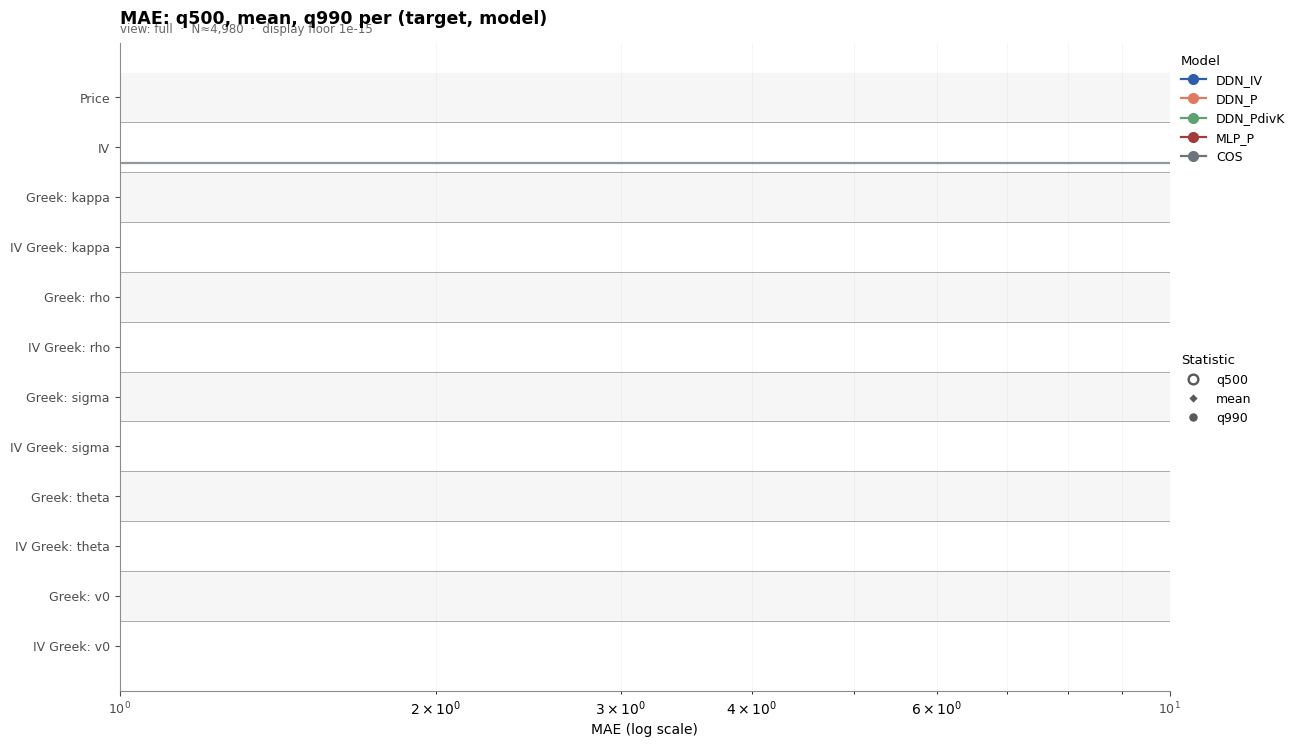

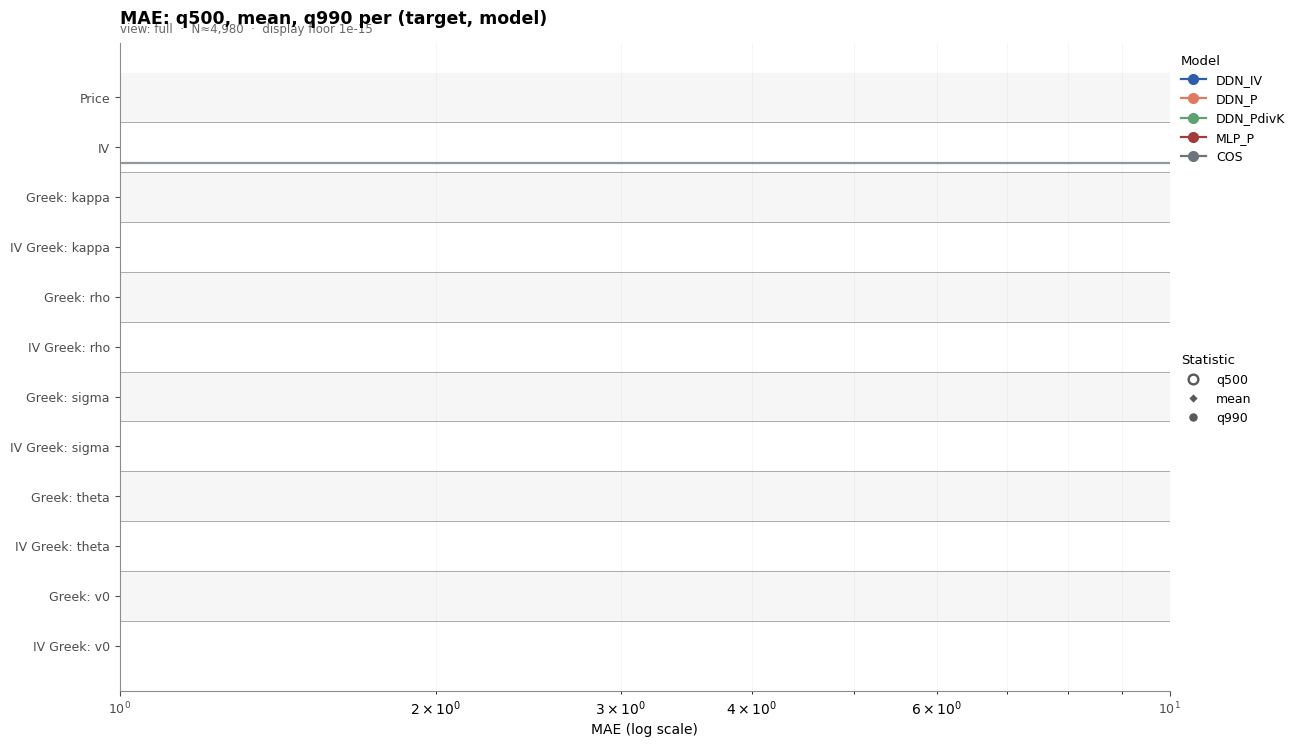

In [22]:
#=============================================================================
# MAE diagnostics table (all targets + all Greeks, Full vs Floor)
#=============================================================================

print("\n" + "=" * 120)
print("MAE diagnostics (all targets + all Greeks, Full vs Floor)")
print("=" * 120)
print(f"Heatmaps enabled: {ROBUST_SHOW_HEATMAPS}")
print(f"Floor definition (price): |true| >= {ROBUST_PRICE_FLOOR:g}")
print(f"Floor definition (IV): |true| >= {ROBUST_IV_FLOOR:g}")

mae_long_df = _diag_run_metric("MAE")
mae_side_by_side_df = _diag_show_metric_table("MAE", mae_long_df)
_diag_dumbbell_quantile_plot(mae_long_df, metric_label="MAE", q_low="q500", q_high="q990", view="full")

In [23]:
# =============================================================================
# IV-Greek diagnostics after Vega conversion (focus: MSE + quantiles)
# Computes errors of (IV Greek * Vega) against (true IV Greek * Vega)
# Quantiles are computed on full sample (no floor filtering).
# =============================================================================

if "df" not in globals():
    raise RuntimeError("`df` is missing in kernel state. Run earlier data import cells first.")
if "y_true_iv_greeks" not in globals() or not isinstance(y_true_iv_greeks, dict) or len(y_true_iv_greeks) == 0:
    raise RuntimeError("`y_true_iv_greeks` is missing/empty. Run IV metric-prep cells first.")
if "iv_models" not in globals() or not isinstance(iv_models, dict) or len(iv_models) == 0:
    raise RuntimeError("`iv_models` is missing/empty. Run IV model evaluation cells first.")

# Locate Vega in eval data (fallback names supported).
vega_col = None
for c in ["vega", "Vega", "VEGA"]:
    if c in df.columns:
        vega_col = c
        break
if vega_col is None:
    raise RuntimeError("No vega column found in `df`. Expected one of: vega, Vega, VEGA")

vega_all = np.asarray(df[vega_col], dtype=float).flatten()
rows = []
q_levels = globals().get("DIAG_QUANTILES", [0.5, 0.9, 0.95, 0.99])
q_levels = [float(q) for q in q_levels if 0.0 <= float(q) <= 1.0]

for g, y_true_iv in sorted(y_true_iv_greeks.items()):
    y_true_iv = np.asarray(y_true_iv, dtype=float).flatten()

    for model_name, model_df in sorted(iv_models.items()):
        pred_col = f"IVd{g}"
        if pred_col not in model_df.columns:
            continue

        y_pred_iv = np.asarray(model_df[pred_col], dtype=float).flatten()

        n = min(len(y_true_iv), len(y_pred_iv), len(vega_all))
        if n == 0:
            continue

        yt = y_true_iv[:n]
        yp = y_pred_iv[:n]
        vg = vega_all[:n]

        mask = np.isfinite(yt) & np.isfinite(yp) & np.isfinite(vg)
        if not np.any(mask):
            continue

        yt = yt[mask]
        yp = yp[mask]
        vg = vg[mask]

        # Converted quantities in price-greek units via Vega scaling.
        true_conv = yt * vg
        pred_conv = yp * vg
        err_conv = pred_conv - true_conv
        abs_err = np.abs(err_conv)
        sq_err = err_conv ** 2

        row = {
            "Greek": g,
            "Model": model_name,
            "N": int(len(err_conv)),
            "MSE (IVGreek*Vega)": float(np.mean(sq_err)),
            "Median SE": float(np.median(sq_err)),
            "MAE (IVGreek*Vega)": float(np.mean(abs_err)),
        }

        for q in q_levels:
            q_label = int(round(q * 100))
            row[f"SE q{q_label}"] = float(np.quantile(sq_err, q))
            row[f"|err| q{q_label}"] = float(np.quantile(abs_err, q))

        rows.append(row)

if len(rows) == 0:
    print("No IV-greek/model pairs found for Vega-converted diagnostics.")
    iv_vega_mse_df = pd.DataFrame()
    iv_vega_quantiles_df = pd.DataFrame()
else:
    iv_vega_mse_df = pd.DataFrame(rows).sort_values(
        ["MSE (IVGreek*Vega)", "Greek", "Model"], ascending=[True, True, True]
    ).reset_index(drop=True)

    # Same rows, explicitly named for outlier diagnosis usage.
    iv_vega_quantiles_df = iv_vega_mse_df.copy()

    print("\n" + "=" * 120)
    print("IV-Greek -> Vega-converted diagnostics (MSE + quantiles, full sample)")
    print("=" * 120)
    print(f"Using vega column: {vega_col}")
    print("No floor filter applied in this cell.")

    with pd.option_context("display.max_rows", None, "display.max_columns", None, "display.width", 2000):
        display(iv_vega_quantiles_df)

    print("\nBest (lowest MSE) per Greek:")
    best_per_greek = (
        iv_vega_mse_df.sort_values(["Greek", "MSE (IVGreek*Vega)"])
        .groupby("Greek", as_index=False)
        .first()
    )
    with pd.option_context("display.max_rows", None, "display.max_columns", None, "display.width", 2000):
        display(best_per_greek)

    print("\nOutlier check helper: compare `SE q99`/`SE q95` vs `Median SE`; a large gap suggests tail-driven MSE.")


IV-Greek -> Vega-converted diagnostics (MSE + quantiles, full sample)
Using vega column: vega
No floor filter applied in this cell.


,Greek,Model,N,MSE (IVGreek*Vega),Median SE,MAE (IVGreek*Vega),SE q50,|err| q50,SE q75,|err| q75,SE q90,|err| q90,SE q95,|err| q95,SE q99,|err| q99,SE q100,|err| q100
0,rho,DDN_IV,4985,5.204e-08,6.941e-10,6.859e-05,6.941e-10,2.635e-05,4.918e-09,7.013e-05,2.235e-08,1.495e-04,5.193e-08,2.279e-04,3.402e-07,5.832e-04,6.599e-06,2.566e-03
1,sigma,DDN_IV,4985,6.728e-08,3.503e-10,5.267e-05,3.503e-10,1.872e-05,2.531e-09,5.031e-05,1.186e-08,1.089e-04,3.006e-08,1.734e-04,1.993e-07,4.464e-04,3.182e-06,1.780e-03
2,kappa,DDN_IV,4985,1.890e-06,7.931e-11,7.218e-05,7.931e-11,8.906e-06,6.098e-10,2.469e-05,3.511e-09,5.925e-05,8.828e-09,9.396e-05,1.355e-07,3.681e-04,1.062e-04,1.029e-02
3,v0,DDN_IV,4985,2.422e-06,7.559e-10,1.459e-04,7.559e-10,2.749e-05,5.553e-09,7.452e-05,3.023e-08,1.739e-04,8.788e-08,2.964e-04,2.535e-06,1.592e-03,2.403e-04,1.550e-02
4,theta,DDN_IV,4985,5.434e-06,1.047e-09,1.640e-04,1.047e-09,3.236e-05,7.918e-09,8.898e-05,4.077e-08,2.019e-04,1.230e-07,3.507e-04,2.033e-06,1.426e-03,1.822e-04,1.350e-02
5,rho,COS,4923,2.070e-05,1.510e-29,1.604e-04,1.510e-29,3.886e-15,3.170e-22,1.780e-11,8.202e-13,9.055e-07,9.928e-10,3.151e-05,1.995e-06,1.412e-03,4.946e-04,2.219e-02
6,theta,COS,4923,2.156e-05,4.662e-29,2.343e-04,4.662e-29,6.828e-15,2.921e-22,1.708e-11,6.257e-13,7.910e-07,6.003e-10,2.450e-05,6.785e-06,2.604e-03,2.623e-03,5.122e-02
7,sigma,COS,4923,4.199e-05,9.464e-29,2.277e-04,9.464e-29,9.728e-15,4.453e-22,2.110e-11,1.589e-12,1.261e-06,1.739e-09,4.170e-05,6.081e-06,2.466e-03,4.780e-04,2.185e-02
8,v0,COS,4923,7.305e-05,7.211e-30,3.917e-04,7.211e-30,2.685e-15,1.045e-22,1.022e-11,8.518e-13,9.229e-07,2.151e-09,4.637e-05,1.350e-05,3.675e-03,7.025e-03,8.372e-02
9,kappa,COS,4923,4.463e-03,1.915e-30,2.361e-03,1.915e-30,1.384e-15,1.818e-23,4.263e-12,1.608e-13,4.010e-07,1.125e-09,3.353e-05,6.488e-05,8.047e-03,9.141e-02,0.3013



Best (lowest MSE) per Greek:


,Greek,Model,N,MSE (IVGreek*Vega),Median SE,MAE (IVGreek*Vega),SE q50,|err| q50,SE q75,|err| q75,SE q90,|err| q90,SE q95,|err| q95,SE q99,|err| q99,SE q100,|err| q100
0,kappa,DDN_IV,4985,1.890e-06,7.931e-11,7.218e-05,7.931e-11,8.906e-06,6.098e-10,2.469e-05,3.511e-09,5.925e-05,8.828e-09,9.396e-05,1.355e-07,3.681e-04,1.062e-04,1.029e-02
1,rho,DDN_IV,4985,5.204e-08,6.941e-10,6.859e-05,6.941e-10,2.635e-05,4.918e-09,7.013e-05,2.235e-08,1.495e-04,5.193e-08,2.279e-04,3.402e-07,5.832e-04,6.599e-06,2.566e-03
2,sigma,DDN_IV,4985,6.728e-08,3.503e-10,5.267e-05,3.503e-10,1.872e-05,2.531e-09,5.031e-05,1.186e-08,1.089e-04,3.006e-08,1.734e-04,1.993e-07,4.464e-04,3.182e-06,1.780e-03
3,theta,DDN_IV,4985,5.434e-06,1.047e-09,1.640e-04,1.047e-09,3.236e-05,7.918e-09,8.898e-05,4.077e-08,2.019e-04,1.230e-07,3.507e-04,2.033e-06,1.426e-03,1.822e-04,1.350e-02
4,v0,DDN_IV,4985,2.422e-06,7.559e-10,1.459e-04,7.559e-10,2.749e-05,5.553e-09,7.452e-05,3.023e-08,1.739e-04,8.788e-08,2.964e-04,2.535e-06,1.592e-03,2.403e-04,1.550e-02



Outlier check helper: compare `SE q99`/`SE q95` vs `Median SE`; a large gap suggests tail-driven MSE.


## 9) Synthetic IV surface (DDN_IV vs COS)
Single-state surface over tau and lm for a "normal market" parameter set.

small_vega
-1.7976931348623157e+308
small_vega
-1.7976931348623157e+308
small_vega
-1.7976931348623157e+308
small_vega
-1.7976931348623157e+308
small_vega
-1.7976931348623157e+308
small_vega
-1.7976931348623157e+308
small_vega
-1.7976931348623157e+308
small_vega
-1.7976931348623157e+308
small_vega
-1.7976931348623157e+308
small_vega
1.0797999253169994
small_vega
0.8854922921674037
iv_zero
0.0
Base row (scenario=normal):


,kappa,theta,v0,rho,sigma,r,lm,T
1,2.523,0.7072,0.7079,-0.4743,0.8004,4.496e-02,0,1.513


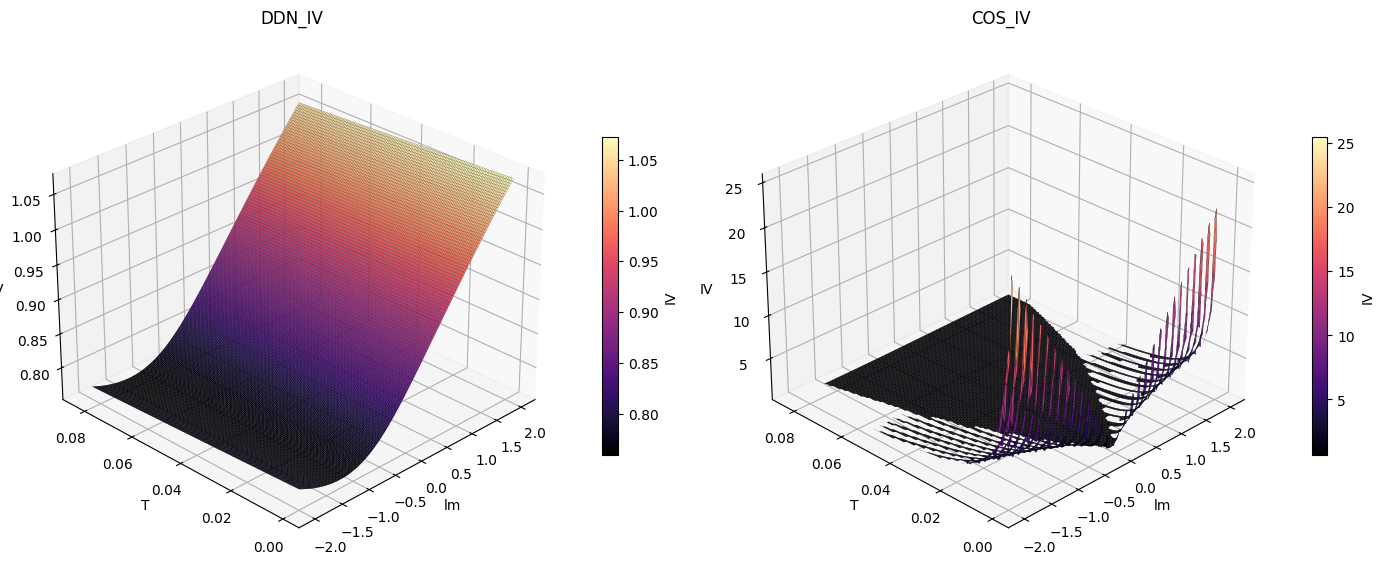

6054


In [24]:
# =============================================================================
# 9) Synthetic IV surface (DDN_IV vs COS) for a "normal market" state
# =============================================================================
SURF_IV_RUN = True
SURF_N_LM = 150
SURF_N_T = 150
SURF_LM_MIN = None  # None -> use VISVAL_LM_MIN/param_bounds
SURF_LM_MAX = None
SURF_T_MIN = 0
SURF_T_MAX = 1/12
SURF_SCENARIO = "normal"  # "calm" | "normal" | "stressed" | "median"
SURF_SHOW_PLOTS = True
SURF_COLOR_SCALE = "independent"  # "independent" | "shared"
SURF_ALPHA = 1.0
SURF_SHADE = True
SURF_SHOW_GRID = True

conv_fails = 0
if not SURF_IV_RUN:
    print("Synthetic IV surface disabled (SURF_IV_RUN=False).")
else:
    needed = ["model_IV", "scale_inputs", "param_bounds"]
    missing = [k for k in needed if k not in globals()]
    if missing:
        print(f"Missing prerequisites for IV surface: {missing}")
    else:
        feature_cols = FEATURE_COLS if "FEATURE_COLS" in globals() else ["kappa", "theta", "v0", "rho", "sigma", "r", "lm", "T"]
        lm_col = LM_COL if "LM_COL" in globals() else "lm"

        base_row = None
        if SURF_SCENARIO in {"calm", "normal", "stressed"} and "_select_shared_base_rows" in globals():
            shared_rows = _select_shared_base_rows()
            idx_map = {"calm": 0, "normal": 1, "stressed": 2}
            idx = idx_map[SURF_SCENARIO]
            if len(shared_rows) > idx:
                base_row = shared_rows.iloc[idx].copy()
            elif len(shared_rows) > 0:
                base_row = shared_rows.iloc[0].copy()

        if base_row is None:
            if "input_raw_DDN_IV" in globals() and isinstance(input_raw_DDN_IV, pd.DataFrame):
                source_df = input_raw_DDN_IV
            elif "df" in globals() and isinstance(df, pd.DataFrame):
                source_df = df
            else:
                raise RuntimeError("No data source found to build a base row.")
            base_row = source_df[feature_cols].median(numeric_only=True)

        base_row = pd.Series(base_row)
        base_row[lm_col] = 0.0

        for col in feature_cols:
            if col not in base_row or not np.isfinite(base_row[col]):
                if col in param_bounds:
                    lo, hi = param_bounds[col]
                    base_row[col] = 0.5 * (float(lo) + float(hi))
                else:
                    base_row[col] = 0.0

        base_row = base_row[feature_cols]

        lm_bounds = param_bounds.get(lm_col, [-2.0, 2.0])
        t_bounds = param_bounds.get("T", [1.0 / 52.0, 3.0])

        lm_min = float(SURF_LM_MIN) if SURF_LM_MIN is not None else float(globals().get("VISVAL_LM_MIN", lm_bounds[0]))
        lm_max = float(SURF_LM_MAX) if SURF_LM_MAX is not None else float(globals().get("VISVAL_LM_MAX", lm_bounds[1]))
        t_min = float(SURF_T_MIN) if SURF_T_MIN is not None else float(t_bounds[0])
        t_max = float(SURF_T_MAX) if SURF_T_MAX is not None else float(t_bounds[1])

        lm_grid = np.linspace(lm_min, lm_max, int(SURF_N_LM))
        t_grid = np.linspace(t_min, t_max, int(SURF_N_T))
        n_lm = len(lm_grid)
        n_t = len(t_grid)

        raw_grid = pd.DataFrame([base_row.to_dict()] * (n_lm * n_t))
        raw_grid[lm_col] = np.tile(lm_grid, n_t)
        raw_grid["T"] = np.repeat(t_grid, n_lm)

        raw_nn = raw_grid.copy()
        if {"theta", "v0"}.issubset(raw_nn.columns):
            raw_nn[["theta", "v0"]] = np.sqrt(np.clip(raw_nn[["theta", "v0"]], 0.0, None))

        scaled_df = scale_inputs(raw_nn[feature_cols], zero_centered=True)

        model_device = next(model_IV.parameters()).device
        x = torch.tensor(scaled_df.values, dtype=torch.float32, device=model_device)
        with torch.no_grad():
            pred_iv = model_IV(x).detach().cpu().numpy().flatten()

        if "unscale_DDN_IV" in globals():
            pred_iv, _ = unscale_DDN_IV(pred_iv, grads=None, sqrt_vals=None)

        ddn_iv_grid = pred_iv.reshape(n_t, n_lm)

        cos_iv_grid = None
        cos_ready = all(k in globals() for k in ["price_jit", "jnp", "N_COS", "L_COS", "_pricehat_to_iv_and_ivgreeks"])
        if cos_ready:
            params = jnp.array(
                [
                    float(base_row["theta"]),
                    float(base_row["v0"]),
                    float(base_row["sigma"]),
                    float(base_row["rho"]),
                    float(base_row["kappa"]),
                ],
                dtype=jnp.float64,
            )
            r_val = float(base_row["r"])
            q_val = float(globals().get("q_cos", 0.0))
            dummy_greeks = np.zeros(5, dtype=float)

            cos_iv_grid = np.full((n_t, n_lm), np.nan, dtype=float)
            for i, t_i in enumerate(t_grid):
                for j, lm in enumerate(lm_grid):
                    price_hat = float(price_jit(params, float(lm), float(t_i), r_val, q_val, int(N_COS), int(L_COS)))
                    iv_i, _, status = _pricehat_to_iv_and_ivgreeks(
                        price_hat, dummy_greeks, float(lm), float(t_i), r_val, q=float(q_val)
                    )

                    if status == "ok" and np.isfinite(iv_i):
                        cos_iv_grid[i, j] = float(iv_i)
                    else:
                        conv_fails +=1
                        if conv_fails % 500 == 0:
                            print(status)
                            print(iv_i)

        else:
            print("COS IV surface skipped: missing COS runtime or IV inversion helper.")

        print(f"Base row (scenario={SURF_SCENARIO}):")
        display(pd.DataFrame([base_row]))

        if SURF_SHOW_PLOTS:
            from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

            lm_mesh, t_mesh = np.meshgrid(lm_grid, t_grid)
            n_panels = 2 if cos_iv_grid is not None else 1
            fig = plt.figure(figsize=(7.0 * n_panels, 5.6), constrained_layout=True)
        
            def _finite_range(z):
                if z is None:
                    return None, None
                vals = z[np.isfinite(z)]
                if len(vals) == 0:
                    return None, None
                return float(np.nanmin(vals)), float(np.nanmax(vals))

            ddn_vmin, ddn_vmax = _finite_range(ddn_iv_grid)
            cos_vmin, cos_vmax = _finite_range(cos_iv_grid) if cos_iv_grid is not None else (None, None)

            if SURF_COLOR_SCALE == "shared":
                combined = ddn_iv_grid[np.isfinite(ddn_iv_grid)]
                if cos_iv_grid is not None:
                    combined = np.concatenate([combined, cos_iv_grid[np.isfinite(cos_iv_grid)]])
                if len(combined) > 0:
                    shared_vmin = float(np.nanmin(combined))
                    shared_vmax = float(np.nanmax(combined))
                else:
                    shared_vmin = None
                    shared_vmax = None
                ddn_vmin, ddn_vmax = shared_vmin, shared_vmax
                cos_vmin, cos_vmax = shared_vmin, shared_vmax

            def _plot_surface(ax, z, title, vmin=None, vmax=None):
                surf = ax.plot_surface(
                    lm_mesh,
                    t_mesh,
                    z,
                    cmap="magma",
                    vmin=vmin,
                    vmax=vmax,
                    alpha=float(SURF_ALPHA),
                    shade=bool(SURF_SHADE),
                    edgecolor="k",
                    rstride=1,
                    cstride=1,
                    linewidth=0.1,
                    antialiased=True,
                )
                ax.set_title(title)
                ax.set_xlabel("lm")
                ax.set_ylabel("T")
                ax.set_zlabel("IV")
                ax.view_init(elev=28, azim=-135)
                ax.grid(bool(SURF_SHOW_GRID))
                fig.colorbar(surf, ax=ax, shrink=0.6, pad=0.08, label="IV")

            ax0 = fig.add_subplot(1, n_panels, 1, projection="3d")
            _plot_surface(ax0, ddn_iv_grid, "DDN_IV", vmin=ddn_vmin, vmax=ddn_vmax)

            if cos_iv_grid is not None:
                ax1 = fig.add_subplot(1, n_panels, 2, projection="3d")
                _plot_surface(ax1, cos_iv_grid, "COS_IV", vmin=cos_vmin, vmax=cos_vmax)

            plt.show()

print(conv_fails)